# [이론] 표준오차와 신뢰구간 — 추정값의 불확실성과 가정 점검

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 배울 것

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">AI 데이터 인텔리전스 전문가 과정 · 모형추정과 심화통계</div>
<h1 style="color:#000000;margin:10px 0">표준오차와 신뢰구간 — 추정값의 불확실성과 가정 점검</h1>
<div style="font-size:1.05em;color:#656565">추정값 하나를 보고서에 싣기 전에, 추정값의 불확실성을 측정하고, 그렇게 만든 구간이 전제한 가정이 지켜졌는지 확인합니다</div>
</div>

## 오늘 배울 것

**여기서 할 일**

1. 요율표 세그먼트 하나를 꺼내, 첫날 쓴 구간 계산 방식이 그 경우에 어떻게 맞지 않는지 확인합니다.
2. 맞지 않는 지점에서 오늘의 질문을 도출합니다.
3. 절 7개가 이 질문을 다루는 순서를 확인합니다.

요율표는 지역 코드 `Region` 의 R21 과 차량 브랜드 코드 `VehBrand` 의 B11 이 겹치는 자리에도 숫자를 하나 매겨야 합니다. 그 자리에 든 계약은 12건, 사고는 2건, 노출을 모두 더하면 6.62년입니다. 사고율은 $2 \div 6.62 = 0.3021$건/년이고, 표준오차는 $\sqrt{2} \div 6.62 = 0.2136$건/년입니다. 첫날 쓴 방식대로 추정값 $\pm 2\,\mathrm{SE}$ 로 구간을 잡으면 아래쪽 끝이 $0.3021 - 2 \times 0.2136 = -0.125$ 로 내려갑니다 — 사고율에 있을 수 없는 음수입니다.

**세그먼트** 는 지역·브랜드처럼 조건을 겹쳐 만든 조합 하나와 그 조합에 속한 계약 n건을 함께 뜻합니다. 지역 22개와 브랜드 11개를 겹치면 세그먼트가 242개 생기고, R21 × B11 은 그중 계약이 가장 적은 쪽에 속합니다.

첫날에는 같은 방식이 잘 들었습니다. 계약 678,013건에서 사고 경험률 $\hat{p} = 0.0502$ 를 뽑고 거기에 표준오차 0.000265 를 함께 제시해, 추정값 $\pm 2\,\mathrm{SE}$ 로 잘라 낸 구간이 참값을 대략 95% 담는다고 읽었습니다. 계약이 678,013건에서 12건으로 내려오면 그 전제가 성립하지 않습니다.

오늘 되풀이해 쓰는 전체 기준 숫자 3개를 여기서 못박아 둡니다.

- **사고 경험 비율 0.0502** — 계약 678,013건 가운데 사고를 1건 이상 겪은 계약이 34,060건입니다.
- **계약당 평균 사고 건수 0.0532건** — 사고 건수를 모두 더하면 36,056건입니다.
- **노출년당 사고율 0.1006건/년** — 그 36,056건을 노출 합 358,360년으로 나눈 값입니다.

뒤에서 「전체 0.05xx」 라 적힌 값은 앞의 둘 가운데 하나입니다. 오늘 지표로 계속 쓰는 것은 셋째 값인 0.1006건/년입니다.

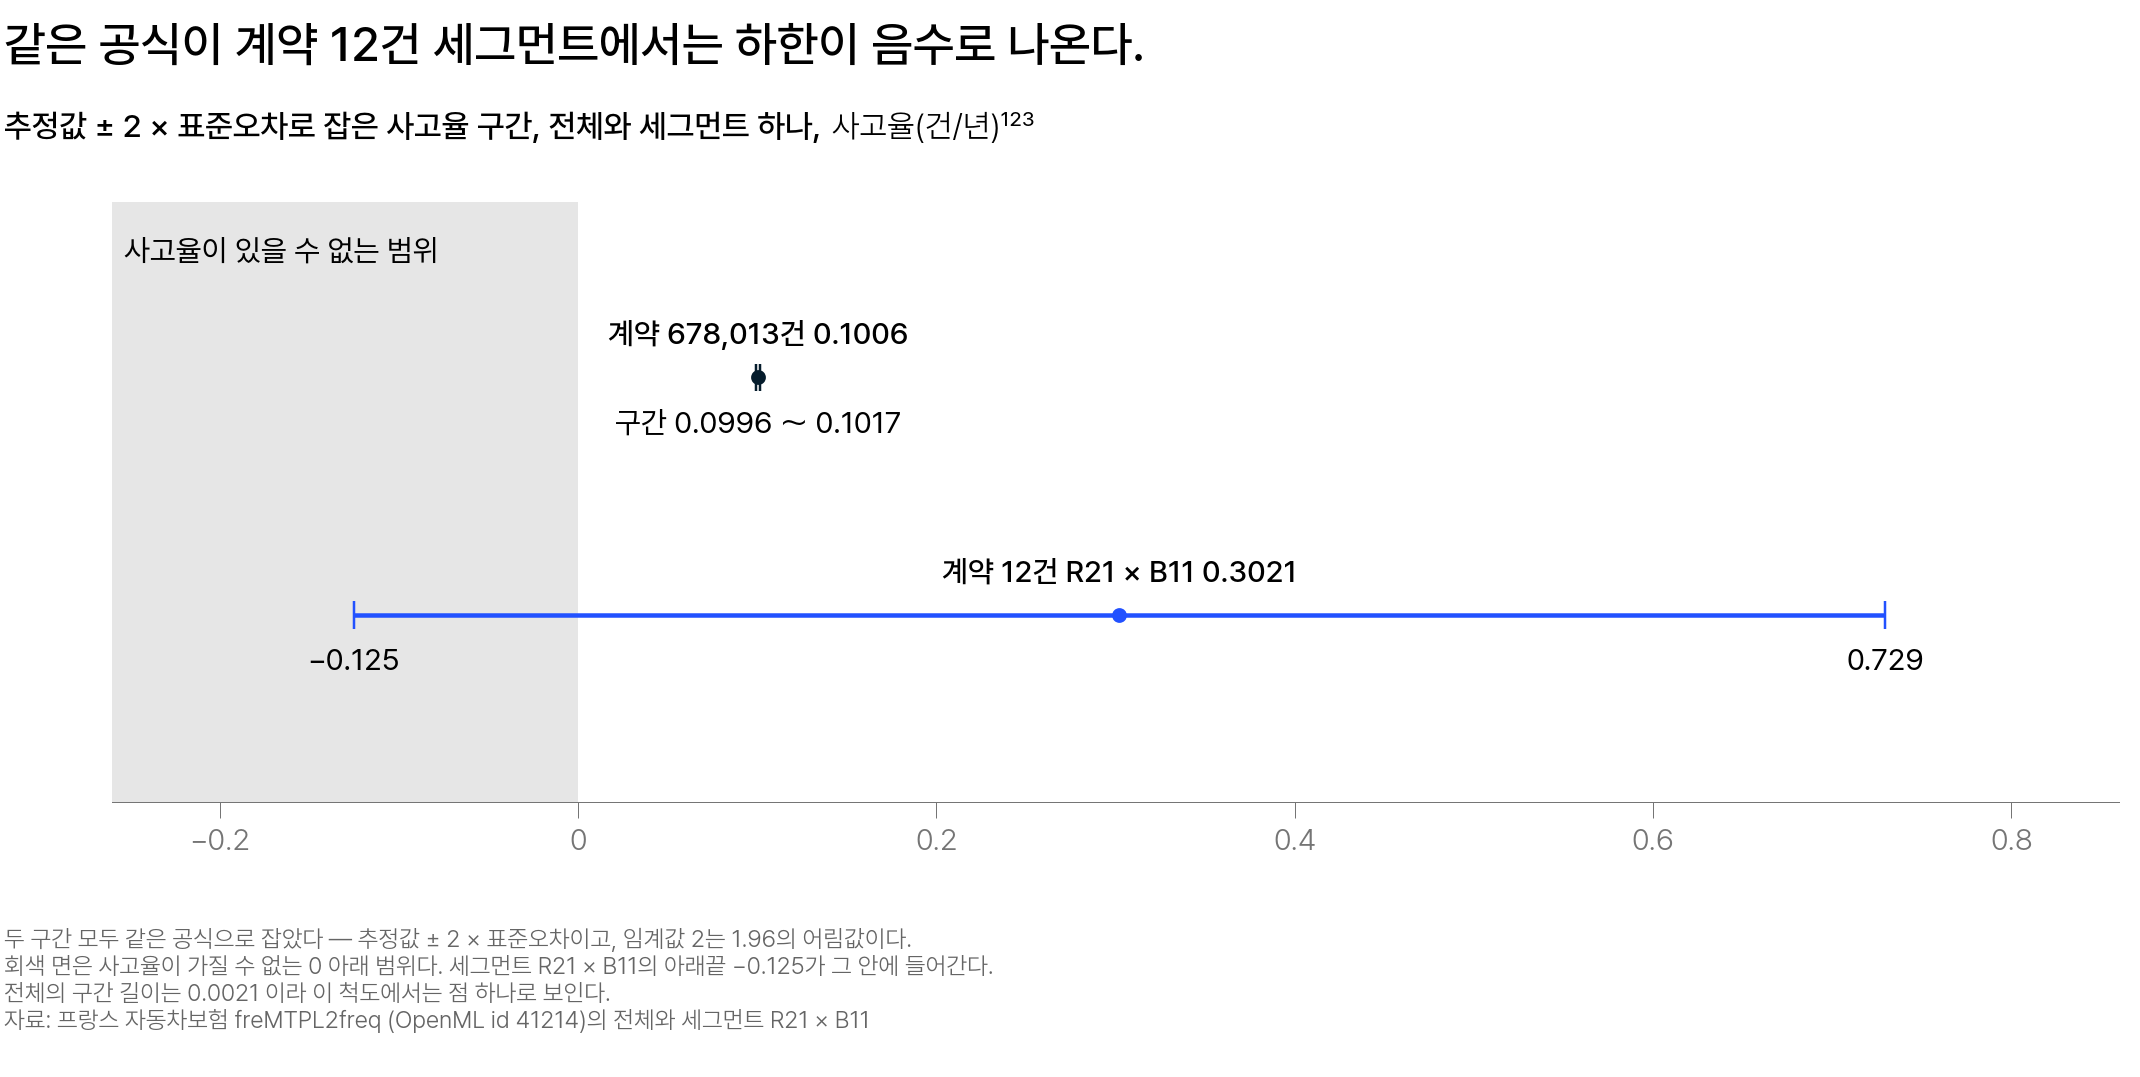

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 같은 공식으로 계산한 사고율 구간 2개 — 계약 678,013건의 구간(남색)은 이 척도에서 점 하나로 보이는데, 계약 12건짜리 R21 × B11 의 구간(파랑 선분)은 아래끝 −0.125 가 회색으로 칠한 「사고율이 있을 수 없는 범위」 안으로 들어간다.</em></p>

> **오늘의 질문 — 공식이 음수인 하한을 산출하는 경우에 불확실성을 어떻게 다시 측정하고, 그렇게 측정한 구간을 얼마나 신뢰할 것인가.**

**그래서** 오늘은 구간을 다시 만드는 일과 그 구간을 믿어도 되는지 점검하는 일을 함께 합니다. 구간이 나오면 요율 회의에서 질문이 이어집니다.

> **"그 구간은 어떤 가정을 전제하고 있습니까?"**

모형이 맞히지 못하고 남긴 값(잔차)이 종 모양인지, 그 산포가 고른지, 관측이 서로 독립인지 — 3개 중 하나만 성립하지 않아도 그 구간의 적중률이 선언한 95%에 못 미칩니다. 어느 가정이 어긋나면 구간이 어느 쪽으로 틀어지는지는 5. 잔차 진단의 표에서 하나씩 구분하고, 계약이 지역 단위로 뭉쳤을 때 표준오차가 얼마나 달라지는지도 거기서 측정합니다.

## 오늘의 절 구성

앞쪽 4개 절에서 추정값의 변동성을 측정하고, 그 값을 구간과 결정으로 옮깁니다. 5. 잔차 진단은 그 구간이 전제한 가정을 점검하고, 6. 정규화와 교차검증은 정규화와 교차검증을 요율 모형에 적용합니다. 7. 오늘의 정리는 1장 정리와 팀 문항 1개입니다.

| 절 | 무엇을 | 새로 정의하는 용어 |
|---|---|---|
| 1. 표준오차 — 추정값의 표본 간 변동 | 같은 공식이 세그먼트마다 다른 답을 내는 이유 | 표집분포 |
| 2. 부트스트랩 — 재표집으로 추정하는 표준오차 | 표본 하나에서 변동성을 만들어 내는 절차 | 부트스트랩 · 백분위 구간 |
| 3. 신뢰구간 — 95%는 무엇에 대한 확률인가 | 95% 가 적용되는 대상과 차이의 구간 | 신뢰구간 · 포획률 · 임계값 |
| 4. 신뢰구간을 이용한 의사결정 | 구간 하나를 판정으로 연결하는 방법 | 신용구간 · 기대손실 · ROPE · 엿보기 |
| 5. 잔차 진단 — 신뢰구간이 전제한 가정의 점검 | 정규성·등분산성·독립성 점검 | 잔차 · 이탈도 잔차 · 과산포 · 군집 표준오차 |
| 6. 정규화와 교차검증 — 계수 축소와 모형 평가 | 계수 축소와 예측오차로 하는 모형 비교 | 정규화 · 표준화 · 설계행렬 · 교차검증 · 폴드 |
| 7. 오늘의 정리와 수업에서 다룰 질문 | 1장 정리와 팀 문항 1개 | |

첫 절인 1. 표준오차는 첫날 쓰던 값을 요율표 세그먼트에 적용해 보는 자리이고, 6. 정규화와 교차검증은 머신러닝 과정에서 배운 방법을 우리 데이터에 다시 적용하는 절이라 둘 다 짧게 지나갑니다.

각 절의 본문은 처음에 읽는 층입니다. 접어 둔 「자세히」는 이해가 막혔을 때나 복습할 때 전개하는 층이고 전개하지 않아도 절이 완결되고 퀴즈가 풀립니다.

<details class="lms-extra"><summary>더 깊이 — 이 권을 마치고 나면 할 수 있게 되는 7가지</summary>

- 표준오차를 손으로 계산하고, 그 값이 요율표 세그먼트마다 왜 달라지는지 설명하기 — 1. 표준오차
- 부트스트랩으로 구간 만들기, 그리고 부트스트랩이 적용되지 않는 통계량 확인하기 — 2. 부트스트랩
- "95%"가 무엇에 대한 숫자인지 한 문장으로 말하기, 두 구간이 겹친다는 관찰을 오독하지 않기 — 3. 신뢰구간
- 신용구간·기대손실·ROPE 로 "차이가 있다/없다"를 넘어 결정까지 도출하기 — 4. 신뢰구간을 이용한 의사결정
- 잔차 그림에서 정규성·등분산성·독립성 가운데 어느 가정이 성립하지 않는지 읽기 — 5. 잔차 진단
- 과산포와 군집 뭉침이 구간 길이를 각각 얼마나 늘리는지 구분해 말하기 — 5. 잔차 진단
- 교차검증 점수를 평균과 폴드 간 산포로 함께 읽고, AIC 와 결과가 다를 때 어디를 확인할지 정하기 — 6. 정규화와 교차검증

</details>

오늘의 순서는 다음과 같습니다. 공식이 맞지 않는 세그먼트에서 구간을 다시 만들어 내고(2. 부트스트랩), 그 구간에 "95%"라는 이름을 정확히 부여하고(3. 신뢰구간), 그 구간으로 결정 하나를 닫고(4. 신뢰구간을 이용한 의사결정), 구간이 전제한 가정을 점검한 뒤(5. 잔차 진단), 셋째 날 AIC 가 고른 모형을 새 데이터의 예측오차 지표로 다시 평가합니다(6. 정규화와 교차검증). 먼저 1. 표준오차에서 첫날의 공식이 12건짜리 세그먼트에서 어떻게 맞지 않는지부터 확인합니다.

> 숫자 하나를 보고서에 싣는 일은 그 숫자에 구간을 함께 제시하고, 그 구간이 전제한 가정까지 점검한 뒤에야 끝납니다.

## 1. 표준오차 — 추정값의 표본 간 변동

## 계약 12건짜리 세그먼트의 사고율 0.3021 을 보고서에 적어도 되는가

**여기서 할 일**

1. 앞서 본 세그먼트 R21 × B11 의 사고율이 표본마다 얼마나 달라지는지 묻습니다.
2. 첫날 쓴 **표준오차** 를 오늘의 사고율 단위(건/년)로 옮겨 적고, 계약 678,013건과 계약 12건에 같은 공식을 넣습니다.
3. 추정값 $\pm 2\,\text{SE}$ 라는 구간 계산 방식이 어느 자리에서 못 쓰게 되는지 확인합니다.

R21 × B11 의 0.3021건/년은 계약 12건이 낸 값입니다. 같은 회사가 이듬해 같은 조건의 계약 12건을 다시 받았다면 그 숫자는 얼마가 되겠습니까. 사고가 1건이었다면 0.15, 3건이었다면 0.45 — 사고 한 건이 오갈 때마다 값이 절반씩 움직이는 자리입니다.

**표준오차(standard error, SE)** 는 추정값이 표본마다 달라지는 정도입니다 — 첫날 $\hat{p} = 0.0502$ 옆에 0.000265 를 적었던 그 값입니다. 데이터 하나하나가 흩어지는 것이 아닙니다. 추정을 되풀이한 결과가 흩어지고 그 결과들이 이루는 분포가 **표집분포** 입니다.

<details class="lms-extra"><summary>자세히 — 표집분포의 정의와 n 이 커질수록 좁아지는 그림</summary>

- **표집분포(sampling distribution)** — 같은 크기의 표본을 반복해 뽑을 때, 그때마다 계산되는 **추정값들**이 이루는 분포입니다.
  - **직관**: 흩어지는 것은 데이터 하나하나가 아니라 추정을 되풀이한 결과입니다. 체온을 10회 측정해 얻은 36.4·36.6·36.5 는 관측값 쪽이고, 「10회씩 측정해 평균 내기」를 날마다 되풀이해 모은 평균들 36.45·36.52·36.48 이 표집분포를 이루는 값입니다.
  - **예시**: 사고율도 같습니다. 같은 조건의 계약을 다른 해에 다시 받았다면 $\hat{\lambda}$ 가 가령 0.0998, 또 다른 해였다면 0.1013 처럼 나왔을 것입니다. 그런 값들이 이 분포 위에 늘어선 점들이고, 우리가 본 $\hat{\lambda} = 0.100614$건/년은 그중 이번에 뽑힌 하나입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Sampling_Distributions_of_the_Sample_Mean_from_a_Non-Normal_Population.png" width="640" height="426"/>
<p align="center"><em>▲ 꼬리가 긴 지수분포 모집단(왼쪽 위)과 거기서 크기 5·15·30 표본을 반복해 뽑아 평균을 모은 나머지 세 패널 — 모집단 모양이 삐뚤어져 있어도 평균의 표집분포는 n 이 커지면 종에 가까워지고 좁아진다. (출처: Wikimedia Commons, "Sampling Distributions of the Sample Mean")</em></p>

패널 4개 가운데 **왼쪽 위 하나만 관측값의 분포**이고 나머지 셋이 표집분포입니다. 세로축 Frequency 는 그 계급구간(bin — 값 범위를 같은 간격으로 나눈 한 조각)에 든 개수로, 왼쪽 위는 관측값의 개수이고 나머지 셋은 표본평균의 개수입니다. $n$ 이 5 → 15 → 30 으로 커지면 평균의 분포는 종 모양에 가까워지고, 가로로 퍼진 범위가 0～40 에서 7.5～27.5 로 좁아집니다. 이 산포에 이름을 부여할 차례입니다.

</details>

오늘은 단위가 노출(계약이 보장을 받은 기간)로 나눈 '1년에 몇 건인가'라, 정의는 그대로 두고 공식만 사고율 단위로 다시 씁니다.

$$
\text{SE}(\hat{\lambda}) = \frac{\sqrt{\sum y_i}}{\sum E_i} = \frac{\sqrt{36{,}056}}{358{,}360} = 0.00053
$$

- $\hat{\lambda}$ : 노출로 나눈 연간 사고율 추정값(건/년)
- $\sum y_i$ : 사고 건수의 합 — 36,056건 · $\sum E_i$ : 노출의 합 — 358,360년

**그래서** 둘째 날 낸 $\hat{\lambda} = 0.100614$건/년의 산포는 0.00053건/년으로, 추정값의 0.5% 수준입니다. 분자에만 제곱근이 있어 계약을 4배 모아야 그 값이 절반이 됩니다.

측정 대상을 같은 데이터에 대해 나란히 정리합니다.

| | 측정 대상 | 이 데이터에서 | 계약이 늘면 |
|---|---|---|---|
| **표준편차** $s$ | 관측값 하나하나가 평균에서 떨어진 정도 | 계약별 사고 건수의 차이 | 거의 그대로다 — 계약을 더 모아도 계약들이 서로 다른 정도는 변하지 않는다 |
| **표준오차** $\text{SE}$ | 추정값의 표본 간 변동 | 다른 해 데이터에서의 $\hat{\lambda}$ 변화 | 줄어든다 — 4배 모으면 절반이 된다 |

맨 오른쪽 열이 둘을 구분하는 기준입니다. "데이터를 더 모으면 좁아지느냐"고 물었을 때 좁아지는 쪽이 표준오차입니다.

<details class="lms-extra"><summary>더 깊이 — 이 식이 나오는 자리, 첫날 식과의 동치, √n 법칙의 수치 확인</summary>

**왜 그렇게 되는지부터 말로 적습니다.** 포아송이 다루는 사고는 드물게 발생하는 사건이라 평균이 작을수록 건수의 변동도 작아지는데, 그 관계가 「분산 = 평균」으로 정리되는 것이 아래 유도의 출발점입니다.

**식으로 옮깁니다.** 포아송은 분산이 평균과 같아 $\operatorname{Var}(Y_i) = \mu_i$ 입니다. 계약들이 서로 독립이면 사고 건수 합의 분산도 그 평균들의 합이고, 관측으로 추정한 값이 $\sum y_i$ 입니다. 여기까지가 분산 더하기입니다.

사고율은 그 합을 상수 $\sum E_i$ 로 나눈 값이므로, 분산은 그 상수의 제곱으로 나뉩니다. 이것이 상수 나누기입니다.

$$
\operatorname{Var}(\hat{\lambda}) = \frac{\sum y_i}{\left( \sum E_i \right)^2}
\quad \Rightarrow \quad
\text{SE}(\hat{\lambda}) = \frac{\sqrt{\sum y_i}}{\sum E_i}
$$

검산: 분산 식에 $\sum y_i = 36{,}056$ 과 $\sum E_i = 358{,}360$ 을 대입하고 제곱근을 씌우면 본문의 0.00053 이 그대로 나옵니다.

첫날에도 이 값을 계산한 적이 있습니다. 거기서는 $\sqrt{\hat{\lambda} / \sum E_i}$ 를 썼고, 값을 대입하면 $\sqrt{0.1006 / 358{,}360} = 0.00053$ 이었습니다. 오늘 식과 값이 같은 것은 같은 식을 변형해 적은 형태이기 때문입니다.

**⑴ $\hat{\lambda}$ 의 정의를 그대로 대입합니다.** $\hat{\lambda} = \sum y_i / \sum E_i$ 이니 제곱근 안이 이렇게 됩니다.

$$
\sqrt{\frac{\hat{\lambda}}{\sum E_i}} = \sqrt{\frac{\sum y_i / \sum E_i}{\sum E_i}}
$$

**⑵ 분수를 분수로 나눈 자리를 정리합니다.** 분모에 $\sum E_i$ 를 추가로 곱하는 것과 같으므로 제곱근 안은 다음과 같이 정리됩니다.

$$
\sqrt{\frac{\sum y_i}{(\sum E_i)^2}}
$$

**⑶ 제곱근을 분자와 분모에 따로 씌웁니다.** $\sqrt{a/b} = \sqrt{a}/\sqrt{b}$ 이고 $\sqrt{(\sum E_i)^2} = \sum E_i$ 이니

$$
\frac{\sqrt{\sum y_i}}{\sum E_i}
$$

가 되어 본문의 식과 글자까지 같아집니다. 검산도 해 봅니다 — $\sqrt{36{,}056} = 189.9$ 를 358,360 으로 나누면 0.00053 으로, ⑴ 의 값과 같습니다.

**표본평균의 공식과도 같은 구조입니다.** 표본평균의 표준오차는 $\text{SE}(\bar{x}) = s / \sqrt{n}$ 이라 적는데($\bar{x}$ 는 표본평균, $s$ 는 표본의 표준편차, $n$ 은 관측 수), 셋 다 「추정값 = 합 ÷ 관측량」 형태에서 유도됩니다. 표준오차는 **분자인 합의 분산을 분모의 제곱으로 나눈 뒤 제곱근을 씌운 값**입니다.

**이제 제곱근 법칙을 숫자로 확인합니다.** 같은 회사에서 계약을 4배 받으면 노출 합 $\sum E_i$ 도 대략 4배, 사고 합 $\sum y_i$ 도 대략 4배가 됩니다. 분자는 제곱근 안에 있으니 $\sqrt{\sum y_i}$ 는 $\sqrt{4} = 2$ 배만 커집니다.

$$
\frac{\sqrt{4 \sum y_i}}{4 \sum E_i} = \frac{2\sqrt{\sum y_i}}{4 \sum E_i} = \frac{1}{2} \cdot \frac{\sqrt{\sum y_i}}{\sum E_i}
$$

곧 4배를 모아야 표준오차가 절반입니다. 지금의 0.00053 을 0.00027 로 줄이려면 계약을 $678{,}013 \times 4 = 2{,}712{,}052$, 곧 **271만 건**까지 늘려야 하고, 4분의 1 인 0.00013 까지 줄이려면 16배인 1,085만 건이 필요합니다. 첫날 3절의 「$n$ 이 네 배가 되면 표준오차는 절반」과 같은 문장인데, 기준량이 계약 수에서 노출 합으로 바뀌었을 뿐입니다.

</details>

## 세그먼트 R21 × B11 에서 ± 2 SE 구간이 성립하지 않는 이유

요율표는 세그먼트마다 나누어 산정합니다. 그렇게 쪼개면 계약이 10여 건뿐인 세그먼트가 생깁니다 — 앞서 본 **R21 × B11** 이 그렇습니다.

| 세그먼트 | 계약 수 | 사고 | 노출 합 | $\hat{\lambda}$ | 표준오차 | $\pm 2\,\text{SE}$ 구간 |
|---|---|---|---|---|---|---|
| 전체 | 678,013 | 36,056건 | 358,360년 | 0.1006 | 0.00053 | 0.0996 ～ 0.1017 |
| R21 × B11 | 12 | 2건 | 6.62년 | 0.3021 | 0.2136 | $-0.125$ ～ 0.729 |

같은 공식에 사고 2건과 노출 6.62년을 대입하면 표준오차 $\text{SE}(\hat{\lambda})$ 가 0.2136 — **추정값 0.3021 의 70%** 이고 전체의 403배입니다. 그런데 그 방식으로 만든 구간이 $0.3021 \pm 2 \times 0.2136$, 곧 $-0.125$ ～ 0.729 라 아래쪽 끝이 사고율에 있을 수 없는 음수입니다.

표준오차 0.2136 이 커서가 아닙니다. 사고 2건짜리 세그먼트의 표집분포는 왼쪽이 0 에서 잘리고 오른쪽으로 늘어진 모양이라, 좌우로 똑같이 벌리는 대칭 구간이 애초에 맞지 않습니다. **「넓다」가 아니라 「이 방법으로는 측정할 수 없다」** 고 읽어야 합니다. 치우침까지 반영해 좌우 꼬리를 2.5%씩 **각각** 잘라 낸 **정확 포아송 구간**으로 다시 계산하면 **0.04 ～ 1.09건/년**이 나옵니다.

<details class="lms-extra"><summary>자세히 — 세그먼트 242개의 계산과 정확 포아송 구간을 카이제곱 분위수로 잘라 내는 계산</summary>

**세그먼트가 몇 개나 생기나.** 이 데이터에 든 지역은 22개, 차량 브랜드는 11개라 둘을 겹치면 $22 \times 11 = 242$ 개의 세그먼트가 생깁니다. 계약 678,013건을 242 로 나누면 세그먼트 하나에 평균 2,800건이지만, 계약은 고르게 흩어지지 않아 R21 × B11 처럼 12건짜리 세그먼트가 나옵니다. 둘째 날 수축 위젯 첫 화면에 있던 `세그먼트 노출 E` 6.62년이 바로 이 세그먼트입니다.

**표준오차를 줄이려면 얼마나 모아야 하나.** 앞 접힘의 4배 계산을 그대로 적용하면, 계약 12건을 4배인 **48건**까지 늘려야 0.2136 이 0.107 로 내려가고 16배인 **192건**이라야 0.053 이 됩니다. 0.053 도 추정값 0.30 의 18% 라, 요율표에서 세그먼트를 잘게 쪼갤수록 표준오차가 빠르게 커지고, 커진 표준오차는 같은 배수의 계약으로는 잘 줄어들지 않는다는 뜻입니다. 계약을 더 모으지 않고 이 한계를 넘으려면 이 과정 마지막 날의 계층 모형으로 가야 합니다.

**정확 포아송 구간 0.04 ～ 1.09 는 어디서 나오나.** 사고 $y = 2$ 건에서 꼬리를 2.5%씩 잘라 낸 사고 '건수'의 구간은 **카이제곱 분위수**로 떨어집니다. 카이제곱 분포에서 왼쪽부터 넓이를 누적해 그 비율만큼을 담았을 때의 가로축 값입니다. 파이썬으로는 `scipy.stats.chi2.ppf(0.025, 4)` 처럼 확률과 자유도를 지정해 얻습니다(이 함수는 0.4844 를 반환합니다).

**자유도가 $2y$ 와 $2y+2$ 로 갈리는 이유.** 이 구간은 좌우 대칭이 아닙니다 — 사고가 2건뿐이면 아래로 갈 여지와 위로 갈 여지가 서로 다른 만큼만 남아서, 아래끝과 위끝을 각각 다른 자유도에서 계산합니다. 포아송의 꼬리확률은 카이제곱의 꼬리확률로 그대로 바꿔 쓸 수 있습니다. $P(Y \ge y \mid \mu) = P(\chi^2_{2y} \le 2\mu)$ 이고 $P(Y \le y \mid \mu) = P(\chi^2_{2y+2} \ge 2\mu)$ 입니다.

아래쪽 끝은 「$y$ 건 이상」을 2.5% 로 맞추는 $\mu$ 라 자유도가 $2y$ 입니다. 위쪽 끝은 「$y$ 건 이하」를 2.5% 로 맞추는 $\mu$ 인데, 이쪽은 0건부터 $y$ 건까지 항이 하나 더 들어가 자유도가 2 만큼 큰 $2y+2$ 가 됩니다.

**⑴ 아래쪽 끝은 자유도 $2y$ 에서 잘라 냅니다.** 자유도 자리에 $2y = 2 \times 2 = 4$ 를 넣습니다.

$$
\frac{\chi^2_{0.025}(2y)}{2} = \frac{\chi^2_{0.025}(4)}{2}
$$

자유도 4 인 카이제곱의 2.5% 분위수가 0.4844 이니, 그 값을 2 로 나눕니다.

$$
\frac{0.4844}{2} = 0.242 \ \text{건}
$$

**⑵ 위쪽 끝은 자유도 $2y+2$ 에서 잘라 냅니다.** 자유도 자리에 $2y + 2 = 2 \times 2 + 2 = 6$ 을 넣습니다.

$$
\frac{\chi^2_{0.975}(2y+2)}{2} = \frac{\chi^2_{0.975}(6)}{2}
$$

자유도 6 인 카이제곱의 97.5% 분위수가 14.4494 이니, 그 값을 2 로 나눕니다.

$$
\frac{14.4494}{2} = 7.2247 \ \text{건}
$$

아래위 자유도가 4 와 6 으로 갈리는 탓에 좌우 대칭이 성립하지 않습니다.

**⑶ 두 건수를 노출로 나눕니다.** 건수의 구간을 먼저 잡고 노출 6.62년으로 나누면 사고율의 구간이 됩니다.

$$
\frac{0.242}{6.62} = 0.037, \qquad \frac{7.2247}{6.62} = 1.091
$$

본문의 **0.04 ～ 1.09건/년**이 이 2개 값입니다. 분위수 값을 외울 필요는 없고, '건수의 구간을 먼저 잡고 노출로 나눈다'는 순서만 남기면 됩니다.

</details>

참값이 우리가 본 값이라 치고 사고 건수를 5,000번 다시 뽑아, 두 구간을 나란히 그려 봅니다.

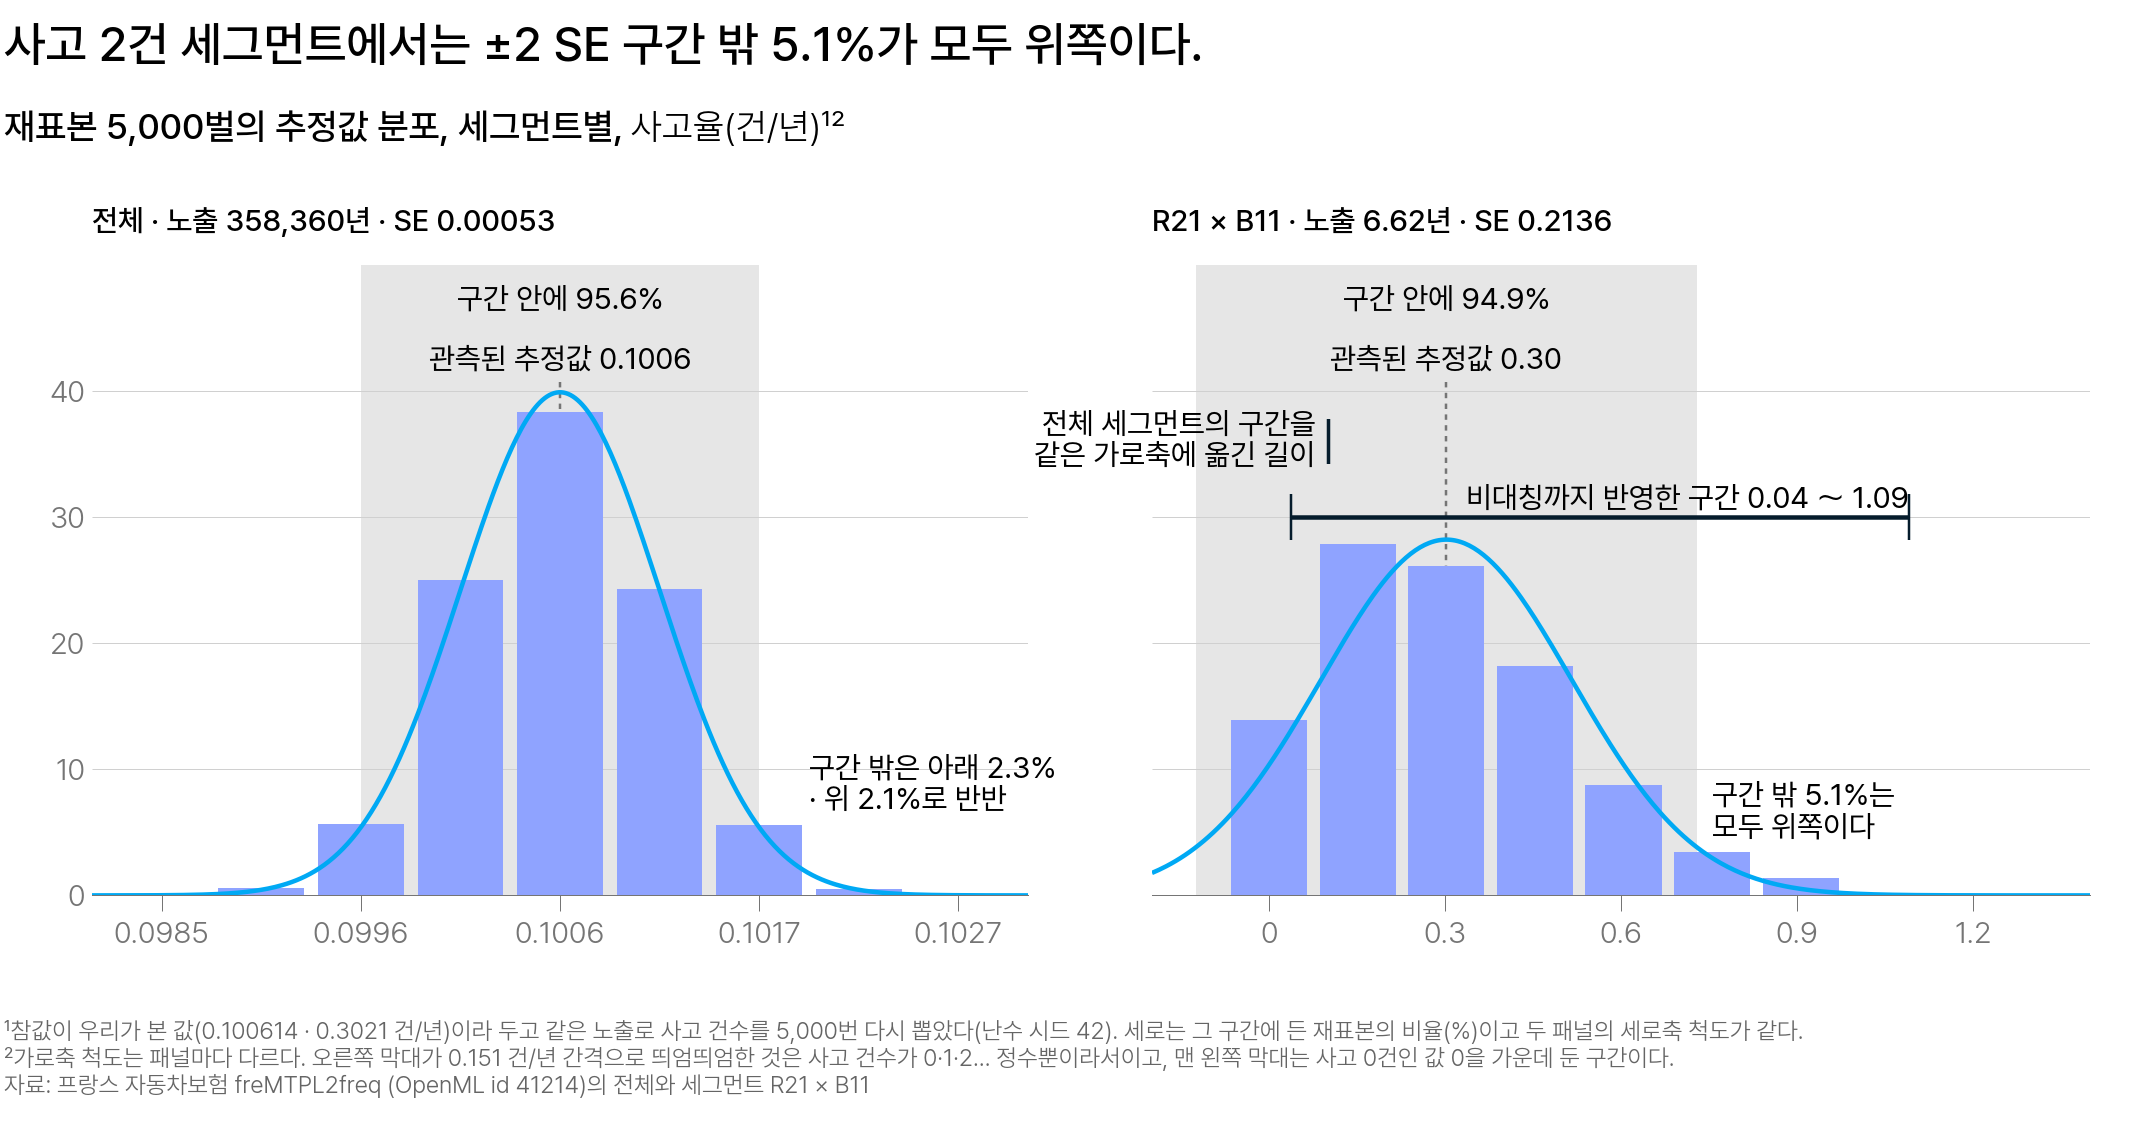

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 그림 1(왼쪽) 계약 678,013건 전체 · 그림 2(오른쪽) 세그먼트 R21 × B11 — 같은 노출로 사고 건수를 5,000번 다시 뽑아 그린 추정값 분포. 그림 2 는 ± 2 SE 구간을 벗어난 5.1%가 모두 위쪽으로 몰려, 그 구간의 오른쪽 끝 0.729 가 치우침까지 반영해 다시 계산한 1.09 에 한참 못 미친다.</em></p>

그림의 요소 5개는 다음과 같이 읽습니다.

- **연파랑 막대** — 같은 노출로 다시 뽑아 계산한 사고율
- **하늘색 곡선** — 같은 표준오차로 그린 종 모양 근사
- **회색 구간** — 우리가 본 값 ± 2 SE
- **긴 남색 선분** — 치우침까지 반영해 다시 계산한 구간 0.04 ～ 1.09건/년
- **짧은 남색 막대** — 그림 1 의 구간 길이 0.0021 을 그림 2 의 가로축으로 옮겨 그린 표시(그림 2 왼쪽 위, 긴 남색 선분 바로 위)

그림 1 은 회색 구간 안에 95.6%가 들어오고 벗어난 4.4%도 아래 2.3% · 위 2.1%로 나뉩니다. 그림 2 는 회색 구간 안이 94.9%로 비슷해 보이지만 **벗어난 5.1%가 전부 위쪽**이고, 회색 구간의 오른쪽 끝 0.729 도 긴 남색 선분의 오른쪽 끝 1.09 에 크게 못 미칩니다.

**그래서** 판단은 두 단계로 나뉩니다. **구간을 만드는 방식이 이 자리에 맞는지를 정하는 것은 막대의 형태**입니다. 막대가 한쪽으로 늘어져 있으면 좌우로 똑같이 벌리는 방식 자체가 맞지 않습니다. **방식이 맞는 구간끼리 견줄 때 판정을 가르는 것은 구간 길이**입니다.

여기서 걸린 것은 앞쪽, 곧 형태 쪽입니다. 요율표에서 위쪽 끝은 "이만큼은 대비해야 한다"를 적는 항목인데, 구간을 0.729 에서 끊으면 최악의 경우를 약 3분의 1 잘라 낸 결과가 됩니다.

<details class="lms-extra"><summary>더 깊이 — 그림 2 에서 0 미만 구간이 비어 있는 이유</summary>

**⑴ 벗어난 5.1% 가 한쪽으로만 몰린 것은 사고율의 하한이 0 이라는 점 때문입니다.** 사고율이 가질 수 있는 가장 작은 값은 사고 0건일 때의 0 입니다. 그보다 아래로 벗어날 값이 아예 없으니, 회색 구간 밖으로 벗어날 곳은 위쪽뿐입니다. 그림 2 에서 0 아래에 위치한 것은 회색 구간의 왼쪽 끝 $-0.125$ 와 하늘색 곡선의 왼쪽 자락뿐인데, 둘 다 **막대가 하나도 없는 범위**입니다. 좌우 대칭 구간을 만들었더니 그 구간의 왼쪽 절반이 값이 존재할 수 없는 범위에 위치한 상태입니다.

**⑵ `전체 세그먼트의 구간을 같은 가로축에 옮긴 길이` 라벨은 그림 2 의 왼쪽 위, 긴 남색 선분 바로 위에 표시되어 있습니다.** 그 라벨에 딸린 짧은 남색 막대가 두 그림의 가로축 척도를 비교하기 위해 그린 표시입니다. 두 그림은 가로축 척도가 달라서(그림 1 이 0.0985～0.1027, 그림 2 가 0～1.2 남짓) 회색 구간의 길이를 눈으로 비교할 수 없습니다. 그래서 그림 1 의 구간 길이 0.0021 을 그림 2 의 가로축 위에 그대로 옮겨 그렸고 그것이 그 짧은 남색 막대입니다. 그림 2 의 구간 길이 0.855 와 403배 차이라, 같은 가로축에 배치하면 선분이 아니라 점 하나로 보입니다.

</details>

#### 핵심 주의점

표준오차를 데이터가 흩어진 정도처럼 해석하면 안 됩니다.

$$
\text{SE}(\hat{\lambda}) = \frac{\sqrt{\sum y_i}}{\sum E_i}
$$

이 식이 측정하는 것은 계약마다 사고 건수가 다른 정도가 아니라 추정값 하나가 표본마다 달라지는 정도입니다. 따라서 "계약들이 0.00053건/년씩 서로 다르다" 는 틀린 문장입니다.

정확한 뜻은 다음과 같습니다.

> **계약 678,013건에서 계산한 0.00053건/년은, 다른 해 데이터로 다시 추정했을 때 $\hat{\lambda} = 0.100614$건/년이 달라지는 정도다.**

> 표준오차는 그 변동의 크기를 측정하지만, 그 값을 좌우로 동일하게 적용해도 되는지는 표집분포의 모양이 정한다.

공식이 있어도 사용할 수 없는 경우가 이렇고, 애초에 공식이 없는 통계량은 더 많습니다 — 중앙값, 두 값의 비율, 모형 간 성능 차이가 그렇습니다. 다음 절에서 두 경우를 함께 다룹니다.

> **[문제] 그림 2 에서 회색 구간의 오른쪽 끝 0.729 보다 큰 사고율은 재표본 5,000벌 가운데 5.1% 였지만, 긴 남색 선분의 오른쪽 끝 1.09 보다 큰 벌은 그보다 훨씬 드물다. 그 두 끝 사이에 선 막대들이 곧 ±2 SE 가 잘라 낸 '최악의 경우' 구간이다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 2. 부트스트랩 — 재표집으로 추정하는 표준오차

## 표집분포 추정의 제약 — 표본이 하나뿐인 상황

**여기서 할 일**

1. 표본 하나를 모집단으로 간주하고 다시 뽑는 **부트스트랩** 절차를 4단계로 적습니다.
2. 계약 12건짜리 세그먼트와 청구 30건에 그 절차를 적용해 표준오차 하나와 95% 구간 하나를 냅니다.
3. 재표본 수 $B$ 를 늘려 보고, 구간 길이를 정하는 것이 무엇인지 구분합니다.

표집분포를 그리려면 모집단에서 표본을 **반복해서** 뽑아야 했는데, 우리 손에 있는 것은 **표본 하나뿐입니다.** 계약 678,013건도 1회 추출된 표본 1개입니다. 에프론(1979)은 모집단에서 다시 뽑을 수 없다면 표본을 모집단으로 삼아 거기서 다시 뽑자고 제안했습니다.

무작위로 뽑힌 표본은 **모집단의 축소판**이라, 거기서 다시 뽑으면 "표본을 새로 뽑는 일" 의 근사가 됩니다.

**부트스트랩(bootstrap)** — 새 데이터를 더 받지 않고, 가지고 있는 표본 하나를 복원추출로 다시 뽑아 "다른 해에 뽑았다면 어땠을까"를 근사하는 방법입니다. 제 신발끈을 당겨 스스로 몸을 일으킨다는 관용구에서 온 이름이고, 발상은 그림 1장이 전부입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Illustration_bootstrap.svg" width="640" height="195"/>
<p align="center"><em>▲ 부트스트랩 절차 — 변동성은 새 데이터가 아니라 표본 하나를 복원추출로 다시 뽑아 만들어 낸다. (출처: Wikipedia)</em></p>

<details class="lms-extra"><summary>더 깊이 — 그림의 색·기호와 가로축·세로축의 의미</summary>

왼쪽 상자를 채운 파란 점이 모집단(population)입니다. 거기서 화살표 하나(random sample)로 뽑아 낸 갈색 점 뭉치가 원 표본(original sample)입니다. 오른쪽 재표본(resamples) 상자 4개는 모두 그 원 표본 안에서 다시 뽑은 것입니다. 뽑는 방식은 복원추출, 즉 뽑은 값을 표본에 그대로 반환한 뒤 다시 뽑는 것입니다.

그래서 재표본 1벌 안에 같은 관측이 2번 이상 들어올 수 있습니다. 겹쳐 뽑힌 자리는 갈색 점 위에 빨간 점으로 포개져 있습니다. 모집단으로 되돌아가는 화살표는 없습니다.

상자 아래 세로로 찍힌 점 3개(⋮)는 재표본이 4벌로 끝나지 않는다는 표시입니다. 실제로는 수백에서 수천 벌을 뽑습니다.

맨 오른쪽 히스토그램은 재표본 1벌마다 통계량을 하나씩 계산해 그 값들을 가로축에 배열한 것입니다. 그림의 compute statistic x가 그 계산 단계입니다. 어느 위치에 몇 개가 몰렸는지 집계해 누적하면 막대가 됩니다. 가로축 x는 통계량 값, 세로축 relative frequency는 재표본 가운데 그 값이 나온 비율입니다. 가로축과 세로축에 적힌 숫자는 절차를 보이기 위한 예시 값이고, 같은 히스토그램을 이 절 뒤에서 우리 지급액으로 다시 그립니다.

</details>

맨 오른쪽 히스토그램이 오늘의 목적지입니다. 구간은 이 히스토그램의 양끝을 2.5%씩 잘라 내고 남은 가운데 95% 이고, 그 구간 길이가 앞 절 질문의 답입니다.

## 재표본 1벌의 수치 — 계약 12건에서 다시 뽑기

절차를 적기 전에 손으로 1벌만 뽑아 봅니다. 세그먼트 R21 × B11 의 계약 12건 가운데 사고가 난 계약은 2건이고, 그 둘의 노출은 각각 0.63년과 0.06년입니다. 이 12건에서 중복을 허용해 12번을 뽑았더니 노출 0.06년짜리 사고 계약이 3번 들어오고 노출 0.63년짜리는 1번도 들어오지 않은 재표본이 나왔습니다. 그 벌의 사고 합은 3건, 노출 합은 5.07년입니다.

$$
\hat{\lambda}^{*} = \frac{3}{5.07} = 0.5917 \ \text{건/년}
$$

- $\hat{\lambda}^{*}$ : 재표본 1벌에서 계산한 사고율 추정값 — 별표는 원 표본이 아니라 재표본에서 나온 값이라는 표시입니다
- 분자 3 : 그 벌에 든 사고 건수의 합 · 분모 5.07 : 그 벌에 든 노출의 합(년)

원 표본의 0.3021 이 재표본 1벌 만에 0.5917 까지 올라갔습니다. 이렇게 움직인 값을 수천 벌 모아 얻은 구간 길이가 곧 "다른 해였다면" 의 답입니다.

## 부트스트랩 절차 4단계

1. 원 표본 $n$개에서 **복원추출**로 $n$개를 다시 뽑는다 — 이것이 재표본 1벌.
2. 그 재표본으로 관심 있는 통계량을 계산한다(평균·중앙값·회귀계수 무엇이든).
3. 1～2를 $B$번 되풀이해 통계량 $B$개를 모은다 — 이것이 **부트스트랩 분포**.
4. 그 분포의 표준편차가 **표준오차**, 정렬해서 2.5%와 97.5% 지점을 자르면 **95% 백분위 구간**.

- **복원추출(resampling with replacement)**
  - **정의**: 뽑은 값을 표본에 반환한 뒤 다시 뽑습니다.
  - **의미**: 같은 관측이 2~3번 들어가고 어떤 관측은 1번도 뽑히지 않습니다. 반환하지 않으면 순서만 다른 원 표본이 나와 변동성이 0 이 됩니다.

방금 재표본 1벌에서도 값을 움직인 것은 겹침과 빠짐이었습니다. 노출 0.06년짜리가 3번 들어오고 0.63년짜리가 빠지면서 사고율이 0.29 만큼 증가했습니다.

근사해 쓰는 것은 **중심이 아니라 산포**입니다. 표집분포의 중심은 알 수 없는 참값 $\mu$ (뮤) 지만 부트스트랩 분포의 중심은 손에 있는 $\bar{x}$ 라, 원 표본이 치우쳐 있으면 그 치우침은 끝까지 남습니다.

## 지급액 30건에 대한 부트스트랩의 수치 적용

계약 원장에는 짝이 되는 지급액 파일이 하나 더 있습니다. 계약 ID 로 원장과 연결되는 청구 기록이고, 지역 R24 와 차량 출력 등급 12 가 겹치는 계약에서 지급된 청구가 정확히 30건입니다. 그 30건의 지급액을 정렬하면 이렇습니다(유로 단위로 반올림해 적었고, 계산에는 센트까지 씁니다).

<div align="center"><pre style="display:inline-block;text-align:right;">   78    81    88   157   498   564   602   602   606   819
  873   904  1128  1128  1128  1172  1172  1204  1204  1204
 1204  1204  1204  1204  1322  2122  2781  4115  6511 16334</pre></div>

- 표본평균 $\bar{x} = 1{,}773.79$유로
- 표본표준편차 $s = 3{,}030.87$유로
- 공식으로 계산한 표준오차 $s/\sqrt{30} = 553.36$유로

오른쪽 꼬리가 길어(16,334 가 혼자 멀리 있습니다) 평균의 분포가 종 모양일지 의심스럽습니다. 부트스트랩은 그런 가정 없이 데이터에서 변동성을 직접 계산합니다.

1～2단계를 1벌만 더 따라가 보면, 30개에서 중복 허용으로 30번 뽑은 첫 재표본의 평균은 **1,679.01유로** 로 원 표본의 1,773.79 보다 94.78 낮은 값입니다. 이 차이를 4,000벌 모아 표준오차를 계산하는 것이 전부입니다.

In [ ]:
# 부트스트랩 백분위 구간 - 정렬해서 2.5%와 97.5% 지점을 자른다
import numpy as np


def percentile_ci(stats_boot, level=95):
    lo = (100 - level) / 2                      # 95% 면 2.5
    return np.percentile(stats_boot, [lo, 100 - lo])


# stats_boot 은 재표본마다 계산한 통계량 B 개짜리 배열이다

##### 부트스트랩 표준오차와 공식 표준오차의 대조

아래 코드가 지급액 30건에서 재표본 4,000벌을 뽑아, 부트스트랩 표준오차와 공식 $s/\sqrt{n}$ 을 나란히 출력합니다. 앞 셀에서 정의한 `percentile_ci` 대신 그 안의 1행 `np.percentile` 을 전개해 두었습니다. 평균 대신 중앙값을 계산한 결과와, 최댓값 1건을 제외했을 때의 결과도 같은 카드가 함께 출력합니다.

In [ ]:
# 부트스트랩 표준오차와 백분위 구간을 손으로 만들어 공식과 대조하기
import numpy as np

x = np.array([78.33, 80.50, 87.81, 156.82, 497.84, 564.06, 602.00, 602.00, 606.27, 819.13,
              873.26, 903.97, 1128.12, 1128.12, 1128.12, 1172.00, 1172.00, 1204.00, 1204.00, 1204.00,
              1204.00, 1204.00, 1204.00, 1204.00, 1321.73, 2122.36, 2780.99, 4114.87, 6511.06, 16334.36],
             dtype=float)                       # 지급액 30건 (유로)
n, B = len(x), 4000                             # 재표본 4,000 벌

rng = np.random.default_rng(2026)               # 시드 고정 - 실행할 때마다 같은 결과
idx = rng.integers(0, n, size=(B, n))           # 복원추출 - 0~29 를 중복 허용으로 뽑는다
boot_means = x[idx].mean(axis=1)                # 재표본마다 평균 하나

lo, hi = np.percentile(boot_means, [2.5, 97.5])   # 앞 셀 percentile_ci(boot_means) 와 같은 계산
print(f"원 표본 평균          : {x.mean():.2f} 유로")
print(f"부트스트랩 표준오차   : {boot_means.std(ddof=1):.2f} 유로")
print(f"공식 표준오차 s/√30   : {x.std(ddof=1) / np.sqrt(n):.2f} 유로")
print(f"95% 백분위 구간       : {lo:.1f} ~ {hi:.1f} 유로")

# 재표본 1벌에 같은 관측이 들어간 최대 횟수 - 복원추출의 흔적
first = np.bincount(idx[0], minlength=n)
print()
print("첫 재표본에서 1번도 뽑히지 않은 관측 :", int((first == 0).sum()), "개")
print("가장 많이 뽑힌 관측의 횟수         :", int(first.max()), "번")

# 공식이 없는 통계량도 절차는 그대로 - 평균 대신 중앙값을 계산한다
boot_med = np.median(x[idx], axis=1)
med_lo, med_hi = np.percentile(boot_med, [2.5, 97.5])
print()
print(f"중앙값 부트스트랩 SE  : {boot_med.std(ddof=1):.2f} 유로")
print(f"중앙값 95% 구간       : {med_lo:.1f} ~ {med_hi:.1f} 유로")

# 원 표본에서 16,334 1건을 제외하면 - 부트스트랩은 빠진 건을 반영하지 못한다
x_drop = x[x != 16334.36]
idx_d = np.random.default_rng(2026).integers(0, len(x_drop), size=(B, len(x_drop)))
md = x_drop[idx_d].mean(axis=1)
d_lo, d_hi = np.percentile(md, [2.5, 97.5])
print()
print(f"16334 제외 평균/SE/95% 구간 : {x_drop.mean():.1f} / {md.std(ddof=1):.2f} / {d_lo:.1f} ~ {d_hi:.1f} 유로")
print(f"재표본 최댓값이 16334 인 비율 : {(x[idx].max(axis=1) == 16334.36).mean() * 100:.0f} %")

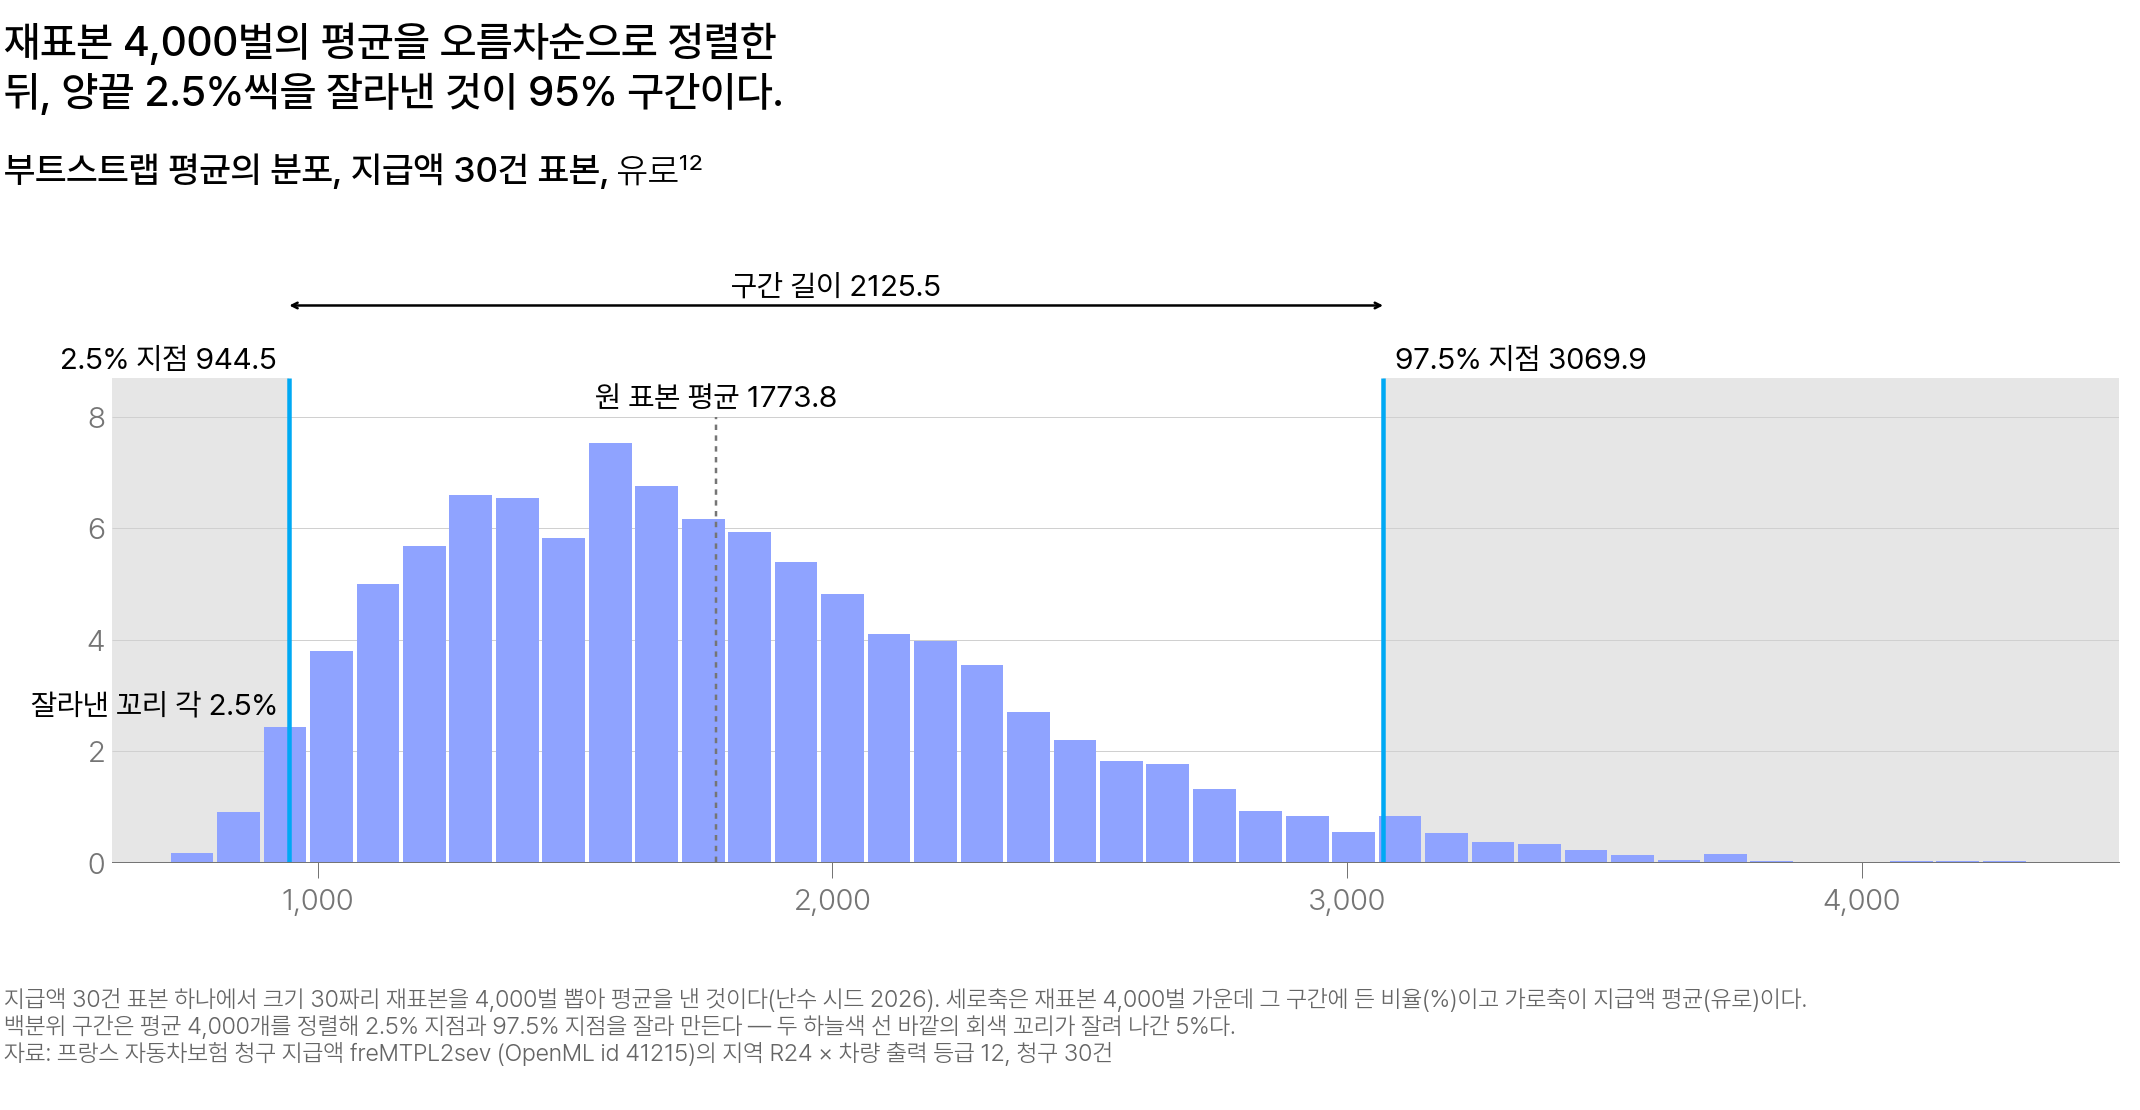

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 지급액 30건 표본에서 크기 30짜리 재표본을 4,000벌 뽑아 평균을 크기순으로 배열한 부트스트랩 분포 — 양 끝 2.5%씩을 잘라 낸 하늘색 세로선 둘 사이가 95% 구간 944.5 ～ 3,069.9유로이고, 두 선 사이 화살표로 적은 그 구간 길이가 2,125.5다.</em></p>

그림은 요소 4개로 읽습니다.

- **연파랑 막대** — 재표본 평균 4,000개 가운데 그 구간에 든 비율(%)
- **회색 꼬리** — 하늘색 선 바깥에서 각각 2.5%씩 잘려 나간 구간
- **회색 점선** — 참값이 아니라 원 표본 평균 1,773.8유로
- **분포의 표준편차 548.56** — 곧 부트스트랩 표준오차

#### 결과 해석

부트스트랩 표준오차는 **548.56유로**, 공식 $s/\sqrt{30}$ 은 **553.36유로** — 4.80유로, 비율로 0.87% 차이입니다. 재추출로 계산하는 방법이 공식과 사실상 같은 값을 산출했습니다. **다만 부트스트랩 쪽은 "평균의 분포가 정규분포다" 라는 가정을 쓰지 않았습니다** — 변동성을 데이터에서 직접 계산하므로, 꼬리가 길어 분포가 종 모양에서 벗어나도 구간이 그만큼 비대칭으로 계산됩니다.

그 4.80 은 원인이 하나가 아닙니다. 세 숫자를 순서대로 적으면 나뉩니다.

⑴ **공식 553.36** — 편차제곱합을 $n - 1 = 29$ 로 나눠 만든 값입니다.

⑵ **이론상 기대되는 값 544.06** — 재표본이 뽑히는 분포는 같은 제곱합을 30 으로 나눈 분산을 가지므로, 그 비에 제곱근을 씌운 $\sqrt{29/30} = 0.983$ 을 곱합니다. $553.36 \times 0.983 = 544.06$ 이라 공식보다 9.30 아래, 비율로 **1.7% 아래**입니다. **나누는 수가 29 와 30 으로 다른** 데서 오는 몫입니다.

⑶ **실제로 나온 548.56** — ⑵ 보다 4.50 위입니다. 재표본 4,000벌을 어느 난수로 뽑았는지에 따른 몫입니다.

곧 공식과의 차이 4.80 은 아래로 끌어내린 9.30 과 위로 복원한 4.50 이 합쳐진 값입니다($-9.30 + 4.50 = -4.80$). 재표본을 더 뽑으면 ⑶ 의 4.50 만 0 으로 줄어들고 ⑵ 의 9.30 은 그대로 남습니다.

95% 백분위 구간은 **944.5유로에서 3,069.9유로**, 구간 길이 2,125.5입니다. 평균 1,773.8에서 왼쪽 829.3, 오른쪽 1,296.2 — 오른쪽이 1.6배 더 넓은 것은 긴 꼬리(16,334)의 흔적이고, 이 두 수가 앞서 말한 '근사해 얻은 산포' 입니다.

**그래서** 통계량이 무엇이든 절차는 그대로입니다. $s/\sqrt{n}$ 같은 공식이 없는 중앙값까지 같은 절차로 덮는 점이 부트스트랩의 값어치입니다. 코드에서 `.mean(axis=1)` 을 `np.median(..., axis=1)` 로 한 군데만 바꾸면 중앙값의 표준오차 **103.25유로**, 95% 구간 **846.2 ～ 1,204.0유로** 가 나옵니다. 평균 쪽 548.56 의 5분의 1인데, 중앙값은 맨 오른쪽 16,334 가 재표본에 몇 번 더 들어오든 위치가 거의 변하지 않기 때문입니다.

<details class="lms-extra"><summary>자세히 — 편차제곱합을 29 로 나누는 이유와 뽑히지 않은 관측 11개의 계산</summary>

관측 30개가 평균에서 떨어진 거리를 제곱해 모두 더한 값을 **편차제곱합**이라고 합니다. 아래에서는 그 값을 $\mathrm{SS}$ 라 적습니다. 표본표준편차 $s = 3{,}030.87$ 은 이 $\mathrm{SS}$ 를 $n - 1 = 29$ 로 나눈 뒤 제곱근을 씌워 만듭니다. 평균 1,773.79 를 데이터에서 이미 1번 썼으므로 나누는 수에서 1 을 뺍니다.

두 분산을 각각 적어 봅시다. 30개가 전부인 모집단의 분산 $\sigma^2$ 은 같은 $\mathrm{SS}$ 를 30 으로 나눈 값입니다.

$$
\sigma^2 \;=\; \frac{\mathrm{SS}}{30}
$$

표본분산 $s^2$ 은 같은 $\mathrm{SS}$ 를 29 로 나눈 값입니다.

$$
s^2 \;=\; \frac{\mathrm{SS}}{29}
$$

앞엣것을 뒤엣것으로 나눕니다 — 분자에 놓는 것이 $\sigma^2$, 분모에 놓는 것이 $s^2$ 입니다.

$$
\frac{\sigma^2}{s^2} \;=\; \frac{\mathrm{SS}/30}{\mathrm{SS}/29}
$$

분자와 분모에 공통으로 든 $\mathrm{SS}$ 를 지웁니다(약분).

$$
\frac{\mathrm{SS}/30}{\mathrm{SS}/29} \;=\; \frac{29}{30}
$$

여기까지가 **분산**의 비입니다. 표준오차는 분산의 제곱근 척도라, 표준오차의 비를 얻으려면 이 비에 제곱근을 1번 더 씌워야 합니다.

$$
\sqrt{\frac{29}{30}} \;=\; 0.983
$$

검산. 공식이 낸 553.36 에 이 0.983 을 곱하면 $553.36 \times 0.983 = 544.06$ 이고, 부트스트랩이 실제로 낸 548.56 과 4.50 만큼 차이가 납니다 — 그 4.50 이 난수에 따른 차이입니다.

**대칭 구간과는 크게 다릅니다.** 공식으로 만든 대칭 구간은 $1{,}773.79 \pm 1.96 \times 553.36 = [689.2,\ 2{,}858.4]$ 인데, 백분위 구간은 $[944.5,\ 3{,}069.9]$ 라 아래끝이 255 만큼 위에 있습니다. 앞(1. 표준오차)에서 쓴 어림 $\pm 2\,\text{SE}$ 로 만들면 $[667.1,\ 2{,}880.5]$ 로 더 넓어집니다. 오른쪽 꼬리가 길수록 두 방식의 답이 이렇게 달라집니다.

**복원추출의 흔적도 집계해 둡니다.** 첫 재표본에서 **11개**가 1번도 뽑히지 않았고 어떤 관측은 **4번** 들어갔습니다. 1번 뽑을 때 특정 관측이 안 뽑힐 확률은 $1 - 1/30$ 이고, 30번을 독립으로 뽑으니 30번 내내 안 뽑힐 확률은 $(1 - 1/30)^{30} = 0.362$ 이며, 관측 30개에 곱하면 10.85개입니다.

$n$ 이 커지면 $(1 - 1/n)^{n}$ 은 자연상수 $e = 2.718\ldots$ 의 역수 $e^{-1} = 0.368$ 에 수렴합니다. $n = 30$ 에서 이미 그 값과 거의 일치합니다 — 표본이 얼마나 크든 재표본 1벌은 원 표본의 약 3분의 1을 제외하고 만들어진다는 뜻입니다.

</details>

## 재표본 수 B 와 구간 길이의 관계

재표본을 4,000벌에서 20,000벌까지 늘리면 구간이 더 좁아져 추정이 정밀해지는지 확인합니다.

> **[예측] 재표본 수 B를 50벌에서 20,000벌까지 늘려 가면 95% 구간 길이는 어떻게 되겠습니까?**
>
> 1. 계속 좁아진다 — 재표본이 많을수록 정밀해진다
> 2. 어느 값에서 멈춘다 — 더 늘려도 구간 길이는 그대로다
> 3. 계속 넓어진다 — 극단적인 재표본이 자꾸 나온다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

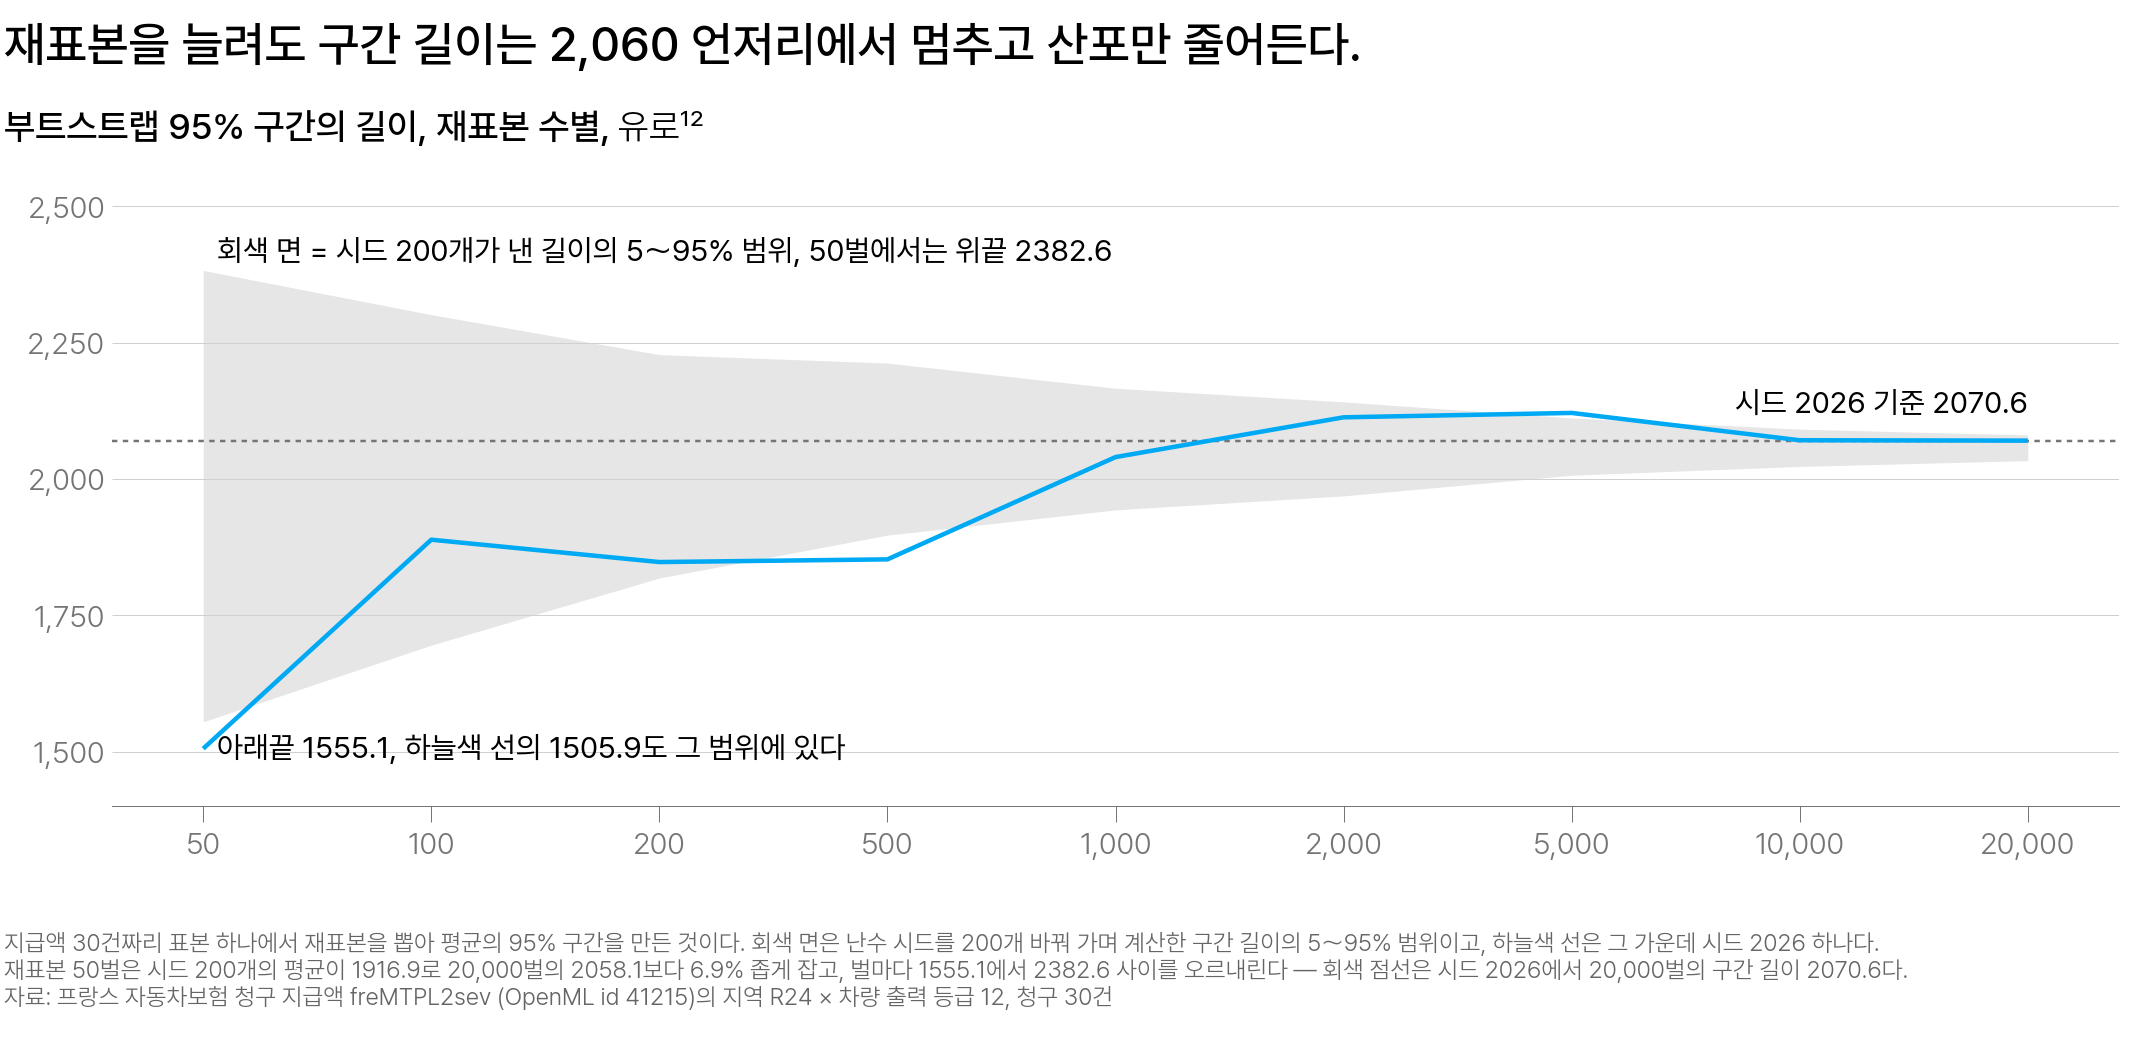

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 재표본 수 B 에 따른 부트스트랩 95% 구간 길이 — 난수 시드 200개가 낸 구간 길이의 5～95% 범위인 회색 면이 50벌의 1,555.1 ～ 2,382.6 에서 20,000벌의 2,033.9 ～ 2,080.9 로 좁아져, 재표본을 늘려 줄어드는 것은 구간 길이의 산포이지 길이 자체가 아니다.</em></p>

#### 결과 해석

예측 질문의 답은 **어느 값에서 멈춘다 — 더 늘려도 구간 길이는 그대로다** 입니다. 하늘색 선으로 표시한 시드 2026 의 결과만 확인해도 50벌의 1,505.9 에서 출발해 회색 점선 언저리에서 멈춥니다.

**첫째, 재표본이 너무 적으면 구간 길이가 반복마다 크게 변동하고 평균적으로도 좁게 계산됩니다** — 양 끝이 채워지지 않아 2.5%·97.5% 지점이 안쪽에 잡히기 때문입니다. $B = 50$ 에서 시드 200개가 낸 구간 길이는 아래끝 **1,555.1** 에서 위끝 **2,382.6** 사이(10회 중 9회가 그 범위 안)를 오르내리고, 그 평균 1,916.9는 20,000벌에서 시드 200개를 평균 낸 2,058.1보다 **6.9%** 좁습니다. 200벌에서는 1,818.7 ～ 2,228.3, 20,000벌에서는 2,033.9 ～ 2,080.9 로 좁아집니다. 그래서 실무에서는 $B$ 를 1,000 이상으로 잡습니다.

**둘째, 그 지점을 초과하면 $B$ 는 정밀도를 정하는 값이 아닙니다.** 20,000벌에서 구간 길이를 정하는 것은 재표본 수가 아니라 **원 표본 30개가 가진 정보량**입니다. 시드를 바꾸면 그 값도 2,033.9 에서 2,080.9 사이로 조금씩 달라지지만, 그것은 시드에 따른 변동일 뿐입니다.

「구간 길이」라는 이름에 이 절에서 숫자가 여럿 붙었으니 자리를 정리해 둡니다.

| 숫자 | 무엇을 측정했나 | 어디에 나오나 |
|---|---|---|
| **2,125.5** | 재표본 4,000벌·시드 2026 에서 실제로 계산한 구간 길이 | 앞 그림의 양끝 화살표 |
| 2,070.6 | 같은 시드 2026 에서 재표본을 20,000벌까지 늘렸을 때 | 위 그림의 **회색 점선**과 하늘색 선의 오른쪽 끝 |
| 2,058.1 | 20,000벌에서 시드 200개를 평균 낸 값 | 50벌의 1,916.9 와 비교하는 기준 |
| 2,033.9 ～ 2,080.9 | 20,000벌에서 시드 200개가 낸 길이의 5～95% 범위 | 위 그림 오른쪽 끝의 회색 면 |

위 그림 헤드라인의 「2,060 언저리」는 가운데 두 값 2,058.1 과 2,070.6 을 함께 뜻하는 어림입니다. 앞으로 **표준오차**라고 하면 548.6 을, **구간 길이**라고 하면 원 표본에서 실제로 계산한 **2,125.5** 하나를 뜻합니다.

표준오차와 구간 길이의 관계도 확인해 둡니다. 종 모양에 가까운 분포라면 95%가 대략 $\pm 2\,\text{SE}$ 안에 들어오니 구간 길이는 표준오차의 4배, 곧 $4 \times 548.56 = 2{,}194.2$ 여야 합니다. 실제로 나온 2,125.5 는 그보다 3% 좁은데, 평균의 분포가 오른쪽으로 비뚤어져 백분위로 자른 구간이 대칭 어림과 꼭 같지 않은 탓입니다.

##### 부트스트랩이 적용되지 않는 조건

**부트스트랩은 데이터를 늘려 주지 않습니다.** 가진 표본 안에서 통계량의 변동을 **재현**할 뿐이라, 원 표본이 모집단을 대표하지 못하면 구간에도 같은 편향이 그대로 남습니다. 최댓값처럼 극단값 하나에 좌우되는 통계량, 표본이 10건 안팎으로 아주 작은 경우에도 마찬가지로 맞지 않습니다.

**그래서** 많은 관측이 조금씩 기여하는 통계량(평균·중앙값·비율·회귀계수)과 계약 수가 많은 세그먼트가 부트스트랩이 잘 맞는 경우입니다.

<details class="lms-extra"><summary>자세히 — 최댓값 1건을 제외한 29건의 같은 계산 결과</summary>

지급액 30건에서 16,334 1건만 빠져 있었다면 같은 코드가 구간 길이를 **2,125.5에서 910.6으로 57% 좁게**, 중심을 **502.1유로 낮게** 산출합니다. 그런데 그 1건이 빠진 것을 확인할 방법이 없습니다 — 손에 있는 29개가 전부라고 보고 뽑기 때문입니다.

| | 30건 그대로 | 16,334 뺀 29건 |
|---|---|---|
| 평균 | 1,773.8유로 | 1,271.7유로 |
| 부트스트랩 표준오차 | 548.56유로 | 236.11유로 |
| 95% 구간 (길이) | 944.5 ～ 3,069.9 (2,125.5) | 865.0 ～ 1,775.5 (910.6) |

재표본의 최댓값은 언제나 16,334 이하입니다. 4,000벌을 뽑아도 그보다 큰 값은 나오지 않습니다(4,000벌의 63%에서 최댓값이 그대로 16,334였습니다). 그래서 최댓값·최솟값처럼 극단값 하나에 좌우되는 통계량에는 부트스트랩이 맞지 않습니다.

앞(1. 표준오차)에서 ± 2 SE 구간이 성립하지 않던 R21 × B11 세그먼트의 경우를 확인합니다. 계약 12건에 사고 2건이고, 그 2건이 서로 다른 계약에서 났으니 사고를 겪지 않은 계약이 10건입니다. 사고를 겪은 계약이 하나도 들어오지 않는 재표본은 12건이 그 10건에서만 뽑히는 경우이고, 그 확률이 $(10/12)^{12} = 0.11$, 재표본 9벌당 1벌의 비율입니다.

그런 재표본의 사고율은 0 이라 분포의 왼쪽 끝이 0 에 뭉치고, 2.5% 지점을 잘라도 그 값이 0 으로 잡힙니다. 원 표본에 든 서로 다른 값이 몇 개뿐이라, 재표본이 만들 수 있는 값의 종류도 너무 적습니다. 그 세그먼트는 앞(1. 표준오차)에서 카이제곱 분위수로 계산해 둔 **정확 포아송 구간** 0.04 ～ 1.09건/년을 사용하는 것이 적절합니다. 반대로 보면 계약 수가 많은 세그먼트에서는 공식이 없는 통계량까지 이 절차로 덮는다는 뜻입니다.

</details>

### [직접 해보기] 재표본 누적에 따른 부트스트랩 분포의 형성

위젯 위쪽 남색 점 30개는 표본 30개짜리 **별도의 예시**입니다 — 앞에서 다룬 지급액 30건이 아니라 부트스트랩 절차 자체를 보여 주려고 따로 둔 표본이라, 화면에 찍히는 `표본평균` 과 `공식 SE s/√30` 도 앞의 지급액 수치와는 다른 값입니다. 보는 것은 숫자가 아니라 절차입니다. 점은 30개 그대로이고, 이번 재표본에 뽑힌 점만 파랑으로 바뀌면서 뽑힌 횟수만큼 커집니다 — 새 점이 생기는 것이 아니라 같은 점의 상태가 바뀌어 색이 달라집니다.

1. **조작.** `리샘플 1번` 버튼을 20회 정도 눌러 `부트스트랩 SE` 값이 얼마나 크게 변동하는지 먼저 확인합니다. 그다음 `리샘플 100번` 으로 수백 개를 한꺼번에 누적합니다. `리셋` 을 누르면 비우고 처음부터 확인할 수 있습니다.
2. **관찰.** 파랑으로 커진 점은 이번 재표본에 여러 번 뽑힌 관측, 남색 그대로 흐려진 점은 1번도 뽑히지 않은 관측입니다. 아래쪽에 재표본 평균이 누적되어 히스토그램이 커지고 `부트스트랩 SE` 와 `공식 SE s/√30` 이 나란히 갱신됩니다.
3. **확인 질문.** 리샘플을 계속 누적하면 두 숫자가 가까워지는데, 두 값이 완전히 일치하겠습니까, 아니면 조금 못 미친 값에서 멈추겠습니까?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/boot-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 재표본을 누적할 때 두 표준오차가 수렴하는 값</summary>

가까워지긴 하는데, 완전히 일치하지는 않고 조금 낮은 값에서 수렴합니다. 20～30벌만 누적했을 때는 `부트스트랩 SE` 가 1번 누를 때마다 크게 변동합니다. 몇 백 벌로 가면 그 변동이 잦아들면서 `공식 SE s/√30` 바로 아래에서 안정됩니다.

수렴하는 값은 공식 값의 $\sqrt{29/30} = 0.983$ 배, 곧 공식보다 1.7% 아래입니다. 재표본을 30개짜리 원 표본에서 뽑는 한, 재표본 수를 아무리 늘려도 남는 차이입니다. 이 0.983 은 표본이 무엇이든 크기가 30이면 똑같이 붙으므로, 화면의 표본과 우리 지급액 30건에 모두 적용됩니다 — 결과 해석에서 우리 지급액 30건에 같은 계산을 적용해 얻은 값이 544.06 이었습니다.

값이 안정된 **뒤에도** 계속 눌러 봅니다. `부트스트랩 SE` 는 0 을 향해 내려가지 않습니다. 그렇게 수렴한 자리가 "표본 30개가 가진 정보량"이 정해 둔 변동성입니다.

</details>

#### 핵심 주의점

재표본 수 $B$ 를 표본 크기처럼 해석하면 안 됩니다.

$$
\text{SE}_{\text{boot}} = \text{sd}(\bar{x}^{*}_1, \dots, \bar{x}^{*}_B)
$$

- $\bar{x}^{*}_b$ : $b$ 번째 재표본의 평균

$B$ 는 이 표준오차를 얼마나 정밀하게 계산하는지만 결정하고, 그 값 자체는 원 표본 30건이 정합니다. 따라서 "재표본을 40만 벌로 늘리면 구간이 좁아진다" 는 틀린 문장입니다.

정확한 뜻은 다음과 같습니다.

> **지급액 30건에서 $B$ 를 20,000벌까지 늘려도 95% 구간 길이는 시드마다 2,033.9 ～ 2,080.9 안에서 멈추고, 그 자리를 정하는 것은 원 표본 30건이다.**

> 부트스트랩은 표본 하나를 모집단으로 간주하고 다시 뽑아, 공식이 없는 통계량에서도 표집분포의 **산포**를 근사해 얻습니다.

표본 하나로 표준오차를 계산하는 방법은 여기까지입니다. 지급액 30건이 준 것은 평균의 95% 구간 **944.5 ～ 3,069.9유로** 하나였습니다. 그 구간의 「95%」가 무엇을 뜻하는지는 3. 신뢰구간에서 확인합니다.

> **[문제] 표본 8건에서의 두 표준오차 차이**
>
> 코드 카드가 낸 부트스트랩 표준오차는 548.56유로, 공식 $s/\sqrt{30}$ 은 553.36유로였습니다. 결과 해석에서는 이 차이를 나누는 수 29 와 30 으로 설명했습니다. (1) 지급 청구가 30건이 아니라 **8건**만 모인 표본이었다면 부트스트랩 표준오차는 공식 표준오차의 몇 배가 되고, 그것은 공식보다 몇 % 아래인지 — 30건일 때 같은 계산이 예측한 1.7% 와 비교해 한 문장으로 적습니다. (2) 구간 길이 그림에서 $B = 50$ 지점의 회색 면(10벌 가운데 9벌이 드는 범위) 아래끝·위끝과 회색 점선이 위치한 20,000벌의 구간 길이를 읽어, 50벌짜리 보고가 구간 길이를 몇 % 놓치고 몇 % 부풀리는 경우인지 두 수를 적습니다 — 10벌 중 1벌은 이 범위 밖이라 차이가 더 커질 수 있습니다. 그 두 수를 (1)에서 구한 % 와 나란히 적고, 재표본 수 $B$ 를 40만으로 증가시켜 지울 수 있는 쪽이 어느 쪽인지 한 문장으로 판정합니다.

## 3. 신뢰구간 — 95%는 무엇에 대한 확률인가

## 신뢰구간의 정의 — 95% 가 적용되는 대상

**여기서 할 일**

1. 앞 절 구간 [944.5, 3,069.9] 의 "95%" 가 무엇에 부여된 값인지 정의합니다.
2. 참값을 아는 모의실험에서 구간을 4,000벌 만들어 **포획률**을 집계해 검산합니다.
3. 두 구간이 겹칠 때 "차이 없음" 이라 해도 되는지를 **차이의 구간**으로 판정합니다.

앞 절이 낸 944.5 ～ 3,069.9유로를 보고서에 옮겨 적으려면 어떤 문장으로 적을지부터 정해야 합니다. "참값이 이 안에 있을 확률이 95%" 라고 적고 싶어지는데, 그 문장은 쓸 수 없습니다.

**신뢰구간(confidence interval)** — 추정값 둘레로 벌려 둔 구간입니다. 같은 절차를 되풀이하면 그 구간들 가운데 신뢰수준만큼이 참값을 덮습니다.

> ❌ "참값이 이 안에 있을 확률이 95%다."  ⭕ "이 절차로 구간을 만들기를 반복하면 그중 95%가 참값을 덮는다."

참값도, 계산이 끝난 구간도 **고정된 숫자**라 확률을 부여할 대상이 없습니다. 우리 앞의 구간이 맞은 쪽인지는 알 수 없고, 20회 중 19회 적중하는 방법이라는 사실만 알 수 있습니다. 곧 **95%는 구간 하나가 아니라 구간을 만드는 절차에 부여된 적중률입니다.**

<details class="lms-extra"><summary>자세히 — 구간 산출 방식 2개(백분위·±z SE)와 검산에 ±z SE 를 쓰는 이유</summary>

구간을 만드는 방법은 하나가 아닙니다. 2가지를 이미 확보한 상태입니다.

⑴ **백분위 구간** — 앞(2. 부트스트랩)처럼 부트스트랩 분포를 크기순으로 정렬해 2.5% 지점과 97.5% 지점을 잘라 씁니다. 가운데 95%가 그 사이에 남습니다.

⑵ **$\pm z\,\text{SE}$ 구간** — 표집분포가 종 모양이라고 볼 수 있으면 앞(1. 표준오차)처럼 추정값 좌우로 표준오차의 몇 배씩을 벌립니다.

두 방식은 생김새가 다릅니다. 앞엣것은 데이터가 삐뚤어진 만큼 좌우 길이가 달라집니다. 앞(2. 부트스트랩)의 944.5 와 3,069.9 가 평균 1,773.8 에서 얼마나 떨어져 있는지 한 쪽씩 빼 봅니다. 먼저 왼쪽 길이를 뺄셈으로 구합니다.

$$
1{,}773.8 - 944.5 = 829.3
$$

같은 방식으로 오른쪽 길이도 뺄셈으로 구합니다.

$$
3{,}069.9 - 1{,}773.8 = 1{,}296.2
$$

오른쪽이 466.9 더 넓습니다 — 지급액 분포의 오른쪽 꼬리가 길기 때문입니다.

뒤엣것은 중심에서 좌우로 같은 값을 더하고 빼니 언제나 대칭입니다. 구간 길이도 $2z\,\text{SE}$ 하나로 끝납니다.

생김새는 이렇게 달라도 **노리는 성질은 하나**입니다 — 어느 쪽이든 "이 절차를 되풀이하면 95%가 참값을 덮는다" 를 목표로 만든 구간입니다.

그럼 그 성질이 지켜지는지 집계해 봐야 하는데, 그러려면 **참값을 정해 둔 모의실험**이 필요합니다. 참값을 모르면 덮었는지 아닌지 판정할 길이 없습니다. 구간을 수천 벌 만들려면 구간 1개를 만드는 계산 비용이 작을수록 유리합니다.

백분위 구간은 구간 1개마다 재표본을 수천 번 더 뽑아야 합니다 — 구간 4,000벌이면 재표본이 800만 번입니다. $\pm z\,\text{SE}$ 는 표본평균 하나와 표준오차 하나면 끝납니다. 그래서 아래 검산은 둘째 방식으로 합니다.

</details>

## 50% 신뢰구간 20개의 모의실험

> **[예측] 참값을 아는 모의실험에서 50% 신뢰구간을 20개 만들면, 그중 참값을 덮는 구간은 몇 개이겠습니까?**
>
> 1. 20개 전부 — 신뢰구간은 참값을 담도록 만든 구간이니까
> 2. 10개 안팎 — 절반쯤만 덮는다
> 3. 1개 — 나머지는 전부 빗나간다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

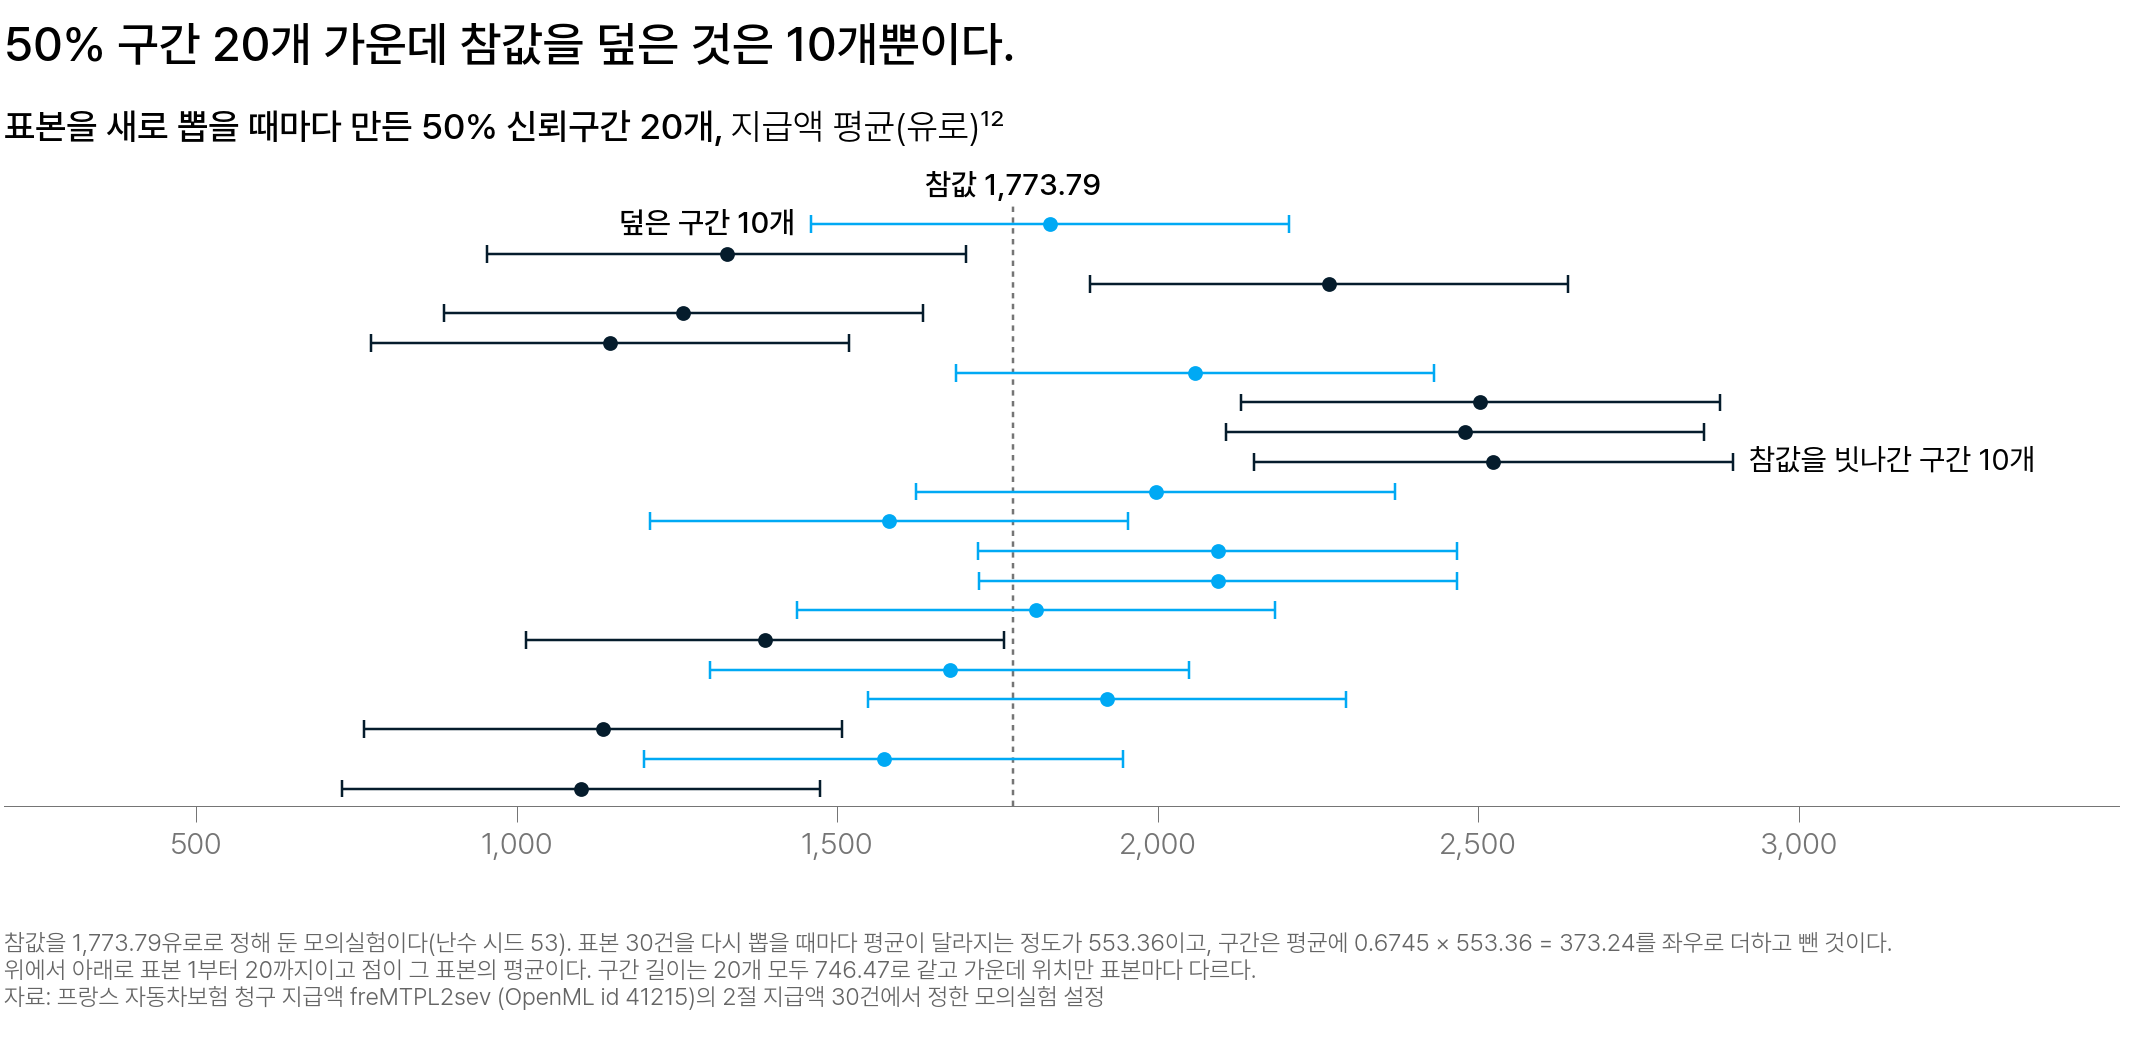

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 표본을 새로 뽑을 때마다 만든 50% 신뢰구간 20개 — 참값 1,773.79유로의 세로 점선을 하늘색 10개는 가로지르고 남색 10개는 빗나가, 20개 가운데 절반이 참값을 덮었다.</em></p>

예측 질문의 답은 `10개 안팎 — 절반쯤만 덮는다` 입니다.

그림은 요소 3개로 읽습니다.

- **회색 세로 점선** — 모의실험이 정해 둔 참값 1,773.79유로
- **하늘색 구간 10개** — 참값을 덮은 구간
- **남색 구간 10개** — 참값을 빗나간 구간

색 배정은 이어지는 위젯과 같습니다 — 덮은 쪽이 하늘색, 빗나간 쪽이 남색입니다.

가로로 배치된 구간 20개가 표본 30건을 새로 뽑을 때마다 만든 50% 신뢰구간이고, 가운데 점이 그 표본의 평균입니다. 절반쯤 빗나가는 것이 **50% 구간의 설계 사양**입니다 — 신뢰수준을 95%로 높이면 구간이 길어져 참값을 놓치는 경우가 20개 중 1개로 감소합니다. 50%가 뜻하는 것은 구간 하나가 아니라 이 절차를 되풀이했을 때의 적중률입니다.

구간 20개의 길이가 746.47유로로 모두 같은 것은 모의실험이 표준오차를 553.36유로로 정해 두었기 때문입니다. 길이는 $2z\,\text{SE}$ 이고 $z$ 와 $\text{SE}$ 가 20개 모두 같습니다. 표본마다 달라지는 것은 가운데 위치뿐이고, 덮었는지 빗나갔는지를 구분하는 것도 그 하나, 곧 표본평균이 참값에서 얼마나 멀리 떨어졌는가입니다.

구간의 길이를 정하는 것이 관측 하나하나의 산포가 아니라는 점도 같은 숫자에서 확인됩니다. 지급액 30건의 표준편차는 3,030.87유로인데 구간의 절반 길이는 373.24유로뿐입니다 — 구간이 측정하는 대상이 **평균의 산포**라, 관측 하나의 산포를 $\sqrt{30} = 5.48$ 로 나눈 553.36유로에 임계값 0.6745 를 곱한 값이기 때문입니다.

##### 포획률의 직접 집계

**포획률(coverage)** — 만든 구간 가운데 참값을 실제로 덮은 것의 비율입니다. 앞 그림이라면 20개 중 10개라 $10/20 = 0.50$ 입니다. 신뢰수준은 이 값이 그렇게 나오리라는 설계값이고, 아래 카드가 참값을 아는 모의실험에서 4,000번 되풀이해 검산합니다.

검산할 구간을 만드는 규칙부터 적어 둡니다. 앞(1. 표준오차)의 $\hat{\lambda} \pm 2\,\text{SE}$ 에, 좌우로 확장하는 배수를 선택해 대입하는 항을 하나 둔 형태입니다.

$$
\bar{x} \pm z\,\text{SE}, \qquad \text{SE} = \sigma/\sqrt{n}
$$

- $\bar{x}$ : 이번 표본의 평균 — 값이 바뀌면 구간 전체가 이동합니다
- $\sigma$ · $n$ : 관측 하나하나의 표준편차와 표본에 든 관측의 수 — 아래 카드와 이어지는 위젯은 참값과 $\sigma$ 를 아는 설정이라야 덮었는지를 셀 수 있어 같은 눈금(참값 50 · $\sigma = 10$ · $n = 25$)을 쓰고, 그래서 $\text{SE} = 10/\sqrt{25} = 2$ 입니다 — 지급액 30건과 척도만 다르고 계산 절차는 같습니다
- $z$ : **임계값(critical value)** — 표준오차의 몇 배만큼 좌우로 벌릴지 정하는 배수

구간의 **길이**는 위끝 빼기 아래끝, 곧 $2z\,\text{SE}$ — 표본이 그대로면 $z$ 에 정비례합니다.

$z$ 값은 신뢰수준이 정합니다. **임계값은 신뢰수준이 정하는 표준오차의 배수**이고, 표준정규분포에서 가운데를 그만큼 담으려면 좌우로 얼마씩 벌려야 하는지가 표로 떨어집니다.

| 신뢰수준 | 임계값 $z$ |
|---|---|
| 80% | 1.28 |
| 95% | 1.96 |
| 99% | 2.58 |

아래 카드 `for level, z in ...` 코드 행의 세 숫자가 이 표이고, 앞(1. 표준오차)에서 쓴 $\pm 2\,\text{SE}$ 는 95% 자리의 1.96 을 어림한 값입니다.

실제 데이터에서는 $\sigma$ 를 몰라 표본표준편차 $s$ 를 대신 쓰고, 그만큼 배수가 조금 커집니다.

<details class="lms-extra"><summary>더 깊이 — σ 를 모르면 배수가 1.96 에서 2.045 로 커지는 계산</summary>

$\sigma$ 자리에 $s$ 를 대입한 뒤 배수를 읽는 곳이 **t 분포(t-distribution)** 입니다. 표준정규와 같은 종 모양인데 꼬리가 조금 더 두꺼워서, 가운데 95%를 담으려면 1.96보다 더 벌려야 하는 분포입니다. 모르는 값을 하나 더 추정한 대가로 구간이 그만큼 넓어집니다.

얼마나 더 벌릴지는 **자유도(degrees of freedom)**, 곧 표본 크기에서 1을 뺀 수가 정합니다. 평균을 데이터에서 이미 1번 추정했으니 자유도가 $n - 1$ 만 남는다는 뜻입니다. 앞(2. 부트스트랩)에서 $s$ 를 만들 때 편차제곱합을 29 로 나눴던 그 29 와 같은 수입니다.

앞(2. 부트스트랩) 지급액 30건에 적용해 봅니다. 자유도가 $30 - 1 = 29$ 라 배수는 1.96 이 아니라 $t_{29} = 2.045$ 입니다. `scipy.stats.t.ppf(0.975, 29)` 가 2.0452 를 반환합니다. 앞(1. 표준오차)에서 정확 포아송 구간의 양끝을 `chi2.ppf` 로 확인했던 것과 같은 방식입니다.

구간의 절반 길이를 먼저 구합니다(곱하기).

$$
2.045 \times 553.36 = 1{,}131.6
$$

중심에서 좌우로 그만큼 벌립니다(더하기·빼기).

$$
1{,}773.79 - 1{,}131.6 = 642.2, \qquad 1{,}773.79 + 1{,}131.6 = 2{,}905.4
$$

곧 $[642.2,\ 2{,}905.4]$ 유로입니다. 앞(2. 부트스트랩)이 대칭 구간이라 적은 $[689.2,\ 2{,}858.4]$ 보다 양끝이 더 넓어진 값이고, 넓어진 정도는 좌우 같은 $(2.045 - 1.960) \times 553.36 = 47.0$ 유로씩입니다.

$n$ 이 커지면 $t$ 는 $z$ 로 수렴합니다. 같은 `scipy.stats.t.ppf` 에 자유도만 199 로 바꿔 대입하면 $t_{199} = 1.972$ 입니다. 999 로 대입하면 $t_{999} = 1.962$ 입니다. $n = 200$ 이면 1.96 과의 차이가 0.012 이고, $n = 1{,}000$ 이면 소수 셋째 자리에서야 달라집니다.

그래서 아래 카드처럼 $\sigma$ 를 아는 경우이거나 표본이 넉넉하면 $z$ 로 두고, 표본이 작고 $\sigma$ 를 모르면 $t$ 를 씁니다. 앞(2. 부트스트랩)이 그 자리에 1.96 을 곱해 둔 것도 이 $t_{29} = 2.045$ 를 어림한 값이라고 읽습니다 — 구간 길이 자체보다 좌우가 얼마나 비대칭인지를 비교하려던 맥락이라 익숙한 1.96 으로 적어 두었습니다.

</details>

In [ ]:
# 신뢰구간의 95%는 절차의 적중률이다 - 참값을 아는 모의실험에서 세어 보기
import numpy as np

mu, sigma, n = 50.0, 10.0, 25          # 참값 mu = 50 인 모의실험 (표준편차는 안다고 두자)
R = 4000                               # 표본을 4,000 번 새로 뽑는다
rng = np.random.default_rng(47)        # 시드 고정

samples = rng.normal(mu, sigma, size=(R, n))
means = samples.mean(axis=1)
se = sigma / np.sqrt(n)                # 표준오차 - 이 모의실험에서는 공식으로 안다

# z - 임계값: 표준정규에서 중앙 80/95/99% 를 포함하도록 좌우로 확장하는 표준오차 배수
for level, z in ((0.80, 1.281552), (0.95, 1.959964), (0.99, 2.575829)):
    lo, hi = means - z * se, means + z * se
    covered = np.mean((lo <= mu) & (mu <= hi))
    print(f"신뢰수준 {level:.0%} -> 포획률 {covered:.4f} · 평균 구간 길이 {np.mean(hi - lo):.2f}")

print()
print("처음 만든 구간 3개 (95%) :")
for m in means[:3]:
    print(f"  [{m - 1.959964 * se:.2f}, {m + 1.959964 * se:.2f}]  참값 50 포함? "
          f"{'예' if abs(m - mu) <= 1.959964 * se else '아니오'}")

#### 결과 해석

카드는 신뢰수준 80·95·99% 각각의 포획률과 평균 구간 길이를 1행씩 찍고, 그 아래에 95% 구간 4,000개 가운데 **처음 만든 3개**를 양끝 값 그대로 나열합니다.

- 포획률은 4,000벌 가운데 80% 구간이 **80.00%**, 95%가 **95.35%**, 99%가 **99.02%** — 선언한 신뢰수준과 거의 같습니다.
- 평균 구간 길이는 **5.13 · 7.84 · 10.30** 입니다. 구간 길이가 $2z\,\text{SE}$ 라 배수 1.28 · 1.96 · 2.58 에 그대로 비례합니다. **신뢰수준을 높인다는 것은 구간을 넓혀 적중률을 높이는 교환 관계입니다.**
- 나열한 그 3개는 셋 다 참값 50을 담았지만 우연입니다. 95% 구간 4,000개 중 **186개(4.65%)** 는 놓쳤고 겉모습은 나머지와 똑같습니다 — **빗나간 쪽인지는 보고 알 수 없습니다.**

### [직접 해보기] 포획률의 신뢰수준 수렴 과정

1. **조작.** `표본 뽑기` 를 눌러 구간을 하나씩 누적합니다. 20개가 찬 뒤 1번 더 누르거나 `처음으로` 를 누르면, 또 `표본 크기 n` (25～60)·`신뢰수준` (80～99%) 슬라이더를 옮기면 기본값인 18개로 돌아갑니다.
2. **관찰.** 회색 세로 점선이 참값 $\mu = 50$ 이고, 덮은 구간은 하늘색·놓친 구간은 남색입니다. 화면에 표시되는 값은 3개입니다.
   - `화면의 구간` — 누적된 것의 `덮음 / 전체`
   - `400벌 반복 포획률` — 같은 설정으로 400벌을 실행한 결과이고, 절차의 적중률에 해당하는 숫자가 이것입니다
   - `구간 길이` — `2 × 임계값 × 표준오차`
3. **확인 질문.** 신뢰수준을 그대로 둔 채 표본 크기 $n$ 만 키우면 포획률과 구간의 길이 중 무엇이 달라지겠습니까?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/ci-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — n 을 25 에서 60 으로 변경할 때 달라지는 것: 포획률과 구간 길이</summary>

**길이만** 달라집니다 — 그것도 리드아웃이 얼마나 안 움직이는지로 확인하는 편이 빠릅니다. `표본 크기 n` 을 옮기면 누적된 구간이 18개로 초기화되므로, `신뢰수준` 을 95%에 둔 채 25 에서 60 까지 이동시킵니다. `구간 길이` 만 7.84 에서 5.06 으로 짧아지고, `화면의 구간` 은 17 / 18, `400벌 반복 포획률` 은 95.5% 에서 **변하지 않습니다.** 이 95.5% 가 앞 카드의 95.35% 와 소수점 아래에서 다른 것은 집계 횟수가 달라서입니다 — 카드는 4,000벌, 위젯은 400벌로 집계합니다.

덮었는지는 그 표본평균이 참값에서 몇 표준오차 떨어졌는지로 결정됩니다. $n$ 을 키우면 표본평균이 참값에 가까워지는 속도와 표준오차 $\sigma/\sqrt{n}$ 이 줄어드는 속도가 같아서 둘을 나눈 비율은 $n$ 이 얼마든 같은 분포를 이룹니다. 그래서 색이 구분되는 비율도 그대로입니다.

"데이터를 더 모으면 더 자주 맞힌다"가 아니라 "같은 적중률을 더 좁은 구간으로 달성한다"가 화면에 그대로 표시되어 있습니다.

`신뢰수준` 을 80%로 내리면 임계값이 1.96 에서 1.28 로 줄어 구간이 짧아집니다. 대신 `400벌 반복 포획률` 이 95.5% 에서 81.0% 로 내려가고 남색(놓친 구간)이 늘어납니다.

</details>

## 구간의 겹침과 유의성 — 차이의 구간으로 하는 판정

두 세그먼트의 사고율 구간을 나란히 그려 두고 "겹치니 차이가 없다"고 결론 내리는 장면이 회의실에서 자주 나옵니다. **겹침과 유의성은 다른 질문입니다.**

**유의하다(statistically significant)** — 차이가 크다는 말이 아니라 차이의 구간이 0 을 포함하지 않는다는 뜻입니다. 0 을 포함하면 차이가 없다는 증명이 아니라 **아직 어느 쪽인지 정할 수 없다** 는 뜻입니다.

겹침을 판정 기준으로 삼으면 오독이 2가지 따라오는데, 둘은 층이 다릅니다.

1. **판정 도구를 잘못 고른 오독** — 두 구간이 겹친다는 관찰만 보고 "차이 없음" 으로 결론짓는 것입니다. 겹치는데도 차이의 구간이 0 을 넘지 않는 경우가 있어서, **있는 차이를 없다고 보고하게** 됩니다. 고칠 자리는 도구입니다 — 각자의 구간 대신 차이의 구간을 봅니다.
2. **도구는 맞는데 결과를 잘못 읽은 오독** — 차이의 구간을 제대로 만들고도 그 구간이 0 을 가로지르는 것을 "차이가 0 이다" 로 읽는 것입니다. 여기서 할 말은 "차이가 없다" 가 아니라 **"이 데이터로는 못 정한다, 더 모아야 한다"** 입니다.

판단의 대상은 각자의 구간이 아니라 **차이의 구간** 입니다. 바로 아래에서 우리 두 세그먼트로 그 두 패널을 그려 봅니다.

이유는 다음 계산에 있습니다. 두 집단이 독립이면 차이의 표준오차는 합이 아니라 **제곱합의 제곱근**입니다.

$$
\text{SE}(\hat{\theta}_{\text{세그}} - \hat{\theta}_{\text{전체}}) = \sqrt{\text{SE}_{\text{전체}}^2 + \text{SE}_{\text{세그}}^2}
$$

- $\hat{\theta}_{\text{전체}}$ : 전체의 사고율 추정값 — 0.1006
- $\hat{\theta}_{\text{세그}}$ : 세그먼트 R21 × B11 의 사고율 추정값 — 0.3021
- $\text{SE}_{\text{전체}}$, $\text{SE}_{\text{세그}}$ : 그 각각의 표준오차 — 0.00053 과 0.2136
- 왼쪽 $\text{SE}(\hat{\theta}_{\text{세그}} - \hat{\theta}_{\text{전체}})$ : 차이의 산포
- 첨자를 「전체·세그」로 쓴 것은 이 절이 비교하는 대상이 그 둘이기 때문입니다. $A$·$B$ 는 뒤(4. 신뢰구간을 이용한 의사결정)에서 지역 R43·R42 에만 씁니다

**앞(1. 표준오차)의 두 세그먼트를 대입해 봅니다.** 차이는 $0.3021 - 0.1006 = 0.2015$ 입니다. 차이의 표준오차는 $\sqrt{0.00053^2 + 0.2136^2} = 0.2136$ 입니다.

같은 어림 배수 2 를 적용한 $0.2015 \pm 2 \times 0.2136$ 이 차이의 구간 $[-0.226,\ 0.629]$ 입니다. **그래서** 이 세그먼트의 구간은 0 을 충분히 포함하는 쪽, 곧 판단을 유보하는 쪽입니다 — 사고 2건으로 계산한 숫자이기 때문입니다.

<details class="lms-extra"><summary>자세히 — 차이의 표준오차 계산과 ±2 SE 를 그대로 사용하는 이유</summary>

**합이 아닌 이유부터 적습니다.** 두 값이 서로 상관없이 따로 변동한다면 변동의 크기(분산)는 그대로 더해지지만, 그 제곱근인 표준오차까지 더해지지는 않습니다.

더해지는 것은 표준오차가 아니라 분산입니다. 두 추정값이 서로 독립이면 차이의 분산은 각 분산의 합이고, 빼기여도 분산은 더해집니다. 이것이 분산 더하기입니다.

$$
\operatorname{Var}(\hat{\theta}_{\text{세그}} - \hat{\theta}_{\text{전체}}) = \text{SE}_{\text{세그}}^2 + \text{SE}_{\text{전체}}^2
$$

표준오차는 그 분산의 제곱근이므로, 양변에 제곱근을 씌우면 본문의 $\sqrt{\text{SE}_{\text{세그}}^2 + \text{SE}_{\text{전체}}^2}$ 가 됩니다. 표준오차끼리 그냥 더하면 제곱근을 씌운 뒤의 값을 더한 셈이라 참값보다 늘 큽니다. 얼마나 큰지는 아래 두 경우에서 숫자로 확인합니다.

전체가 0.1006 · 표준오차 0.00053, R21 × B11 이 0.3021 · 표준오차 0.2136 입니다. 구간은 앞(1. 표준오차)과 같이 $\pm 2 \times$ 표준오차로 만듭니다.

- **각 세그먼트의 구간** — R21 × B11 이 $[-0.125,\ 0.729]$ 라, 전체의 $[0.0996,\ 0.1017]$ 을 통째로 포함합니다.
- **차이의 표준오차** — $\sqrt{0.2136^2 + 0.00053^2} = 0.2136$. 작은 쪽은 제곱한 뒤에는 무시할 수준이 됩니다.
- **차이의 구간** — 차이가 $0.3021 - 0.1006 = 0.2015$ 이니 $0.2015 \pm 2 \times 0.2136 = [-0.226,\ 0.629]$.

먼저 두 표준오차가 **같은 크기**일 때를 봅니다. 둘 다 1이라면 식에 대입해 $\sqrt{1^2 + 1^2} = \sqrt{2} = 1.41$ 입니다. 그냥 더한 2 가 아닙니다. 각 구간의 겹침을 보는 것은 이 2 로 판단하는 것이라, 실제보다 약 40% 넓은 구간으로 판정하는 지나치게 보수적인 방법이 됩니다.

이제 우리 숫자로 갑니다 — **한쪽이 다른 쪽보다 훨씬 큰** 경우입니다. 한 단계씩 밟아 봅니다.

⑴ 각 항을 제곱합니다.

$$
0.2136^2 = 0.04562496, \qquad 0.00053^2 = 0.0000002809
$$

뒤엣것은 소수점 아래 일곱째 자리에서야 0 이 아닌 숫자가 나옵니다.

⑵ 두 값을 더합니다.

$$
0.04562496 + 0.0000002809 = 0.0456252409
$$

앞의 소수점 아래 5자리 0.045624 는 전혀 변하지 않았습니다.

⑶ 제곱근을 씌웁니다.

$$
\sqrt{0.0456252409} = 0.2136
$$

큰 쪽과 작은 쪽의 비가 $0.2136 / 0.00053 \approx 403$ 배인데, **제곱하면 그 비가 다시 제곱되어 약 16만 배**가 됩니다. 그래서 더할 때 작은 쪽이 사실상 사라집니다.

그래서 달라지는 점은 다음과 같습니다 — 두 표준오차 가운데 한쪽이 다른 쪽의 서너 배만 되어도 **차이의 표준오차 $\text{SE}(\hat{\theta}_{\text{세그}} - \hat{\theta}_{\text{전체}})$ 는 큰 쪽이 혼자 정합니다.** 전체 쪽 데이터를 아무리 더 모아도 차이의 구간은 좁아지지 않고, 좁히려면 R21 × B11 세그먼트의 사고 2건을 늘리는 방법밖에 없습니다.

**이 시연이 쓰는 구간은 앞(1. 표준오차)의 $\pm 2\,\text{SE}$ 입니다.** 대칭 구간은 겹침 시연에만 쓰고, 그 세그먼트의 구간을 제대로 구하는 일은 앞(1. 표준오차)의 0.04 ～ 1.09건/년이 이미 했습니다. 임계값도 앞(1. 표준오차)과 같은 어림값 2 를 사용합니다 — 실행 카드에서 쓴 1.96 을 대입하면 아래끝이 $-0.117$ 로 나와 앞(1. 표준오차)에 적은 $-0.125$ 와 다른 구간처럼 보이기 때문입니다. 또한 이 세그먼트만 따로 보면 0.04 ～ 1.09 의 아래끝이 0 보다 커서 "사고율이 0 은 아니다" 쪽으로 읽히는데 지금 묻는 것은 **전체와 다르냐** 입니다. 두 질문의 답이 달라질 수 있다는 것도 겹침 대신 차이를 봐야 하는 이유 가운데 하나입니다.

</details>

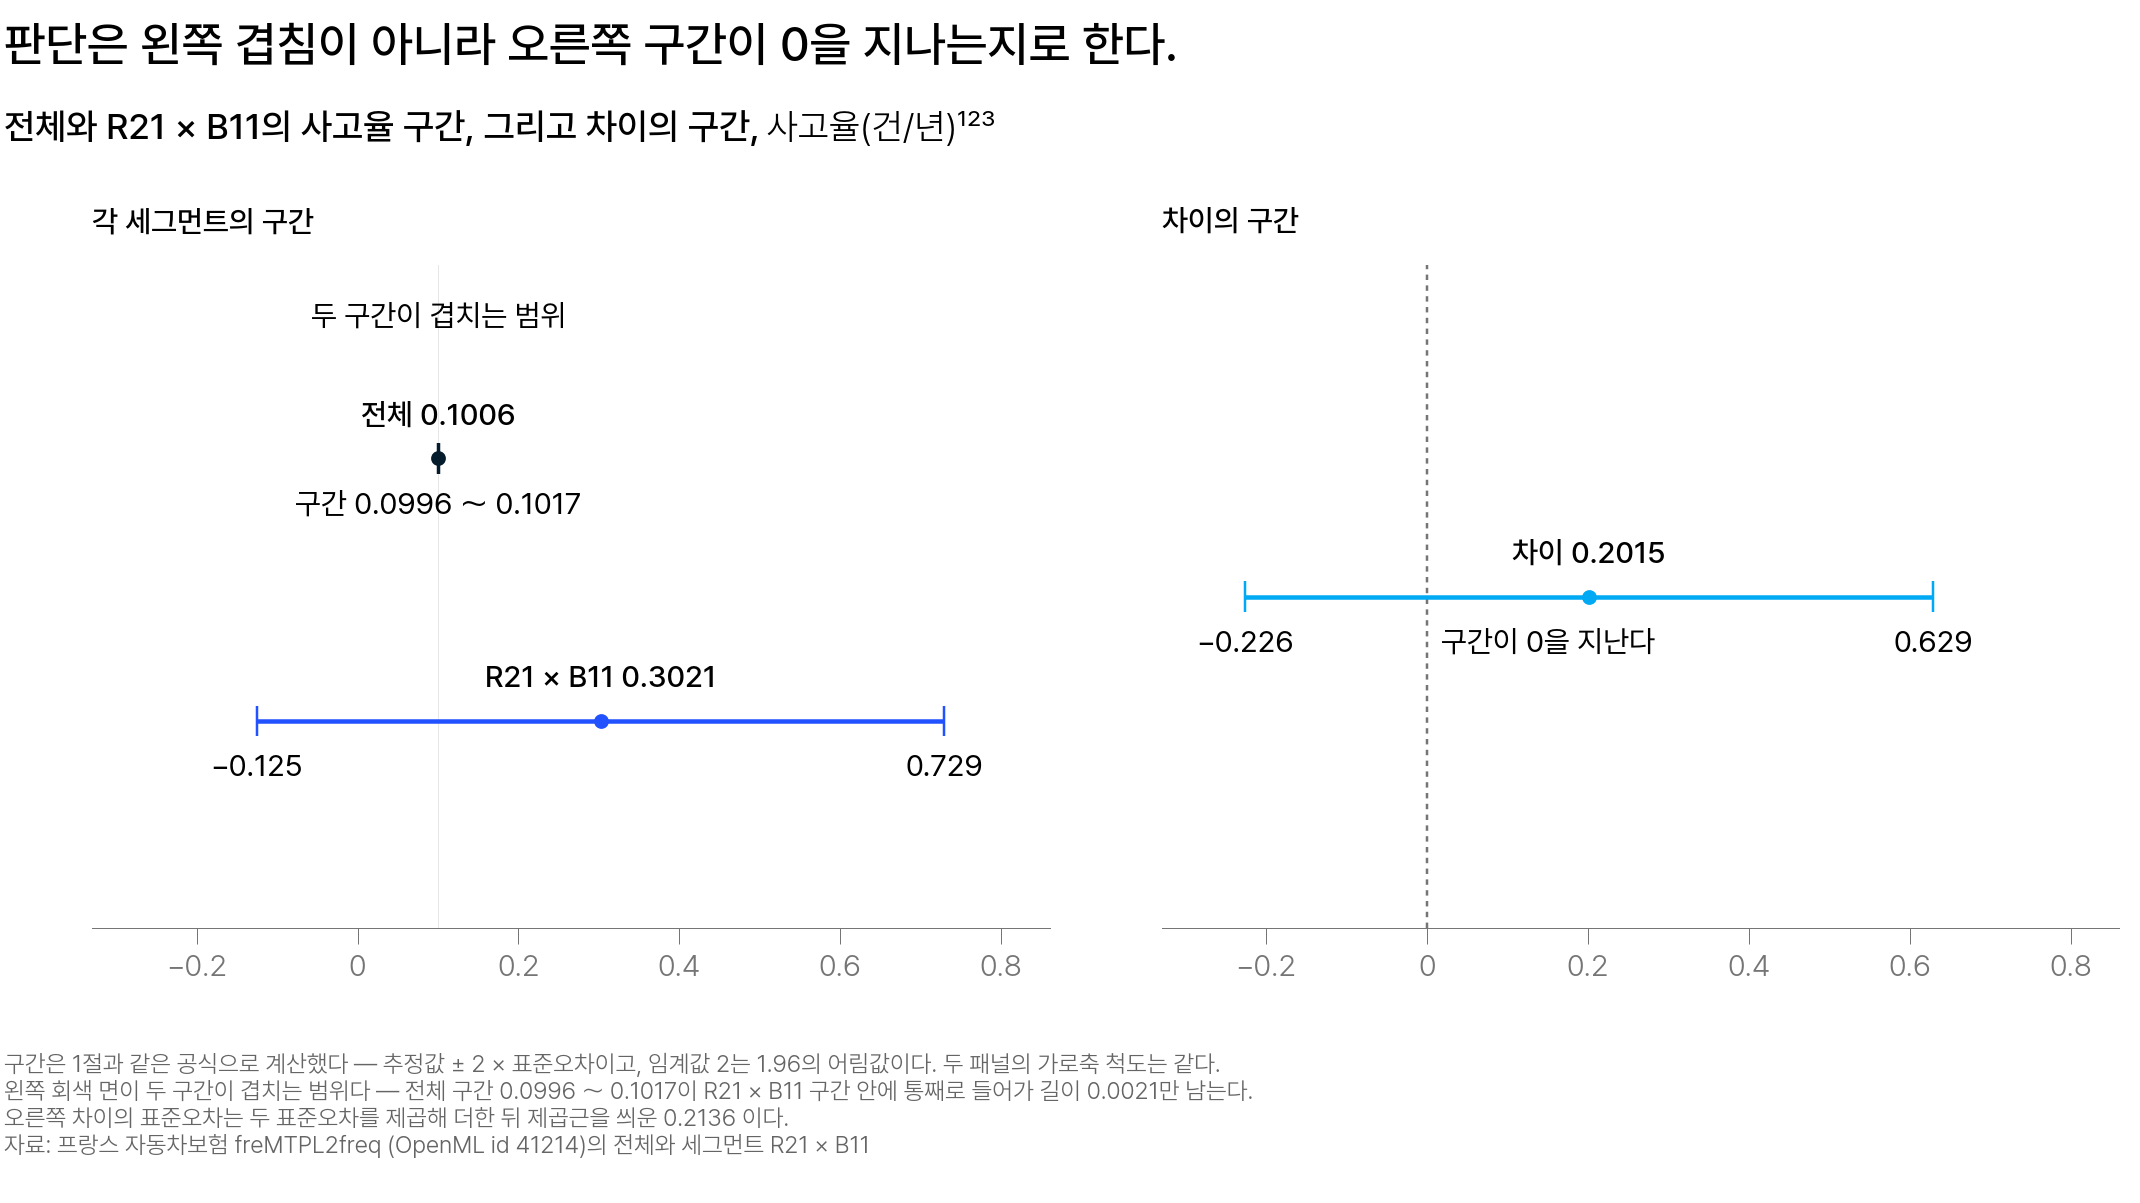

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 전체와 R21 × B11 의 사고율 구간(왼쪽)과 차이의 구간(오른쪽) — 왼쪽에서 두 구간이 겹치지만 오른쪽 차이 구간 −0.226 ～ 0.629 가 회색 세로 점선으로 그은 0 을 가로지르므로, 이 세그먼트는 판단을 유보한다.</em></p>

그림의 요소 4개는 다음과 같이 읽습니다.

- **남색 점** — 전체의 구간 0.0996 ～ 0.1017. 구간 길이가 0.0021 이라 이 척도에서는 점 하나로 보입니다
- **파랑 선분** — R21 × B11 의 구간 −0.125 ～ 0.729
- **회색 세로 구역** — 두 구간이 겹치는 범위
- **하늘색 점** — 차이 0.2015

겹침이 생긴 이유는 두 세그먼트가 비슷해서가 아닙니다. 사고 2건짜리 세그먼트에 **좌우로 똑같이 벌리는 방식이 맞지 않아** 한쪽 구간이 통제 없이 길어진 탓입니다 — 구간 길이가 0.0021 과 0.855 로 크게 달랐습니다.

**규칙 하나.** 두 값을 비교하려면 각 값의 구간이 아니라 **차이의 구간**을 만들어 0을 포함하는지 봅니다. 부트스트랩이라면 재표본마다 두 통계량의 차이를 저장해 백분위 구간을 만듭니다.

#### 핵심 주의점

두 구간이 겹친다는 관찰을 "차이가 없다" 로 해석하면 안 됩니다.

$$
\text{SE}(\hat{\theta}_{\text{세그}} - \hat{\theta}_{\text{전체}}) = \sqrt{\text{SE}_{\text{전체}}^2 + \text{SE}_{\text{세그}}^2}
$$

차이의 산포는 두 표준오차의 합이 아니라 제곱합의 제곱근이라, 겹침으로 판정하는 것은 두 표준오차를 단순 합산한 넓은 구간을 쓰는 것과 같습니다. 따라서 "두 세그먼트의 구간이 겹치니 사고율이 같다" 는 틀린 문장입니다.

정확한 뜻은 다음과 같습니다.

> **전체와 R21 × B11 의 구간이 겹친 것은 두 세그먼트가 비슷해서가 아니라 좌우로 똑같이 벌리는 방식이 맞지 않아 한쪽 구간 길이가 0.855 까지 길어져서이고, 판정은 차이의 구간 $-0.226$ ～ $+0.629$ 가 0 을 지나므로 유보다.**

> 95%는 구간 하나가 아니라 구간을 만드는 절차의 적중률이고, 두 값을 비교할 때 확인할 것은 각각의 구간이 아니라 차이의 구간입니다.

다음 절에서는 **대상을 계약 수가 넉넉한 지역 2곳(R43·R42)으로 바꿉니다.** 사고 2건짜리 세그먼트는 방향조차 정할 수 없어 결정까지 끌고 갈 수 없기 때문입니다. 그렇게 바꾼 대상에서 같은 방식으로 만든 구간을 근거로, 두 지역에 다른 요율을 적용할지 결정합니다.

> **[문제] 실행 카드에서 신뢰수준을 95%에서 99%로 높이면 놓친 구간은 186개에서 39개로 줄고, 그 대가로 평균 구간 길이는 95%의 2배가 된다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 4. 신뢰구간을 이용한 의사결정

## 확률 하나만으로 결정할 수 없는 이유

**여기서 할 일**

1. 구간 하나에 확률을 직접 부여할 수 있는 **신용구간**을 구해, 앞 절 신뢰구간과 해석 문장이 어떻게 달라지는지 대조합니다.
2. **기대손실**과 **ROPE** 로 "차이가 있다/없다"를 넘어 요율표 개정 여부까지 판정합니다.
3. 중간에 자꾸 들여다보는 습관이 결론을 어떻게 바꾸는지 측정하고, 보고에 사용할 문장을 정합니다.

둘째 날 마지막에 비교했던 두 지역 — 계약 1,326건 중 54건이 사고를 겪은 **R43**($\theta_A$), 2,200건 중 124건이 겪은 **R42**($\theta_B$) — 를 다시 다룹니다. 이 절의 $\theta$ 는 계약 한 건이 기간 안에 사고를 1번이라도 겪을 비율입니다. 사고율에는 계속 $\lambda$ 를 씁니다.

사고 경험 비율로는 R43 이 $54 / 1{,}326 = 4.072\%$, R42 가 $124 / 2{,}200 = 5.636\%$ 라 차이가 $+0.0156$ 입니다. 균등 사전분포 $\text{Beta}(1, 1)$ 에 이항 관측을 더하면 사후분포가 $\text{Beta}(1 + k,\ 1 + n - k)$ 로 떨어진다는 둘째 날의 켤레 계산을 그대로 쓰면, R43 은 $\text{Beta}(55,\ 1273)$ 이고 R42 는 $\text{Beta}(125,\ 2077)$ 입니다. A·B 는 두 지역을 나타내는 첨자일 뿐이고, 실습에서 만나는 도시화 등급 `Area`(A～F)와는 관계가 없습니다.

<details class="lms-extra"><summary>자세히 — 둘째 날의 사전분포·사후분포·켤레 Beta 다시 확인하기</summary>

데이터를 보기 전의 믿음과 데이터가 준 증거를 합치면 새 믿음이 되는데, 이항 관측에서는 그 합치는 계산이 특히 깔끔하게 정리됩니다. 아래 세 낱말이 그 계산의 이름입니다.

- **사전분포(prior)** — 데이터를 보기 전에 모수에 부여해 둔 분포입니다. $\text{Beta}(1, 1)$ 은 0 과 1 사이를 고르게 보는 균등 사전분포라, 어느 비율도 미리 더 그럴듯하다고 두지 않습니다.
- **사후분포(posterior)** — 그 사전분포에 관측을 반영해 갱신한 분포이고, 오늘의 신용구간과 사후확률은 전부 여기서 잘라 낸 값입니다.
- **켤레(conjugate)** — 사전분포와 사후분포가 같은 분포족에 머무는 짝입니다. Beta 사전분포에 이항 관측을 더하면 사후분포도 Beta 라, 적분 없이 모수 2개만 고쳐 쓰면 끝납니다.

검산 — R43 은 $n = 1{,}326$ 에 $k = 54$ 이니 $\text{Beta}(1 + 54,\ 1 + 1{,}326 - 54) = \text{Beta}(55,\ 1273)$ 이고, 본문에 적은 것과 같습니다.

</details>

> **"그래서 두 지역에 다른 요율을 적용해야 합니까?"**

거기서 얻은 $P(\theta_B > \theta_A) = 0.980$ 은 **방향**에 부여된 확률입니다. R42 가 더 높다는 것까지는 말하지만 "얼마나 높은가"도 "요율표를 바꿀 만한가"도 말해 주지 않습니다.

## 신뢰구간과 신용구간 — 같은 길이, 다른 문장

- **신용구간(credible interval)** — 사후분포에서 잘라 낸 구간입니다.
  - **직관**: 베이즈 추정은 데이터를 고정된 사실로 두고 모수에 분포를 부여합니다. 모수 자체가 분포를 가지니 "참값이 여기 있을 확률 95%"가 문장 그대로 성립합니다.
  - **예시**: 두 지역 차이 $\theta_B - \theta_A$ 의 95% 신용구간 **+0.0007 ～ +0.0296**.

| | 신뢰구간 | 신용구간 |
|---|---|---|
| 변하는 대상 | 구간 (데이터가 바뀌면 구간이 바뀐다) | 모수 (사후분포를 따른다) |
| 95%가 적용되는 곳 | 절차의 적중률 | 이 구간 안에 참값이 있을 확률 |
| 만드는 분포 | 표집분포 또는 부트스트랩 분포 | 사후분포 |
| 사전지식 | 반영할 항이 없다 | 사전분포로 명시한다 |
| 이 데이터에서 | +0.0005 ～ +0.0306 (길이 0.0301) | +0.0007 ～ +0.0296 (길이 0.0289) |

표 마지막 행의 두 구간은 이 절 뒤쪽 실행 카드가 직접 만들어 낼 값을 미리 옮겨 적었습니다.

**그래서** 두 구간 길이는 0.0301 과 0.0289 로 **4% 남짓 서로 다를 뿐**입니다 — 숫자가 거의 같은데 **읽는 문장만 다른** 경우입니다. (앞 절에서 「겹친다」는 두 구간이 가로축의 같은 범위를 공유한다는 뜻으로 썼습니다. 여기서 비교하는 것은 길이 2개라 그 말을 쓰지 않습니다.) 두 구간은 표집분포와 사후분포라는 서로 다른 분포에서 만들어지므로, 길이가 비슷해도 해석 문장이 다릅니다. 숫자가 같다고 문장까지 바꿔 쓰면 그때부터 틀린 보고가 됩니다.

사후분포에서 95%를 담는 자르기는 둘입니다. 양끝을 2.5%씩 떼는 **등꼬리(equal-tailed)** 구간과, 밀도가 높은 값부터 담아 95%를 채우는 **최고사후밀도(HPD, highest posterior density)** 구간입니다. 우리 두 지역 차이의 사후분포는 거의 좌우대칭이라 두 자르기가 같은 위치에 나타납니다. 두 방식을 구분한 그림 2장은 아래 「자세히」에 정리했습니다.

<details class="lms-extra"><summary>자세히 — 같은 95% 를 담는 구간 산출 방식 2가지: HPD 와 등꼬리</summary>

사후분포에서 95%를 담는 구간은 하나가 아닙니다. 자르는 방식이 둘로 갈립니다. 아래 두 그림은 원 출처를 따라 90%로 그려졌지만, 자르는 방식의 차이는 95%에서도 똑같습니다 — 담는 넓이만 90에서 95로 바뀝니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Highest_posterior_density_interval.svg" width="640" height="293"/>
<p align="center"><em>▲ 최고사후밀도(HPD) 구간 — 가로축(Value of the parameter)이 모수 값, 세로축(Probability density)이 확률밀도다. 밀도가 높은 값부터 담아 90%를 채운다. 가로 점선 높이에서 자르고 나니 남은 꼬리가 왼쪽 2%, 오른쪽 8%로 나뉘었다. 같은 높이에서 자르는 방식이라 꼬리가 긴 오른쪽이 더 많이 잘려 나간다. (출처: Wikipedia, "Credible interval")</em></p>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Equal-tailed_credibility_interval.svg" width="640" height="293"/>
<p align="center"><em>▲ 등꼬리 구간 — 가로축·세로축은 위 그림과 같다(가로 = 모수 값, 세로 = 확률밀도). 같은 사후분포를 양쪽 5%씩 잘랐다. 담은 넓이는 위 그림과 똑같은 90%인데 구간이 오른쪽으로 이동한다. 같은 90%라도 자르는 방식이 달라지면 보고할 범위가 달라진다. (출처: Wikipedia, "Credible interval")</em></p>

**HPD 구간**은 "밀도가 높은 값부터 담다가 90%가 차면 멈춘다"는 방식입니다. 그림 안 **가로 점선**이 그 멈춘 높이입니다 — 왼쪽 경계와 오른쪽 경계에서 밀도가 정확히 같아지는 지점에서 자른 것입니다. 그래서 구간 안의 어느 점도 밖의 어느 점보다 밀도가 높고, **같은 90%를 담는 모든 구간 중 길이가 가장 짧다**는 성질이 따라옵니다. 그 대가로 잘려 나간 양쪽 꼬리의 넓이가 2%와 8%로 서로 달라집니다.

**등꼬리 구간**은 양쪽을 똑같이 자르는 방식이고, 앞 절의 부트스트랩 백분위 구간이 여기 속합니다. 분포가 좌우대칭이면 둘이 거의 같아지지만, 사후분포의 최빈값이 0 부근에 있으면 두 구간이 달라집니다(사고가 1건도 없는 세그먼트가 그렇습니다).

등꼬리 구간은 왼쪽에서 항상 같은 비율을 제외합니다. 95% 구간이면 2.5%, 그림처럼 90% 구간이면 5%입니다.

그래서 최빈값이 0에 있어도 하한이 0 오른쪽에 생깁니다. 반면 HPD는 밀도가 가장 높은 0 쪽부터 담으므로 0이 구간 안으로 들어옵니다. 실무 기본값은 등꼬리이고, 경계가 0에 근접하면 HPD를 함께 확인합니다.

</details>

## 기대손실 — 확률과 차이 크기의 곱

- **기대손실(expected loss)** — 잘못 골랐을 때의 차이 크기를 그 일이 일어날 사후확률로 가중해 더한 값입니다.
  - **직관**: 차이가 0.001인데 틀리는 것과 0.03이나 차이 나는데 틀리는 것은 값이 다릅니다. 틀릴 확률에 크기까지 곱해 평균을 냅니다.
  - **기호**: $\mathbb{E}[\text{loss} \mid B \text{ 선택}]$ 라 적습니다.

> **[예측] B를 골랐다가 틀렸을 때의 기대손실과, 반대로 A를 골랐다가 틀렸을 때의 기대손실은 얼마나 차이가 나겠습니까?**
>
> 1. 두 배쯤 — 확률이 0.98과 0.02로 갈리니 그만큼
> 2. 수십 배쯤
> 3. 수백 배쯤
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

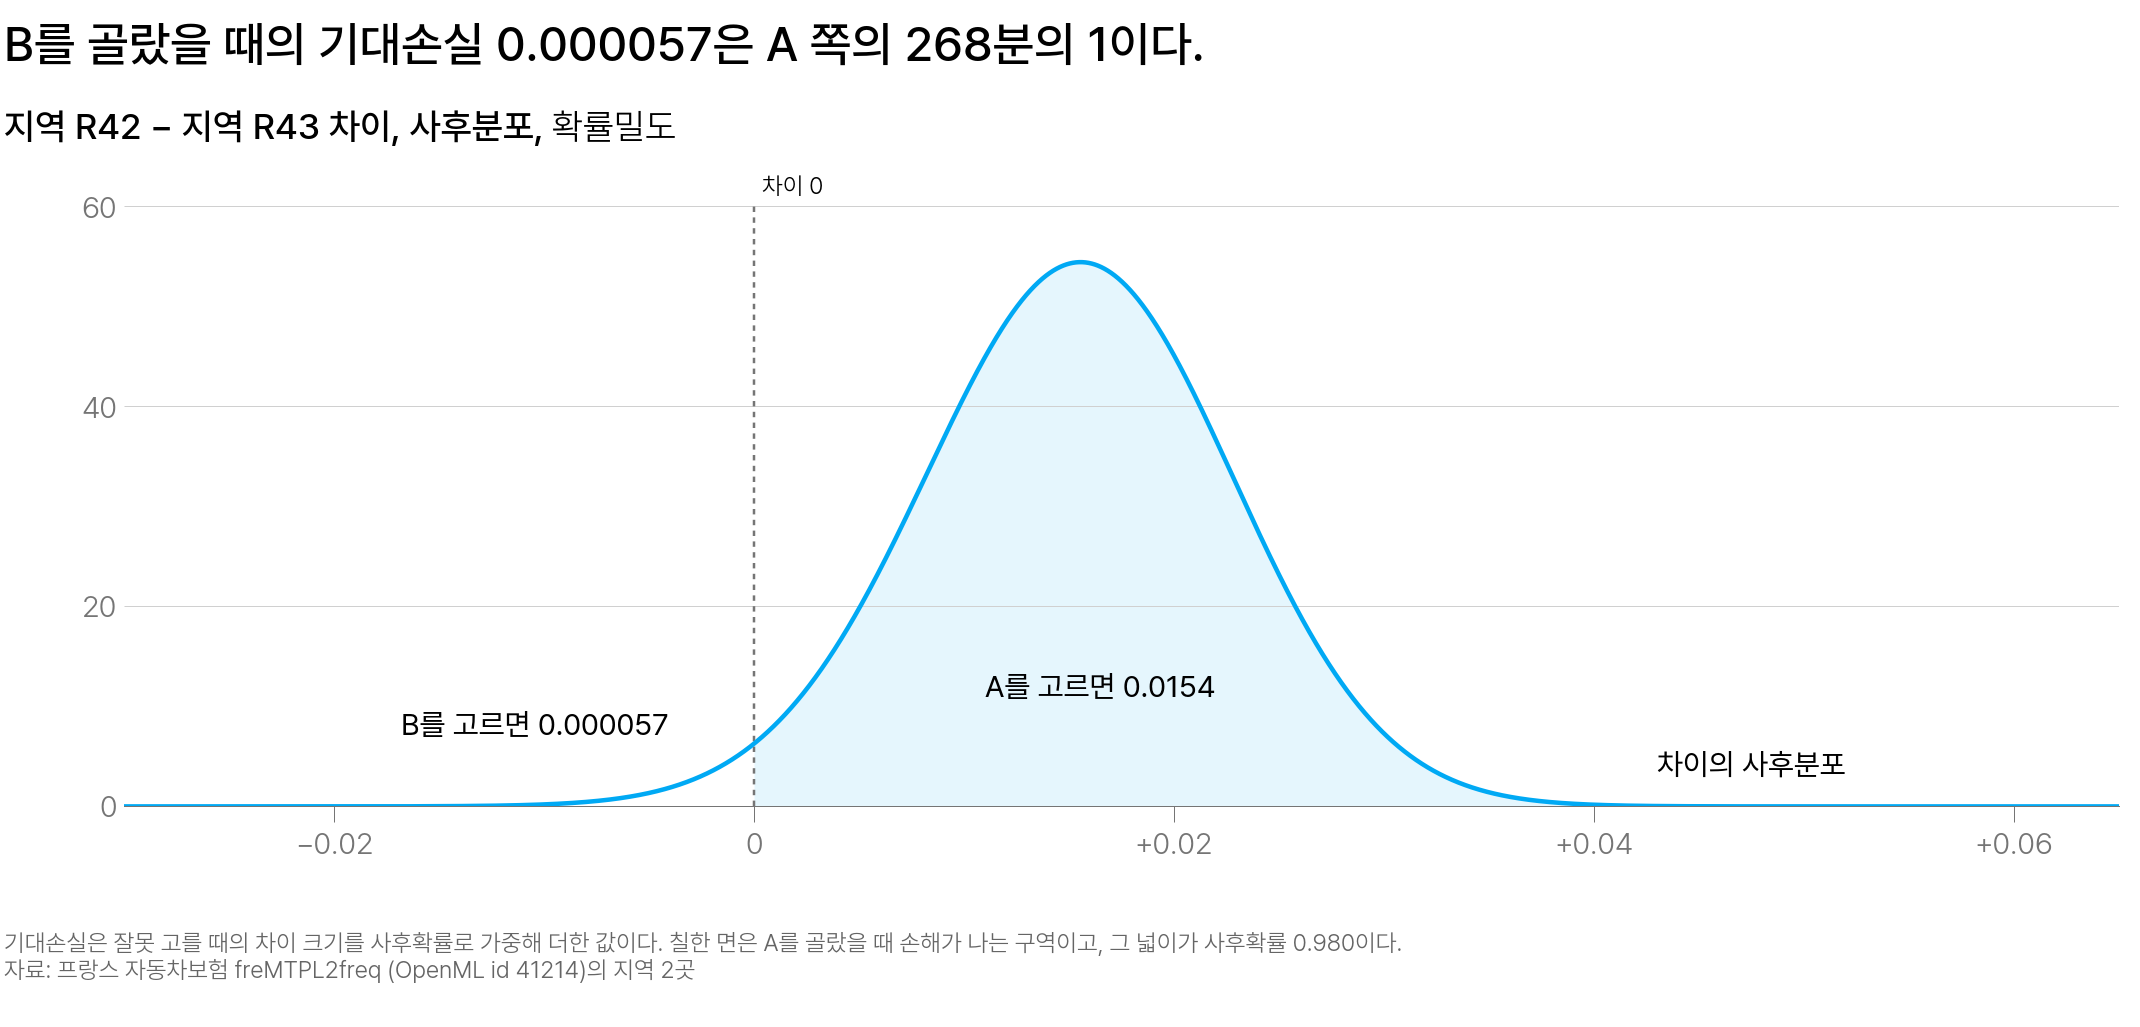

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 차이 θ_B − θ_A 의 사후분포 — 회색 점선이 차이 0이고, 하늘색 오른쪽 구역의 넓이가 사후확률 0.980이다. 왼쪽에 남은 얇은 꼬리가 B를 골랐다가 틀리는 시나리오이고, 두 방향의 기대손실이 곡선 위에 적혀 있다</em></p>

#### 결과 해석

예측 질문의 답은 **수백 배쯤** 입니다. B를 골랐을 때의 기대손실은 **0.000057**, A를 골랐을 때는 **0.0154** — **268배** 차이입니다. 확률만 보면 0.980 대 0.020으로 49배인데, 크기까지 곱하면 격차가 5배 이상 커집니다.

0.000057 은 사고 경험 비율의 단위 그대로입니다. 계약 1만 건으로 환산하면 **0.57건**이고 A 쪽 0.0154 는 같은 1만 건에서 154건입니다.

**그래서** 결정에 쓸 수 있는 말은 "틀릴 확률 2%"가 아니라 "틀려도 1만 건당 0.57건만 손해"입니다. 담당자가 "1만 건당 1건까지는 감수한다"고 하면 기준값이 0.0001 이라 B 쪽은 그 아래, A 쪽은 154배 밖입니다.

<details class="lms-extra"><summary>자세히 — 기대손실을 적분으로 적고 몬테카를로로 다시 구하는 계산</summary>

B 를 골랐을 때라면 이렇게 적습니다. 변하는 값이 $\theta_A$ 와 $\theta_B$ 둘이라, 적분 기호도 둘이고 뒤에 오는 미분소도 $d\theta_A$ · $d\theta_B$ 둘입니다.

$$
\mathbb{E}[\text{loss} \mid B \text{ 선택}] = \int_{0}^{1}\!\!\int_{0}^{1} \max(\theta_A - \theta_B,\ 0)\; p(\theta_A, \theta_B \mid D)\; d\theta_A\, d\theta_B
$$

- $\max(\theta_A - \theta_B, 0)$ : B를 골랐는데 사실 A가 더 컸을 때만 손해로 세고, 아니면 0
- $p(\theta_A, \theta_B \mid D)$ : 데이터를 본 뒤의 사후분포 — 각 시나리오의 가중치
- $\int_{0}^{1}\!\!\int_{0}^{1} \cdots\, d\theta_A\, d\theta_B$ : 두 모수 각각에 대해 0 에서 1 까지 2번 더한다는 뜻입니다. 양쪽 모수 모두 0 과 1 사이에 있으니 그 구간 전체를 대상으로 합니다

적분을 손으로 풀지 않고 표본으로도 계산할 수 있습니다.

**⑴ 사후분포에서 값을 뽑아 차이를 만듭니다.** $\theta_A$ 와 $\theta_B$ 를 각각 20만 개 뽑아 $d = \theta_B - \theta_A$ 를 만들면 차이의 사후 표본이 됩니다.

**⑵ 음수인 것은 그 크기를, 양수인 것은 0을 적습니다.** 위 카드에서는 `np.maximum(-d, 0)` 이 이 규칙을 그대로 옮깁니다 — B를 골랐는데 사실 A가 컸던 시나리오만 손해로 집계하는 것입니다.

**⑶ 전체를 평균냅니다.** 20만 개 전부로 나누므로 손해가 발생한 시나리오의 비율만큼 값이 줄어듭니다.

여기서 두 값이 달라집니다. **음수인 것만 따로 골라 평균내면** $\mathbb{E}[\,-d \mid d < 0\,] = 0.0028$ 이 나오는데, 그것은 '틀렸을 때의 평균 손해 크기'입니다. 기대손실은 거기에 **틀릴 확률** $P(d < 0) = 0.0202$ 를 곱해 전체로 평균낸 값이라

$$
0.0028 \times 0.0202 = 0.000057
$$

로 감소합니다. 곧 $1 \div 0.0202 = 49.5$ 배 작아진 값입니다. 앞 문단의 49배 $(= 0.980 \div 0.020)$ 와 값이 비슷한 것은 한쪽이 다른 쪽의 원인이어서가 아니라 **둘이 같은 확률 0.02 를 분모에 두고 있어서**입니다 — 분자에 한쪽은 1 을, 다른 쪽은 $1 - 0.0202 = 0.9798$ 을 놓았을 뿐이라 $0.9798 \div 0.0202 = 48.5$, 곧 49.5 와 2% 밖에 차이 나지 않습니다. 앞 문단의 49배는 같은 값을 반올림한 0.980 과 0.020 으로 계산한 것이라 48.5 대신 49 로 적혔습니다.

</details>

In [ ]:
# 두 사후분포에서 뽑아 결정에 필요한 숫자를 한꺼번에 만들기
import numpy as np

rng = np.random.default_rng(20260829)   # 시드 고정
N = 200000

theta_A = rng.beta(55, 1273, N)         # 지역 R43 의 사후분포 Beta(55, 1273)
theta_B = rng.beta(125, 2077, N)        # 지역 R42 의 사후분포 Beta(125, 2077)
d = theta_B - theta_A                   # 차이의 사후 표본

lo, hi = np.percentile(d, [2.5, 97.5])
print(f"P(theta_B > theta_A)  : {np.mean(d > 0):.4f}")
print(f"차이의 95% 신용구간   : {lo:+.5f} ~ {hi:+.5f}")

# 같은 95% 를 HPD 로 다시 자르기 - 아래꼬리 비율을 0% 부터 5% 까지 옮겨 가장 짧은 구간을 고른다
tails = np.linspace(0, 0.05, 101)
lo_h, hi_h = np.quantile(d, tails), np.quantile(d, tails + 0.95)
j = np.argmin(hi_h - lo_h)
print(f"차이의 95% HPD 구간   : {lo_h[j]:+.5f} ~ {hi_h[j]:+.5f}")
print(f"두 구간의 길이        : 등꼬리 {hi - lo:.5f} / HPD {hi_h[j] - lo_h[j]:.5f}")

print(f"기대손실 - B 를 고르면: {np.mean(np.maximum(-d, 0)):.6f}")
print(f"기대손실 - A 를 고르면: {np.mean(np.maximum(d, 0)):.4f}")

# 같은 차이를 빈도주의로 - 두 지역의 사고 기록을 복원추출해 만든 부트스트랩 신뢰구간
rng_b = np.random.default_rng(20260830)
rec_A = np.repeat([1, 0], [54, 1326 - 54])     # 지역 R43 - 1,326 건 중 사고 54 건
rec_B = np.repeat([1, 0], [124, 2200 - 124])   # 지역 R42 - 2,200 건 중 사고 124 건
boot = np.array([rng_b.choice(rec_B, rec_B.size).mean()
                 - rng_b.choice(rec_A, rec_A.size).mean() for _ in range(4000)])
blo, bhi = np.percentile(boot, [2.5, 97.5])
print(f"차이의 95% 신뢰구간   : {blo:+.5f} ~ {bhi:+.5f}  (부트스트랩)")
print(f"신용·신뢰 구간 길이   : 신용 {hi - lo:.4f} / 신뢰 {bhi - blo:.4f}")
print(f"부트스트랩 표준오차   : {boot.std(ddof=1):.4f}")

ROPE = 0.005                            # 실무적으로 '같다'고 볼 차이의 범위
print()
print(f"ROPE +-{ROPE} 안에 든 사후확률 : {np.mean(np.abs(d) < ROPE):.3f}")

#### 결과 해석

$P(\theta_B > \theta_A) = 0.9798$ 은 격자 계산의 0.9800 과 0.0002 차이입니다 — 소수 셋째 자리에서 반올림하면 둘 다 0.980 입니다.

차이의 95% 신용구간은 **+0.0007 ～ +0.0296**, 통째로 0보다 오른쪽이라 "차이의 부호는 정해졌다"고 말할 수 있습니다. 같은 차이를 부트스트랩으로 잘라도 **+0.0005 ～ +0.0306** 이라 구간 길이가 거의 같습니다 — 두 구간은 같은 모수를 서로 다른 분포에서 추정한 것으로, 부트스트랩은 재표집으로, 모형 기반 표준오차는 적합한 분포로 같은 변동성을 측정합니다. 그 아래 표준오차 **0.0074** 는 재표본 4,000벌의 표준편차이고, 7. 오늘의 정리의 5단계 요약 그림 둘째 상자에 그대로 씁니다.

카드가 같은 95% 를 HPD 로 다시 잘라도 한 자리도 달라지지 않습니다. 두 베타분포의 차라 사후분포가 거의 좌우대칭이어서 등꼬리로 자른 자리가 이미 가장 짧은 자리이기 때문이고, 사후분포의 최빈값이 0 에 근접한 세그먼트라면 둘이 달라집니다.

카드 마지막 행의 `ROPE +-0.005 안에 든 사후확률` 은 다음 소절에서 정의하는 실무 기준이라 거기서 읽습니다.

그런데 신용구간의 하한은 **+0.0007**, 계약 1,000건에 0.7건 차이입니다. 요율표를 고칠 만한 차이인지 판단해야 합니다.

## ROPE — "통계적으로 다르다"와 "실무적으로 다르다"

- **ROPE(Region Of Practical Equivalence, 실질적 동등 구간)** — 실무적으로 "같다"고 보아 넘길 차이의 범위입니다.
  - **직관**: 요율 담당자에게 "얼마나 달라야 요율표를 고칠 필요가 있습니까?"라고 물어서 정하는 숫자입니다. 데이터가 아니라 **업무가 정하는 값**입니다.
  - **예시**: 여기서는 ±0.005(0.5%p)로 설정합니다.

기각·수용의 대상은 "이 차이는 실무적으로 0과 같다"는 주장 하나입니다 — $p$ 값이 다루는 "차이가 정확히 0이다"와는 다른 주장입니다. 판정은 신용구간과 ROPE 구간의 관계로 셋 중 하나가 됩니다.

| 신용구간과 ROPE의 관계 | 판정 | 읽는 문장 |
|---|---|---|
| 구간이 ROPE 밖에 통째로 놓임 | **기각** (실질적 동등을 기각) | 실무적으로도 다르다 |
| 구간이 ROPE 안에 통째로 들어감 | **수용** (실질적 동등을 수용) | 실무적으로 같다 |
| 구간이 ROPE 경계를 가로지름 | **보류** | 아직 판단할 근거가 부족하다 |

원래 이 판정은 HPD 구간으로 계산하는 것이 관례인데, 이 사후분포는 최빈값이 +0.0155 에 위치한 거의 좌우대칭 곡선이라 HPD 가 등꼬리와 같은 위치에 나타났습니다. 그래서 아래에서는 코드 카드가 만든 등꼬리 신용구간 +0.0007 ～ +0.0296 을 그대로 씁니다.

같은 ROPE 구간을 차이의 사후분포 위에 표시합니다.

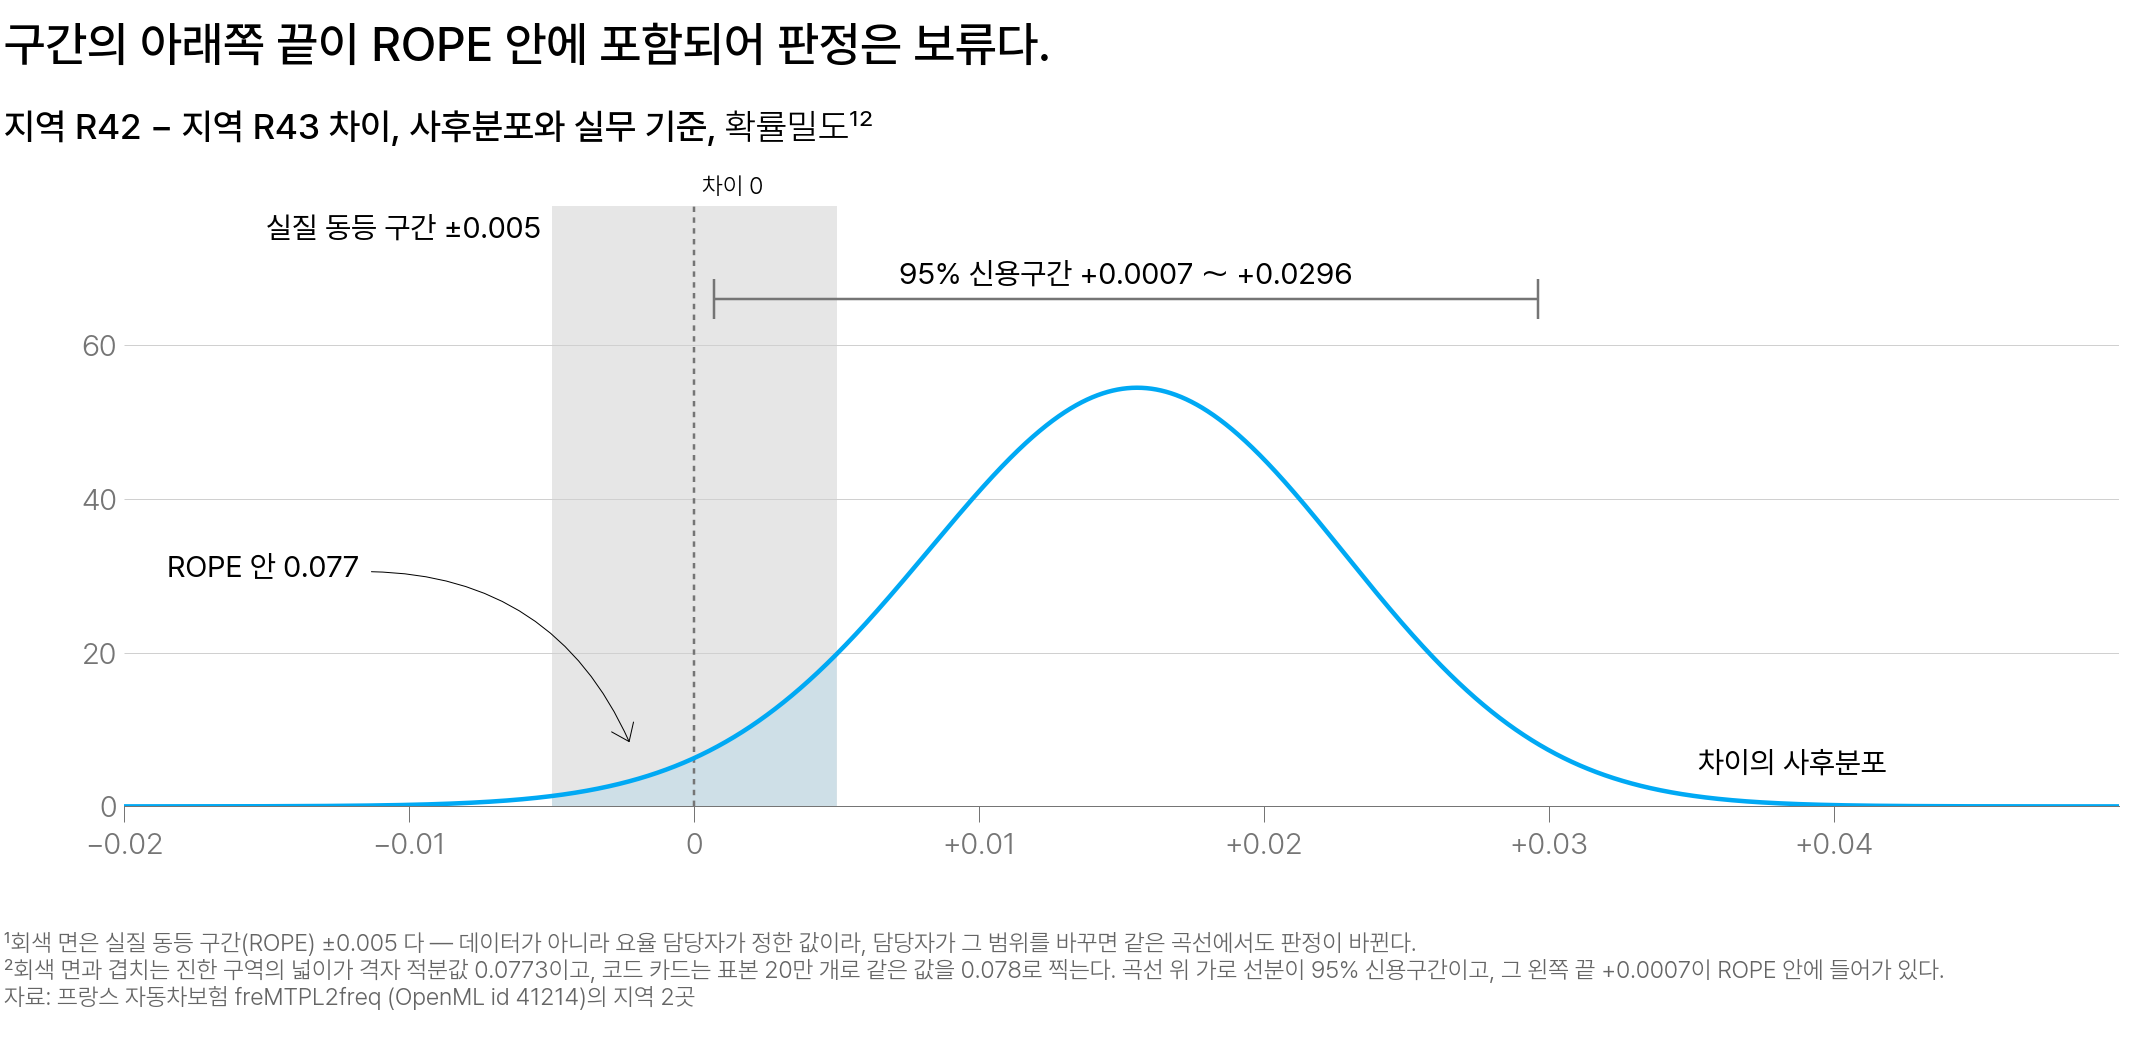

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 차이 θ_B − θ_A 의 사후분포에 실질 동등 구간(ROPE) ±0.005 를 회색 구간으로 표시한 것 — 그 회색 구간과 겹치는 진한 구역의 넓이가 ROPE 안에 든 사후확률 0.077 이고, 곡선 위 가로 선분이 95% 신용구간 +0.0007 ～ +0.0296 이다. 그 선분의 왼쪽 끝이 회색 ROPE 구간 안으로 들어가 있다</em></p>

#### 결과 해석

카드의 마지막 행이 ROPE 안에 든 사후확률 **0.078** 을 찍었고(표본 20만 개로 센 값), 그림에서 진하게 칠한 구역이 그 값입니다 — 그림 라벨의 0.077 은 같은 확률을 격자 적분으로 낸 값이라 셋째 자리에서만 달라집니다. 그런데 **판정을 결정하는 것은 넓이가 아니라 신용구간의 아래 끝점**입니다. 신용구간 +0.0007 ～ +0.0296 은 ROPE 구간의 위쪽 경계 +0.005 를 가로지릅니다.

판정은 **보류** 입니다. 방향은 사후확률 0.980으로 분명한데, 크기가 0.07%p 에서 2.96%p 로 넓고 그 아래쪽 끝은 요율표를 개정할 만한 크기가 아닌 구간입니다. **방향은 정해졌는데 크기가 미정**, 이것이 확률 하나만 적었을 때 사라지는 정보입니다.

ROPE 구간 길이가 데이터에서 나온 값이 아니라는 것도 함께 읽어야 합니다. ±0.0005 로 좁혔다면 같은 구간에서 판정이 **기각**이 되고, ±0.03 으로 넓혔다면 **수용**입니다.

#### ROPE 판정이 「수용」으로 나오는 사례

보류 사례만 보면 이 판정 방법이 늘 결론을 미루는 것처럼 보이므로, 같은 데이터에서 **수용**이 나오는 세그먼트도 봅시다. 차량 출력 등급 6 이하와 7 이상, 두 세그먼트입니다. 6 이하는 계약 389,146건 중 사고 경험이 20,124건, 7 이상은 288,867건 중 13,936건입니다. 코드는 앞 코드에 지역 2곳 대신 이 두 세그먼트를 대입했습니다.

In [ ]:
# ROPE 가 '수용'을 내는 사례 - 앞 카드의 지역 2곳 대신 차량 출력 등급 두 세그먼트를 넣는다
import numpy as np

rng = np.random.default_rng(20260901)   # 시드 고정

lo6 = rng.beta(1 + 20124, 1 + 389146 - 20124, 200000)   # 출력 6 이하 - 389,146 건 중 20,124 건
hi7 = rng.beta(1 + 13936, 1 + 288867 - 13936, 200000)   # 출력 7 이상 - 288,867 건 중 13,936 건
dv = hi7 - lo6                                          # 차이 (7 이상 - 6 이하) 의 사후 표본

vlo, vhi = np.percentile(dv, [2.5, 97.5])
print(f"차이의 95% 신용구간      : {vlo:+.4f} ~ {vhi:+.4f}   (길이 {vhi - vlo:.4f})")
print(f"ROPE +-0.005 안 사후확률 : {np.mean(np.abs(dv) < 0.005):.3f}")

#### 두 사례의 판정을 결정한 요인: 구간 길이

구간이 **−0.0045 ～ −0.0024**, 길이가 **0.0021** 입니다. 부호가 음수라 출력 7 이상 쪽이 오히려 사고 경험 비율이 **낮습니다** — $13{,}936 / 288{,}867 = 0.0482$ 대 $20{,}124 / 389{,}146 = 0.0517$ 입니다. 계약이 678,013건이나 되니 구간이 이만큼 좁아졌고, 그래서 ±0.005 ROPE 구간 안에 전부 포함됩니다 — 그 구간 안에 든 사후확률 **0.998**. "차이의 존재는 확실하지만 크기가 실무 기준으로는 무시할 수준 — **요율표를 나눌 값이 없다**"가 됩니다.

**그래서** 두 사례를 구분한 것은 판정 방법이 아니라 구간 길이입니다. 두 사례 모두 계약이 넉넉해 구간을 만드는 방식 자체는 맞는 자리라, 앞(1. 표준오차)에서 형태 때문에 걸렸던 것과 달리 여기서는 길이 하나가 판정을 갈랐습니다.

두 지역 쪽은 계약이 3,526건이라 구간 길이가 0.0289, 이쪽의 14배였습니다. 확실함이 곧 중요함은 아니라는 사실을 판정에 반영하는 방법입니다.

## 정지 규칙과 엿보기 — 중간 확인 반복이 오경보율에 미치는 영향

이 절의 마지막 항목입니다. 대시보드에 유의하다는 표시가 뜨면 그 자리에서 결론을 내리고 싶어집니다. 이 습관의 이름이 **엿보기(peeking)** 입니다.

두 집단의 참값이 **완전히 같은** 모의실험에서 중간 확인 횟수만 바꿔 가며 6만 번 모의해 봤습니다. 참값이 같으니 「차이가 있다」는 결론은 전부 오경보이고, 그 비율이 **오경보율(false alarm rate)**, 곧 차이가 없는데도 있다고 판정해 버린 모의가 차지하는 비율입니다. 1번만 확인하면 설계대로 5%가 나와야 합니다.

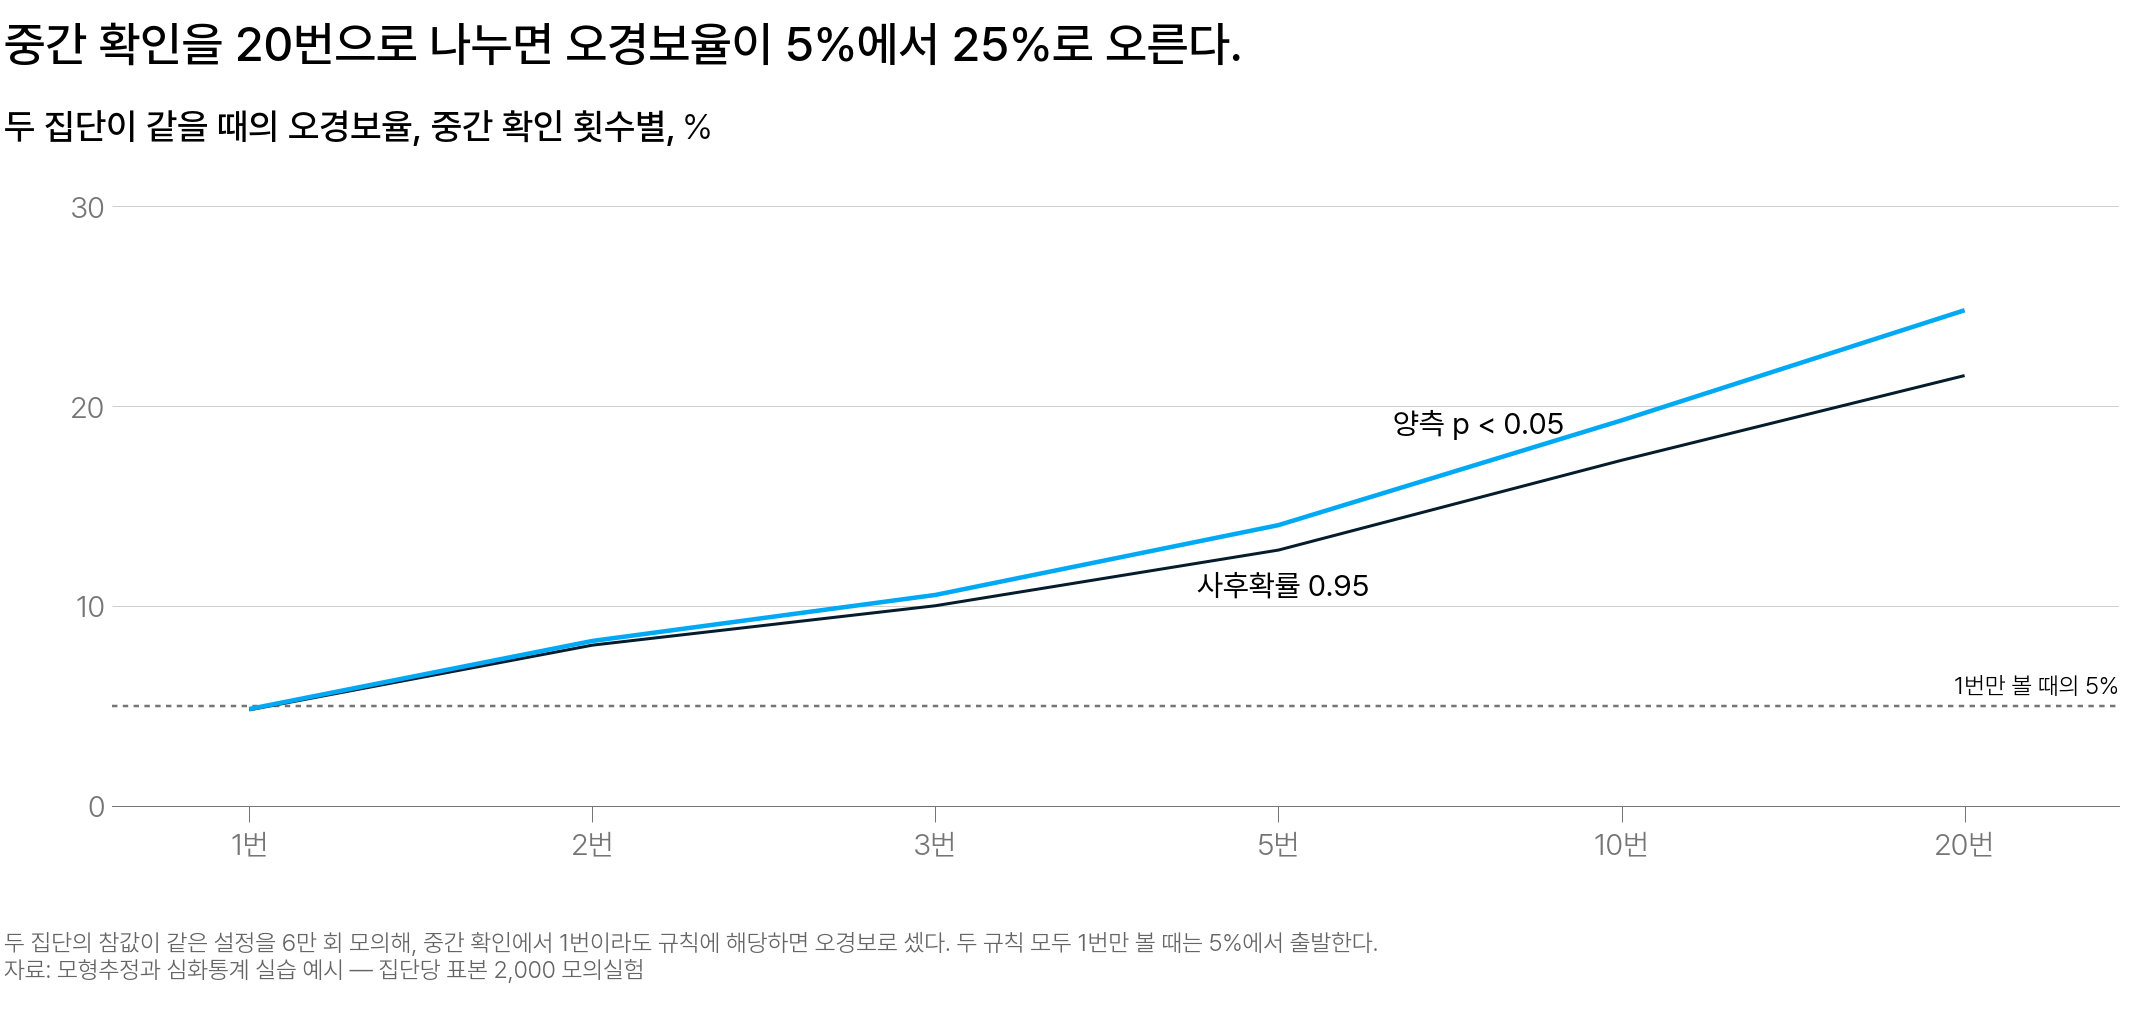

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 두 집단의 참값이 같은 모의실험에서 중간 확인 횟수를 늘렸을 때의 오경보율 — 하늘색은 양측 p 값이 0.05 아래로 내려가면 멈추는 규칙, 남색은 사후확률 0.95를 넘으면 멈추는 규칙이다. 중간 확인을 늘릴수록 하늘색은 회색 점선인 5%를 크게 넘어 20번이면 24.8%까지 오른다</em></p>

#### 결과 해석

4회 중 1회 비율로 오경보가 발생합니다. **p 값** 은 두 집단이 같다고 두었을 때 지금 본 만큼 큰 차이가 우연히 나올 확률입니다. 양측 $p < 0.05$ 규칙은 1번만 확인하면 4.9%로 설계대로인데 20번이면 **24.8%** 까지 올라갑니다. 베이지안 정지 규칙도 4.8%에서 **21.5%** 로 함께 오릅니다. **그래서** 실무 처방은 사후확률 하나가 아니라 **기대손실을 함께 확인하는 것**입니다 — 크기까지 곱하므로 데이터가 적으면 기준값 아래로 쉽게 내려가지 않습니다.

<details class="lms-extra"><summary>자세히 — 오경보율이 64% 가 아니라 24.8% 에서 멈추는 이유와 순차 설계의 기준값 배분</summary>

하늘색 선인 양측 $p < 0.05$ 규칙은 2번이면 8.3%, 5번이면 14.1%, 20번이면 24.8% 입니다.

**⑴ 왜 오르나.** 확인 시점마다 5%의 오경보 기회가 새로 열리고, 그중 하나라도 해당하면 거기서 멈추기 때문입니다. 20번이 완전히 독립이었다면 1번이라도 해당할 확률이 $1 - 0.95^{20} = 64\%$ 까지 증가했을 것입니다.

**⑵ 그런데 독립이 아닙니다.** 10번째 확인은 5번째 확인이 본 데이터를 그대로 포함합니다. 겹치는 데이터 때문에 24.8% 에서 멈추는데 그래도 설계값 5%의 5배입니다.

**⑶ 베이지안 쪽도 같이 오릅니다.** 사후분포 자체는 어느 표본 크기에서 계산해도 해석이 성립합니다. 그런데 **"0.95를 넘는 순간 멈춘다"는 규칙 자체가 표본을 고르는 행위**입니다. 위로 튄 순간에만 멈추도록 설계했으므로 결론이 한쪽으로 치우칩니다. 문제는 추론 방식의 차이가 아니라 정지 규칙에 있습니다.

**⑷ 중간 확인 자체가 잘못은 아닙니다.** 문제는 계획 없이 보는 것이고, 임상시험이 오래전부터 써 온 해법의 이름이 **순차 설계(group sequential design)** 입니다. 분석 시점을 미리 적어 두면 전체 오경보율이 5%를 넘지 않도록 각 시점의 기준값을 나눠 배분할 수 있습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Group_sequential_design_example_-_possible_realisations.png" width="640" height="549"/>
<p align="center"><em>▲ 위는 정해진 인원을 다 모으는 설계, 아래는 중간 결과에 따라 인원을 더 모으는 설계 — 두 흐름 모두 화살표 순서에 Interim Analysis(중간 분석)가 Design 단계에서 이미 자리를 잡고 있다. 계획된 중간 분석과 엿보기를 가르는 것은 분석 시점을 미리 적어 두었는지다. (출처: Wikimedia Commons, "Group sequential design example")</em></p>

4번 본다면 가장 단순한 배분은 5%를 4개로 나누어 확인마다 기준값을 $0.05 / 4 = 0.0125$ 로 두는 것입니다. 시점 4개가 같은 데이터를 이어받아 겹치는 만큼, 이렇게 두면 실제 오경보율은 3.5% 까지 감소합니다.

임상시험이 실제로 쓰는 배분은 앞쪽을 훨씬 엄격하게 잡습니다. 4번 보는 오브라이언-플레밍(O'Brien-Fleming) 배분이 대표적이고, 기준값이 1차 0.00005 · 2차 0.0042 · 3차 0.0194 · 4차 0.0429 로 정해집니다. 초반에는 사실상 멈추지 못하게 두고 마지막에 가서야 5% 언저리 기준값을 사용하는 방식입니다. 이 배분표를 정하는 규칙이 **알파 소비 함수(alpha spending function)** 입니다.

</details>

### [직접 해보기] 정지 시점에 따른 결론의 변화

둘째 날 두 지역을 비교할 때 조작한 위젯을 다시 사용합니다. 이번에는 곡선이 아니라 **멈추는 시점**을 확인합니다.

1. **조작.** 위젯은 `각 700건` 에서 열립니다. `투입 계약 수` 슬라이더를 먼저 가장 왼쪽(계약 80건)으로 이동시킨 뒤, 거기서 오른쪽 끝 `각 1,326건` 까지 천천히 이동시킵니다. 처음 화면으로 돌아가려면 슬라이더를 `각 700건` 자리로 다시 옮기면 됩니다.
2. **관찰.** `P(θ_B > θ_A)` 숫자는 그래프 아래 오른쪽, 슬라이더 바로 위 표시란에 있습니다. 옮기는 내내 오르내립니다 — 0.95를 넘어섰다가 다시 내려오는 구간이 있는지, 있다면 계약 몇 건 부근인지 확인합니다. 가운데 회색으로 칠한 구간(화면 이름 `회색 띠`)이 이 절에서 정한 실질 동등 구간 ±0.005 입니다. 이 회색 구간은 **차이가 아니라 개별 비율을 그린 가로축 위에** 있습니다. 지역 R43 의 사후평균(회색 구간 안의 가는 세로선)을 가운데 두고 좌우로 0.005 씩 벌린 것입니다. 그래서 `지역 R42` 곡선이 그 회색 구간을 얼마나 벗어나는지가 곧 차이가 ±0.005 를 넘는지입니다.
3. **확인 질문.** "0.95를 처음 넘는 순간 멈춘다"는 규칙으로 이 슬라이더를 사용했다면 계약 몇 건에서 결론을 내리게 되겠습니까? 그리고 그 결론이 1,326건을 모두 사용했을 때의 결론과 같겠습니까?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/ab-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 「0.95 를 처음 넘는 순간 정지」 규칙에서의 결론 시점</summary>

숫자는 한 방향으로 오르지 않습니다. 계약 80건에서 0.895로 출발해 **177건에서 0.60까지 떨어지는데**, 슬라이더 전 구간을 통틀어 이 지점이 가장 낮습니다.

거기서 다시 올라왔다가 500건 부근에서 0.76까지 1번 더 내려갑니다. 600건을 지나면서 0.95를 넘어섰다가, 840건부터 1,060건 사이에서 다시 0.95 아래로 내려갑니다. 슬라이더 전 구간에서 0.95 를 10회 이상 오르내립니다. 한 단계씩 세밀하게 이동시키면 315건 부근에 3단계 길이의 국소 최댓값이 하나 더 있어서, 거기서 이미 1번 0.95를 넘습니다.

그래서 확인 질문의 답은 숫자 하나가 아닙니다 — **한 단계씩 세밀하게 이동시키면 315건, 몇 단계씩 굵게 이동시키면 600건**이고, 조작 간격에 따라 답이 달라진다는 것 자체가 답입니다.

그러니 "0.95를 처음 넘는 순간 멈춘다"는 규칙은 멈추는 시점을 데이터가 아니라 **어디서 확인했는가**가 정하게 둡니다. 어디서 멈췄든 "지역 R42 쪽이 더 높다"는 방향까지는 결론이 같습니다.

다만 계약 600건에서 멈췄다면 그 화면의 `지역 R42` 곡선은 왼쪽 자락이 `회색 띠` 안쪽까지 들어와 있습니다. 그 회색 구간은 지역 R43 의 사후평균 좌우로 0.005 씩 벌린 것이라 개별 비율을 그린 가로축 위에 위치합니다. 크기는 여전히 미정입니다.

앞 그림의 남색 선(사후확률 0.95 정지 규칙)이 오른쪽 위로 올라간 이유가 방금 조작한 이 과정에 그대로 나타납니다. 실무 처방이 "사후확률 하나"가 아니라 "기대손실을 함께 본다"인 것도 그래서입니다.

슬라이더를 끝까지 이동시켜도 답은 달라지지 않습니다. 계약을 모두 사용한 지점에서도 `지역 R42` 곡선의 왼쪽 자락은 그 `회색 띠`(회색 ROPE 구간)에 닿아 있습니다.

위젯은 지역 R42의 계약 2,200건 가운데 앞 1,326건만 써서 두 지역에 같은 수를 적용합니다. 2,200건을 전부 사용해 앞에서 계산한 ROPE 판정도 그대로 보류였습니다. 더 오래 본다고 크기가 저절로 정해지지는 않고, 정해지는 것은 방향뿐입니다.

</details>

## 이 비교가 A/B 테스트가 아닌 이유

계산을 마쳤으니 보고 문장을 적을 때의 주의 1개로 이 절을 마칩니다. 빈도주의 방법으로 같은 데이터를 검정해도 결론의 방향은 사후확률 0.980과 같습니다.

**카이제곱 통계량** $\chi^2$ 는 두 비율이 같다고 두었을 때의 기대 빈도에서 관측 빈도가 벗어난 정도입니다. 여기서는 $\chi^2 = 4.222$ 에 $p = 0.0399$ 입니다. 대응하는 방법도 정해져 있습니다 — ROPE 수용의 짝은 **동등성 검정(TOST, two one-sided tests)**, 정지 규칙 설계의 짝은 **알파 소비 함수** 입니다.

그런데 두 결과 모두 **"지역이 사고율을 높인다"로 읽으면 틀립니다** — 이 데이터에서는 계약자가 거주 지역을 스스로 선택하기 때문입니다. 웹 서비스의 A/B 테스트는 동전을 던져 사용자를 두 무리로 나누므로 두 무리의 차이가 우리가 바꾼 것 하나로 좁혀지는데, 지역은 그렇게 나뉘지 않습니다.

눈에 보이게 다른 것 하나가 **평균 노출** 입니다 — R43 이 0.4252년, R42 가 0.5494년으로 R42 쪽이 더 오래 관측한 계약입니다. 사고를 1번이라도 겪을 비율은 노출에 정비례하지 않고 $1 - e^{-\lambda t}$ 라, 앞(1. 표준오차)의 전체 사고율 0.1006건/년을 $\lambda$ 자리에, 두 평균 노출을 $t$ 자리에 대입하면 0.0419 와 0.0538 이 나옵니다. 뒤엣것을 앞엣것으로 나눈 1.284 가 사고율이 같다고 두고 노출만 반영해 얻은 예측 비이고, 관측된 비는 1.384 입니다. 관측된 비를 예측된 비로 나누면 $1.384 \div 1.284 = 1.078$ 입니다. 지켜본 기간의 차이를 걷어 내고도 **8%** 가 남고, 그 8% 에 지역과 함께 작용하는 다른 조건들이 포함돼 있습니다. 배수는 빼는 값이 아니라 나누는 값이라 「1.384 가운데 1.284 까지」 처럼 뺄셈으로 읽지 않습니다.

#### 요율 개정 회의에 제출할 결론

**계산 방법은 같고 읽는 문장만 다릅니다.** 우리가 말할 수 있는 것은 "두 집단의 사고 경험 비율이 다르다"까지입니다.

요율표는 지금 고치지 않습니다. 방향은 분명하지만 크기가 실무 기준 ±0.005 를 걸쳐 판정이 보류이고, 서둘러 결정했을 때의 기대손실이 0.000057로 작으므로 서두를 이유도 없습니다. 대신 **분기마다 1번, 총 4번**만 확인한다고 먼저 적어 둡니다.

#### 핵심 주의점

사후확률 0.980 을 "요율표를 고칠 만큼 다를 확률" 로 해석하면 안 됩니다.

$$
P(\theta_B > \theta_A) = 0.980
$$

- $\theta_B - \theta_A$ : R42 와 R43 의 사고 경험 비율 차이

이 값이 주는 정보는 차이의 부호 하나뿐이라 차이의 크기는 한 자리도 말해 주지 않습니다. 따라서 "0.980 이니 R42 쪽 요율을 올릴 만큼 높다" 는 틀린 문장입니다.

정확한 뜻은 다음과 같습니다.

> **R42 의 사고 경험 비율이 R43 보다 높을 사후확률이 0.980 이고, 그 크기는 +0.0007 ～ +0.0296 사이로만 좁혀져 실무 기준 ±0.005 를 걸친다.**

확률 하나로는 결정이 안 된다고 시작했는데, 결정에 필요했던 것은 5가지였습니다.

- **차이의 크기** — 신용구간 +0.0007 ～ +0.0296
- **잘못 골랐을 때의 손실** — 기대손실 0.000057 대 0.0154
- **실무 기준** — ROPE ±0.005
- **정지 규칙** — 분기마다 1번, 총 4번
- **보고서에 적을 문장** — "방향은 정해졌고 크기는 미정"

그런데 이 구간들은 모두 같은 전제 위에서 계산됐습니다 — 잔차가 종 모양이고, 산포가 고르고, 관측이 서로 독립이라는 전제입니다. 다음 절에서 그 가정을 점검합니다.

> **[문제] 두 구간의 보고 문장과 실질 동등 구간 축소 후의 판정**
>
> 두 지역의 사고 경험 비율 차이를 두고 부트스트랩 신뢰구간 +0.0005 ～ +0.0306, 사후분포의 신용구간 +0.0007 ～ +0.0296을 각각 만들었습니다. 구간 길이가 0.0301과 0.0289로 거의 같습니다. 먼저 두 구간을 보고서에 옮길 때 문장이 어떻게 달라져야 하는지 적습니다. 그다음, 요율 담당자가 실질 동등 구간을 ±0.005 에서 **±0.002 로 좁혀** 왔다고 해 봅시다. 같은 신용구간 +0.0007 ～ +0.0296 으로 판정이 어떻게 바뀌는지, 그리고 그 판정을 가른 것이 사후분포의 **넓이**인지 구간의 **끝점**인지를 근거와 함께 적습니다.

## 5. 잔차 진단 — 신뢰구간이 전제한 가정의 점검

## 앞(4. 신뢰구간을 이용한 의사결정)이 낸 +0.0007 ～ +0.0296 을 그대로 믿어도 되는가

**여기서 할 일**

1. 앞 절의 구간이 전제한 **가정 3개**를 잔차 위에서 하나씩 점검합니다.
2. 분산이 평균보다 큰 상태를 건수 데이터 전용 잔차로 측정하고, 그 값을 표준오차에 반영합니다(두 용어는 각각 뒤에서 정의합니다).
3. 세 가정 가운데 우리 구간 길이를 가장 크게 바꾸는 것이 무엇인지 배수로 비교합니다.

앞 절의 판정은 관찰 하나에 달려 있었습니다 — 신용구간 +0.0007 ～ +0.0296 의 왼쪽 끝이 ROPE 경계 안에 들어온다는 관찰입니다. 그런데 그 구간의 길이를 정한 표준오차는 계약들이 서로 독립이라는 전제 위에서 계산된 값입니다. 계약이 지역 단위로 뭉쳐 있다면 그 전제가 성립하지 않고, 이 절 끝에서 확인하듯 셋째 날 회귀계수의 표준오차가 몇 배로 커집니다. 그 배수를 앞 절의 신용구간에 그대로 옮겨 써도 되는지는 이 절 끝에서 다시 문제가 되는데, **옮겨 쓸 수 있다면** 왼쪽 끝 +0.0007 은 0 아래로 내려가 방향조차 미정이 됩니다.

곧 앞 절의 결정은 구간에 의존하고, 구간은 표준오차에 의존합니다. 그 가정이 성립하지 않으면 **점추정은 그대로인데 구간만 틀립니다.**

**잔차(residual)** — 관측값 $y_i$ 에서 적합선의 예측값 $\hat{y}_i$ 를 뺀 나머지입니다. 적합선이 설명하지 못하고 남긴 부분이라, 관측이 선 위면 양수, 아래면 음수입니다.

$$r_i = y_i - \hat{y}_i$$

세 가정은 모두 이 잔차에 적용되는 조건이고, 어겼을 때 틀어지는 지점이 다릅니다.

| 가정 | 잔차의 조건 | 어겼을 때 틀어지는 지점 |
|---|---|---|
| **① 정규성** | 0을 가운데 두고 종 모양으로 흩어진다 | 소표본에서 구간의 적중률이 선언값에 못 미친다 |
| **② 등분산성** | 산포가 $x$ 어디에서나 같다 | 표준오차가 편향되어 유의성이 과대·과소평가된다 |
| **③ 독립성** | 한 관측의 잔차가 옆 관측의 잔차를 알려 주지 않는다 | 유효 표본 수가 실제보다 많게 계산돼 구간이 좁아진다 |

<details class="lms-extra"><summary>자세히 — 잔차 모양 3가지와 가정별 검정·대응책</summary>

그림 3장 모두 위 패널은 짙은 붉은 적합선과 그 잔차를 함께 그린 것입니다 — 점과 선을 잇는 연한 붉은 막대가 잔차입니다. 아래 패널은 같은 잔차를 $x$에 대해 다시 찍은 것입니다. 아래 패널의 점은 검은색이고, 세로축 이름 $r$ 이 바로 이 잔차입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Linear_regression_residuals.svg" width="440" height="440"/>
<p align="center"><em>▲ 가정이 지켜진 잔차 — 아래 패널의 검은 점 36개가 세로축 0(회색 가로 격자선)을 사이에 두고 x 전 구간에서 고르게 흩어져 남은 모양이 없는, 그림 3장 중의 기준선이다. (출처: Wikipedia, "Errors and residuals" — 가정을 보여 주려고 만든 모의 자료다)</em></p>

⑴ **첫 장이 기준선입니다.** 아래 패널의 검은 점 36개가 그 $r_i$ 들이고, 세로축 0 을 사이에 두고 35개가 ±0.5 안에 들어옵니다. $x$가 작은 쪽에서든 큰 쪽에서든 산포가 달라지지 않습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Linear_regression_residuals_heteroscedastic.svg" width="440" height="440"/>
<p align="center"><em>▲ 등분산성이 성립하지 않는 잔차 — x가 1보다 작은 구간에서는 점이 0 선 가까이 모여 있다가 x가 6에 가까워지면 ±0.5까지 부채꼴로 넓어진다. (출처: Wikipedia, "Errors and residuals" — 가정을 보여 주려고 만든 모의 자료다)</em></p>

⑵ **둘째 장의 부채꼴이 이분산입니다** — 잔차의 산포가 예측값에 따라 달라지는 상태이고, 정식 정의는 이 접힘 바로 아래 본문에 있습니다. 표준오차를 한 값으로 쓰면 왼쪽은 넓게, 오른쪽은 좁게 계산된 구간이 나옵니다. 건수 데이터에서는 이것이 정상적인 상태입니다 — 포아송은 평균이 크면 분산도 커지기 때문입니다. **등분산을 가정하는 최소제곱**을 적용할 때라야 문제가 됩니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Linear_regression_residuals_parabolic.svg" width="440" height="440"/>
<p align="center"><em>▲ 형태가 잘못 지정된 잔차 — 아래 패널의 점이 양 끝에서 +0.5였다가 x = 3.4 언저리에서 −0.5까지 내려가는 U자를 그린다. (출처: Wikipedia, "Errors and residuals" — 가정을 보여 주려고 만든 모의 자료다)</em></p>

⑶ **셋째 장은 세 가정과 별개의 문제입니다.** 산포가 아니라 **모양**이 남았습니다. 직선으로 잡지 못한 관계가 남았다는 신호입니다. 분산을 손봐서는 사라지지 않고 예측이 구간마다 한쪽으로 치우칩니다. 운전자 나이가 그렇습니다 — 젊을 때 높고 중년에 낮았다가 고령에서 다시 오르는 U자라, 그대로 사용하면 잔차에 이런 곡선이 남습니다. 수정해야 할 대상이 표준오차가 아니라 **적합값**이라, 나이에 2차항을 넣거나 나이를 구간으로 잘라야 U자가 평평해집니다.

⑷ **가정마다 그림 말고 검정도 있습니다.**

- **샤피로-윌크 검정** — 잔차가 정규분포에서 나왔다고 볼 수 있는지를 p-값으로 판정합니다.
- **브로이슈-페이건 검정** — 잔차의 크기가 설명변수를 따라 체계적으로 달라지는지, 곧 이분산인지를 봅니다.
- **더빈-왓슨 통계량** — 이웃한 관측의 잔차가 서로 닮았는지를 0～4 사이 값으로 측정하는데, 2 근처면 독립에 가깝습니다.

다만 이 검정들은 표본이 크면 실무적으로 무시해도 될 만큼 작은 이탈에도 p 값이 0.05 아래로 내려갑니다. 계약 678,013건에서는 거의 언제나 기각이 나옵니다. 그래서 판정은 검정이 아니라 **그림**이 먼저고, 검정은 표본이 작을 때 보조로 씁니다.

⑸ **가정마다의 대응책도 한 항목씩 적어 둡니다.**

- **강건(HC) 표준오차** — HC 는 heteroskedasticity-consistent, "이분산이 있어도 성립하는" 이라는 뜻입니다. 계수는 그대로 둔 채 표준오차 계산식만 바꿉니다. 등분산성이 성립하지 않을 때의 대응입니다.
- **군집 표준오차** — 같은 군집 안의 관측이 함께 움직인다는 것을 인정하고 표준오차를 군집 단위로 다시 계산합니다. 독립성이 성립하지 않을 때의 대응이고, 이것도 계수는 그대로 둡니다.
- **가중최소제곱** — 산포가 큰 관측에 작은 가중치를 부여합니다. 등분산성 쪽입니다.
- **혼합효과 모형** — 군집마다 고유한 절편을 하나씩 더 둡니다. 독립성 쪽입니다.
- **변환·부트스트랩 구간·GLM** — 정규성이 걸릴 때의 대응입니다. 로그·제곱근으로 꼬리를 눌러 주거나, 애초에 정규 가정을 쓰지 않는 구간으로 갑니다.

「잔차-적합값 그림」은 위 그림 3장과 같은 것입니다. 설명변수가 하나일 때 적합값 $\hat{y}$ 는 $x$ 의 일차함수라, 가로축을 $x$ 로 두든 $\hat{y}$ 로 두든 가로축 척도만 바뀌고 점의 배치는 그대로입니다. 설명변수가 여럿이 되면 $x$ 를 하나 고를 수 없으니 그때부터 가로축을 적합값으로 사용합니다.

</details>

## ① 정규성 — Q-Q 그림으로 보는 꼬리

**분위수(quantile)** 는 '아래쪽 몇 %가 이 값보다 작은가'를 값으로 답한 것입니다 — 50% 분위수가 중앙값입니다.

정규성은 **Q-Q 그림**으로 봅니다. 우리 값의 분위수를 정규분포의 같은 분위수와 짝지어 찍은 그림이라, 두 분포의 모양이 같으면 점이 직선 위에 위치하고 한쪽 꼬리가 더 길면 그 끝에서만 점이 선을 벗어납니다. 앞(2. 부트스트랩)에서 부트스트랩 구간을 만든 지급액 30건에 그대로 적용합니다.

<details class="lms-extra"><summary>자세히 — 분위수를 짝짓는 방법과 지급액 30건 Q-Q 의 세 구간 읽기</summary>

이름의 Q 는 분위수(quantile)이므로 그 정의부터 확인합니다. 분위수는 "아래쪽 몇 %가 이 값보다 작은가" 를 값으로 답한 것입니다. 하위 25%가 그 아래에 놓이는 값이 25% 분위수이고, 50% 분위수는 우리가 아는 중앙값입니다.

Q-Q 그림은 이 분위수를 두 분포에서 각각 뽑아 짝짓습니다.

⑴ 우리 값을 크기순으로 배열해 하위 1%, 2%, … 자리의 값을 읽습니다.
⑵ 정규분포에서 같은 %에 해당하는 값을 읽습니다 — 아래 그림의 가로축이 그 값, 곧 표준정규 분위수입니다.
⑶ 같은 %끼리 정규분포 값을 가로, 우리 값을 세로로 두고 점 하나를 찍습니다.

두 분포의 모양이 같으면 모든 %에서 두 값이 나란히 커지므로 점이 직선 위에 놓이고, 한쪽 꼬리가 더 길면 그 끝에서만 점이 선을 벗어납니다.

지급액 30건에 이 절차를 대면 이렇게 됩니다. 값을 작은 쪽부터 배열해 $i$번째 값에는 하위 $(i-0.5)/30$ 자리의 표준정규 분위수를 짝짓습니다. 30개가 0%와 100% 양끝에 걸치지 않고 고르게 나눠 갖도록 반 단계씩 이동시킨 방식입니다.

검산. 점 하나를 직접 만들어 봅니다. $(i-0.5)/30$ 의 $i$ 자리에 1 을 넣습니다.

$$
\frac{1 - 0.5}{30} = \frac{0.5}{30} = 0.0167
$$

하위 1.67% 자리의 표준정규 분위수는 $-2.128$ 입니다. 지급액 30건 가운데 가장 작은 78유로가 이 값과 짝지어져 점 $(-2.128,\ 78)$ 하나가 찍히고, 그것이 아래 그림의 왼쪽 끝 점입니다.

**그림을 세 구간으로 나눠 읽습니다.** 회색 점선은 이 표본의 평균 1,773.79와 표준편차 3,030.87을 그대로 쓴 정규분포가 예상하는 높이, 곧 「1,773.79 + 표준정규 분위수 × 3,030.87」 입니다.

⑴ **왼쪽 끝** 78유로가 위치한 자리의 기준선 높이는 분위수 자리에 $-2.128$ 을 대입해 얻습니다.

$$
1{,}773.79 + (-2.128) \times 3{,}030.87 = 1{,}773.79 - 6{,}449.69 = -4{,}676
$$

정규분포는 그 자리에 **음수인 지급액**을 예상했고, 실제 최솟값은 78유로라 기준선보다 4,754 위입니다. 지급액은 음수가 될 수 없으니 이 표본을 정규분포로 보는 것 자체가 무리라는 신호입니다.

⑵ **가운데 구간**은 기준선 아래로 처집니다. 작은 쪽에서 13번째인 1,128유로부터 29번째인 6,511유로까지 **17점**이 선 아래이고, 가장 많이 내려간 1,322유로는 기준선보다 3,188 아래입니다. 나머지 13점 가운데 12점은 가장 작은 쪽인데, 그 자리의 기준선이 음수라 오히려 선 위에 남습니다.

⑶ **오른쪽 끝** 16,334유로가 다시 기준선보다 8,111 위입니다. 같은 식의 분위수 자리에 $+2.128$ 을 대입하면 그 끝의 기준선 높이가 나옵니다.

$$
1{,}773.79 + 2.128 \times 3{,}030.87 = 1{,}773.79 + 6{,}449.69 = 8{,}223
$$

양 끝이 들리고 가운데가 처지는 이 모양이 **오른쪽으로 긴 꼬리**의 특징적 신호입니다.

흔한 오해 1개를 확인합니다. **정규성이 요구되는 것은 데이터가 아니라 잔차입니다.** 표본이 크면 중심극한정리 덕분에 **계수 추정값의 분포**가 정규분포에 가까워집니다. 그래서 잔차가 조금 삐뚤어도 계수의 구간은 크게 달라지지 않습니다. 정규성이 중요해지는 것은 표본이 작을 때, 그리고 개별 관측의 **예측구간**을 만들 때입니다. 방금 지급액 30건 자체를 Q-Q 로 찍은 것은 회귀의 가정 점검이 아닙니다. **표본이 작을 때 평균의 정규근사가 통하는지**를 본 자리입니다.

</details>

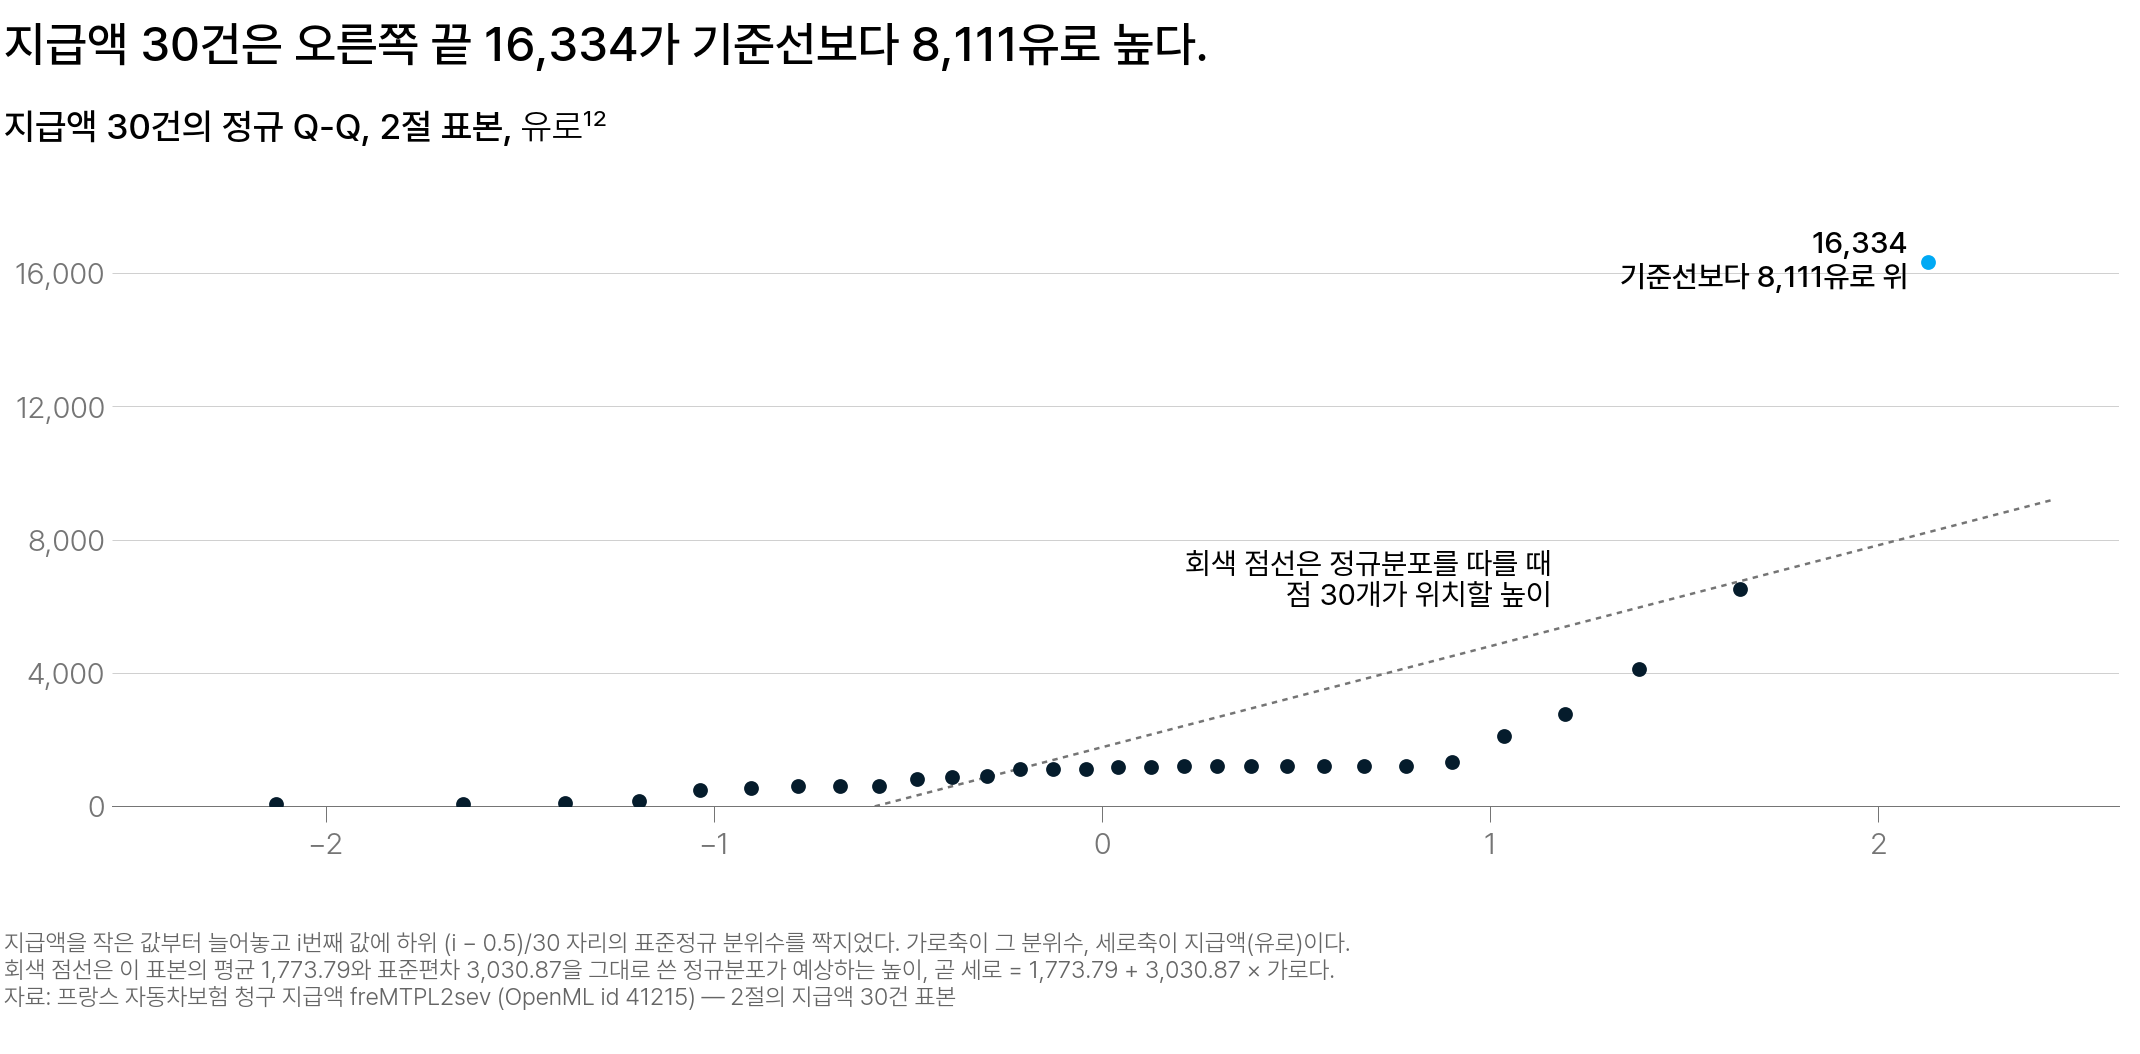

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 앞(2. 부트스트랩) 지급액 30건을 정규분포에 견준 Q-Q 그림 — 맨 오른쪽 16,334유로 한 점이 회색 기준선보다 8,111유로 위에 있다.</em></p>

왼쪽 끝 78유로가 회색 기준선보다 4,754유로 위, 오른쪽 끝 16,334유로가 8,111유로 위이고, 작은 쪽 13번째부터 29번째까지 17점은 선 아래에 놓입니다. 양 끝이 기준선보다 높고 가운데가 낮은 이 곡률이 **오른쪽으로 긴 꼬리**의 특징적 신호입니다. **그래서** 좌우 대칭인 $\bar{x} \pm 1.96\,s/\sqrt{30}$ 는 $[689.2,\ 2{,}858.4]$ 를 주는데, 앞(2. 부트스트랩)의 부트스트랩 구간은 왼쪽 829.3·오른쪽 1,296.2로 오른쪽이 훨씬 넓습니다 — 아래끝이 255 만큼 차이가 납니다.

## ② 등분산성 — 건수 데이터에서 이분산이 갖는 의미

**이분산(heteroscedasticity)** — 잔차의 산포가 예측값에 따라 달라지는 상태입니다. 최소제곱에서는 결함이지만 포아송 회귀는 **평균이 커지면 분산도 커진다**고 선언한 모형이라 여기서는 설계입니다. 눈으로 볼 모양은 앞 접힘의 둘째 장, 오른쪽으로 갈수록 부채처럼 넓어지는 그림입니다. 그래서 잔차도 단순 차이 대신 건수 데이터 전용 잔차를 씁니다.

**이탈도(deviance)** $D$ — 관측을 완벽히 맞힌 모형과 우리 모형의 로그우도 차이를 두 배 한 값입니다. 못 맞춘 총량이라 작을수록 좋고, 0 이면 모든 관측을 정확히 맞힌 경우입니다.

**이탈도 잔차(deviance residual)** — 총량 $D$ 를 관측별로 분해한 기여분에 부호를 부여한 값입니다. 제곱해 모두 더하면 다시 $D$ 가 됩니다. 지금부터 $r_i$ 는 이 잔차를 뜻합니다.

$$
r_i = \operatorname{sign}(y_i - \hat{\mu}_i)\,\sqrt{2\left[\,y_i \log \frac{y_i}{\hat{\mu}_i} - (y_i - \hat{\mu}_i)\right]}
$$

- $y_i$ : 그 계약의 사고 건수
- $\hat{\mu}_i$ : 모형이 그 계약에 준 기대 건수 — 노출(보장을 받은 기간)을 반영한 값
- 제곱근 안 : 그 계약이 전체 이탈도에 보탠 기여분. 앞의 부호는 실제가 예측보다 많았으면 $+$, 적었으면 $-$ 다

<details class="lms-extra"><summary>자세히 — 이탈도 잔차의 대입 계산과 피어슨 잔차와의 대비</summary>

**사고가 없던 계약을 대입해 봅니다.** 위 식의 제곱근 안, 곧 이탈도 기여분 $d_i$ 의 $y_i$ 자리에 0 을 넣습니다.

$$
d_i = 2\left[\, 0 \cdot \log \frac{0}{\hat{\mu}_i} - (0 - \hat{\mu}_i)\right]
$$

앞 항은 $y\log y$ 를 0 으로 두기로 한 자리라 지웁니다. 뒤 항은 대괄호 안의 빼기가 $-\hat{\mu}_i$ 의 부호를 바꾸어 $+\hat{\mu}_i$ 를 남깁니다.

$$
d_i = 2\hat{\mu}_i
$$

부호는 제곱근 앞에 따로 붙습니다. 관측 0 이 예측 $\hat{\mu}_i$ 보다 작으니 $\operatorname{sign}(0 - \hat{\mu}_i) = -1$ 입니다.

$$
r_i = -\sqrt{d_i} = -\sqrt{2\hat{\mu}_i}
$$

검산. $\hat{\mu}_i$ 자리에 기대 건수 0.05 를 넣습니다.

$$
-\sqrt{2 \times 0.05} = -\sqrt{0.10} = -0.3162
$$

소수 둘째 자리로 −0.32 입니다. 계약 678,013건이 이런 값들이라 산포, 곧 표준편차가 0.54 입니다.

**피어슨 잔차와 비교하면 척도가 달라집니다.** 건수 데이터에서는 평균이 커질수록 산포도 커져 「관측 − 예측」을 그대로 쓰기 어렵습니다. 그래서 잔차를 해당 관측의 표준편차로 나누어 척도를 맞추는데, 그 첫 번째가 **피어슨 잔차(Pearson residual)** 입니다.

$$r_i^{P} = \frac{y_i - \hat{\mu}_i}{\sqrt{V(\hat{\mu}_i)}}$$

- $y_i$ : 관측값 · $\hat{\mu}_i$ : 그 관측에 대한 모형의 예측 평균
- $V(\hat{\mu}_i)$ : 분산함수 — 포아송이면 $\hat{\mu}_i$, 이항이면 $\hat{\mu}_i(1-\hat{\mu}_i)$

두 자리에 값을 대입해 봅니다. 예측 $\hat{\mu} = 0.05$ 인 계약에서 사고가 1건 났다면 $r^{P} = (1 - 0.05)/\sqrt{0.05} = 4.25$ 이고, 예측 $\hat{\mu} = 2.0$ 인 계약에서 3건이 났다면 $r^{P} = (3 - 2.0)/\sqrt{2.0} = 0.71$ 입니다. 같은 두 경우를 이탈도 잔차로 계산하면 $+2.02$ 와 $+0.66$ 이 나옵니다. 곧 피어슨이 4.25 대 0.71 로 벌려 놓았던 두 경우를 이탈도 잔차는 2.02 대 0.66 으로 좁혀 잡습니다. 예측이 아주 작은 구간에서 피어슨이 크게 튀는 이 성질은, 이 절 뒤에서 $\hat{\varphi}$ 를 두 방식으로 계산할 때 그대로 다시 나타납니다.

**그림으로 볼 때의 주의도 하나.** 사고 0건이 95%인 우리 계약에서는 잔차를 적합값에 대해 찍은 표준 진단 그림이 잘 맞지 않습니다. 계약 20,000건을 무작위로 뽑아 찍으면 점이 무작위로 흩어지지 않고 곡선 3개로 나뉘어 분포합니다 — 적합값 0.05 에서 세로로 확인하면 잔차가 −0.32 · 2.02 · 3.29 세 값에만 찍히는데, 그 계약이 사고를 0건·1건·2건 냈는지가 위치를 정하기 때문입니다. 맨 아래 곡선에 표본의 95% 가 놓이고 사고 0건 곡선은 가장 낮은 값이 −0.72 라 −2 아래로 내려간 점이 없으니, ±2 어림도 여기서는 통하지 않습니다. 그래서 건수 데이터 모형에서는 잔차 그림의 모양 대신 **평균과 분산의 관계**를 직접 봅니다 — 바로 다음에 할 일입니다.

</details>

### 과산포 — 평균은 일치하고 산포만 큰 상태

포아송이 전제하는 것은 $\operatorname{Var}(Y) = \mu$ 하나입니다. 실제 분산이 그 기대값의 몇 배인가를 $\varphi$(파이)라 두면 다음과 같이 적을 수 있습니다.

$$\operatorname{Var}(Y) = \varphi\,\mu$$

**산포 모수(dispersion parameter) $\varphi$** — 실제 분산이 포아송이 전제한 평균의 몇 배인지 나타내는 값입니다. $\varphi = 1$ 이면 전제대로이고, $\varphi > 1$ 이면 산포가 전제보다 큰 **과산포(overdispersion)** 입니다.

전체 평균 0.0532 와 전체 분산 0.0566 을 한 번 맞대는 것으로는 부족합니다. 둘을 나눈 $0.0566 \div 0.0532 = 1.06$ 은 뒤에서 채택할 값과 같은 숫자입니다. 그런데 전체를 한 덩어리로 한 번 계산한 값이라 **그 1.06 이 우연히 나온 것인지 구간마다 되풀이되는 것인지를 구분해 주지 못합니다.**

그 구분은 다음 그림이 해 줍니다. 계약 678,013건을 예측값 순으로 **15개 구간** 으로 나눠 구간마다 실제 평균과 실제 분산을 대조하면, 15개가 모두 1 위쪽인지 1 위아래로 흩어지는지가 보입니다.

여기서 자른 구간은 앞(1. 표준오차)의 접힘에서 히스토그램의 계급구간을 설명할 때와 자르는 규칙이 다릅니다. **앞과 달리 여기서는 값의 범위가 아니라 구간에 든 계약 수를 같게(45,200건씩) 잘랐습니다.**

예측값이 낮은 쪽에 계약이 몰려 있어 같은 간격으로 자르면 구간 하나에 계약이 몇 건뿐인 자리가 생기고 그런 구간의 분산은 믿을 수 없습니다.

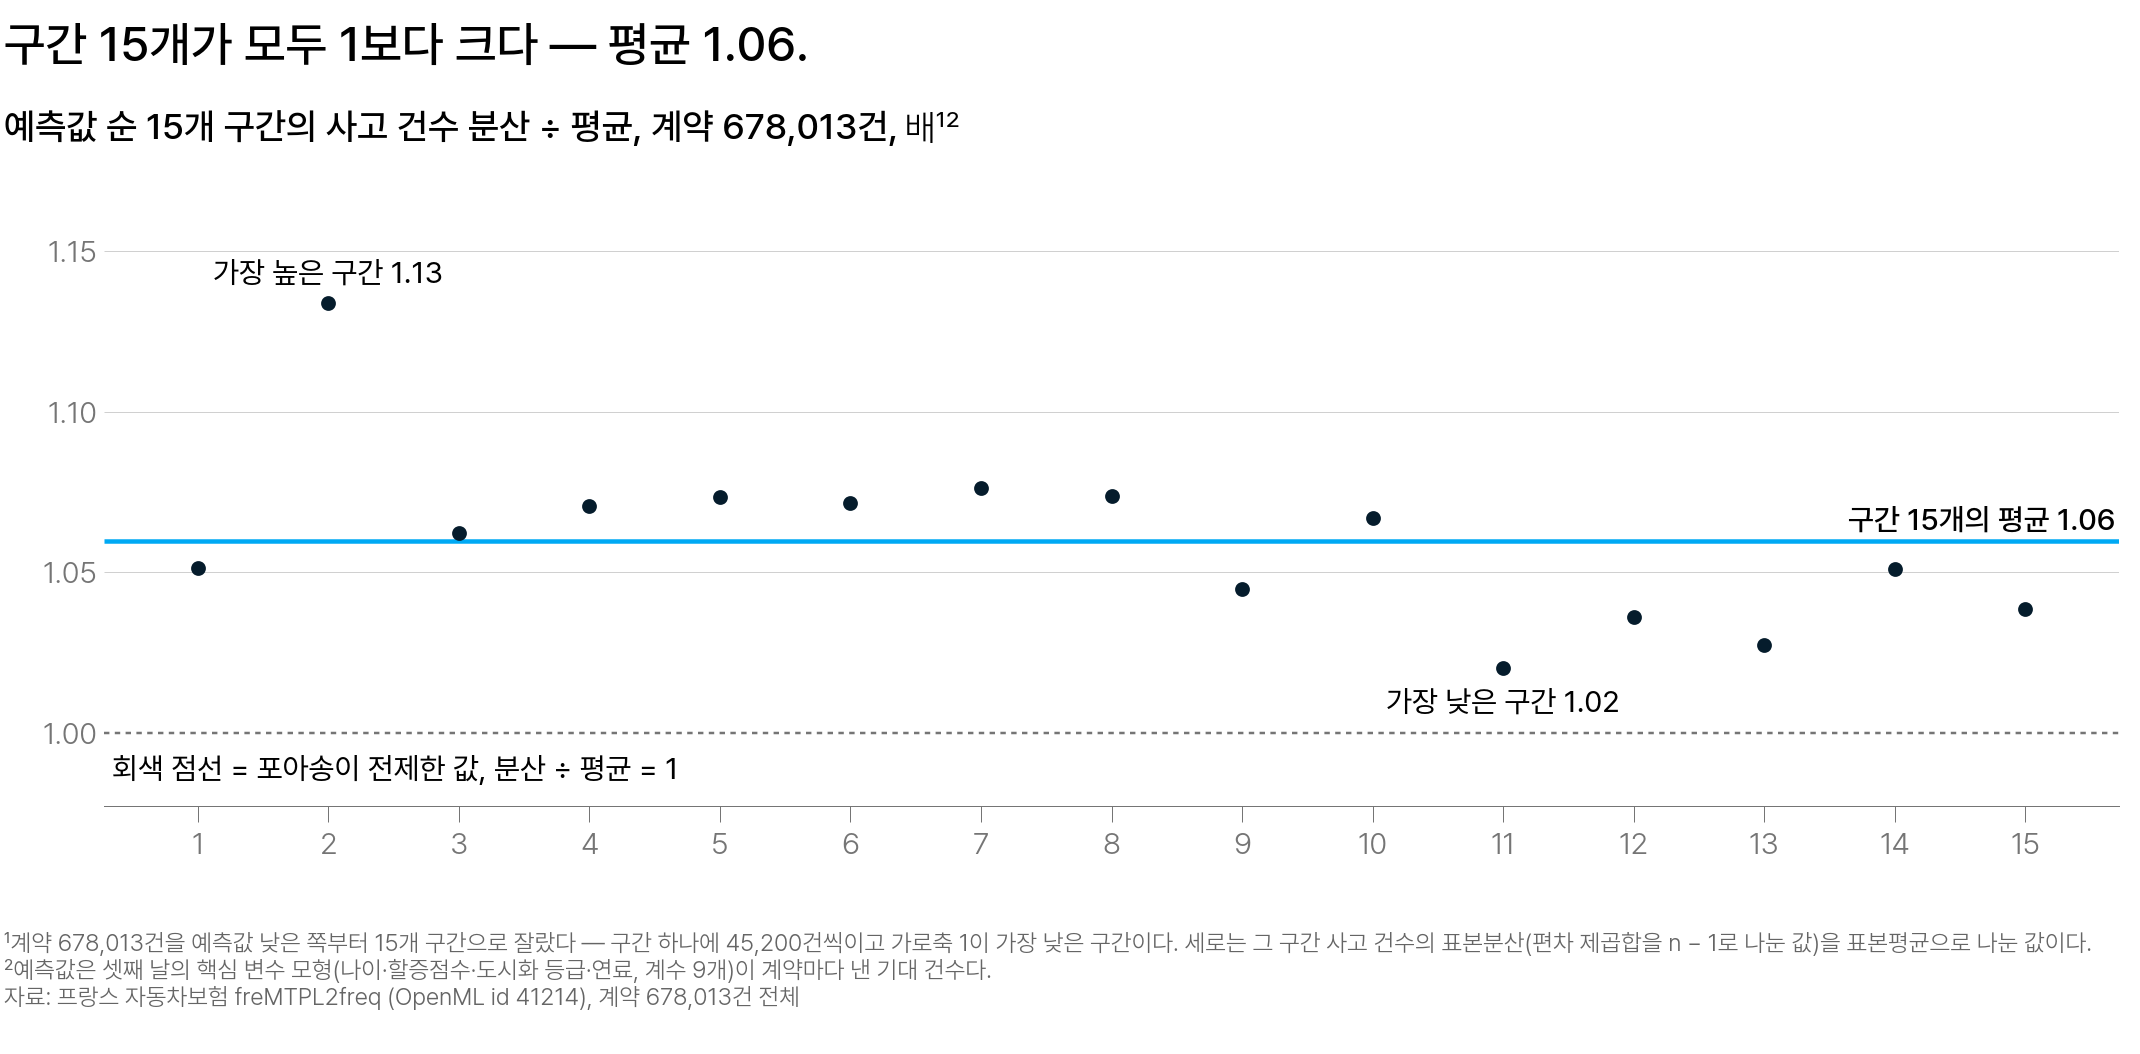

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계약 678,013건을 예측값이 낮은 쪽부터 15개 구간으로 잘라 구간마다 사고 건수의 분산 ÷ 평균을 찍은 그림 — 남색 점 15개가 회색 점선으로 표시한 1 아래로는 하나도 내려오지 않고 1.02 ～ 1.13 사이에만 분포해, 하늘색 가로선으로 그은 평균이 1.06이다.</em></p>

구간마다의 분산 ÷ 평균은 1.02에서 1.13 사이, 평균 **1.06** 입니다. 우연이라면 1 위아래로 흩어졌을 텐데 **구간 15개가 모두 1 위쪽**입니다 — 작지만 체계적인 과산포입니다. 이 권은 $\hat{\varphi} = 1.06$ 을 우리 데이터의 값으로 씁니다.

분산이 $\varphi$ 배면 표준오차는 그 제곱근만큼 커지므로, 포아송 가정으로 계산한 표준오차는 실제보다 $\sqrt{1.06} = 1.03$ 배 좁게 나옵니다. 계산해 둔 표준오차에 1.03 을 곱해 읽으라는 뜻입니다. 계수 판정은 추정값 $\pm 2\,\text{SE}$ 가 0 을 포함하는지로 판정하는데, 표준오차를 1.03배로 넓혀 다시 판정해도 셋째 날 확장 모형의 계수 41개 가운데 결론이 바뀐 것은 없었습니다.

**그래서** 6% 과산포는 **고쳐 읽되 결론은 그대로**인 크기입니다. 다만 $\hat{\varphi}$ 는 어느 계산으로 냈는지에 따라 값이 크게 달라집니다. 같은 데이터라도 짧은 노출을 그대로 둔 채 피어슨 잔차 제곱합을 자유도로 나누면 **2.83** 이 나오는데, 그 합의 49%를 기여가 가장 큰 계약 1,000건이 만듭니다 — 노출이 하루뿐인 계약에 사고가 2건 나면 예측이 0.0002 아래라 항 하나가 2만을 초과하기 때문입니다. 노출 0.2년 이상인 계약 499,171건만 다시 더하면 1.06 으로 15개 구간 방식과 같은 값이고, 같은 일을 이탈도로 하면 **0.32** 로 1 보다 한참 아래입니다. 사고 0건이 95%인 자료에서는 피어슨은 위로 튀고 이탈도는 아래로 눌립니다. 이 권은 짧은 노출을 뺀 1.06 을 쓰고 2.83 을 나란히 적어 둡니다 — 사고 건수가 드문 데이터에서 $\hat{\varphi}$ 는 **어느 계산으로 냈는지를 함께** 밝히는 것이 규칙입니다.

$\varphi$ 가 더 컸을 때를 확인합니다. 평균 4·분산 8인 과산포 데이터를 관측 200개씩 1,000벌 생성해, 포아송 가정으로 계산한 표준오차와 추정값이 실제로 달라진 정도를 비교합니다. 평균 4 는 우리 계약의 기대 건수 0.0532 보다 훨씬 큰 값이지만, 여기서 읽을 것은 절대 크기가 아니라 **배수** 입니다.

> **[예측] 분산이 평균의 2배인 자료에서, 추정값이 실제로 달라진 정도는 포아송 가정으로 계산한 표준오차의 몇 배이겠습니까?**
>
> 1. 거의 같다 — 1.0배 근처
> 2. 조금 크다 — 1.4배 근처
> 3. 훨씬 크다 — 3배 근처
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

In [ ]:
# 과산포가 있을 때 포아송 가정으로 계산한 표준오차는 실제 산포와 얼마나 다른가
import numpy as np

rng = np.random.default_rng(20260829)
MU, N_OBS, N_REP = 4.0, 200, 1000        # 평균 4, 관측 200개, 1000벌 반복
SHAPE = 4.0                              # 감마 혼합의 형상 모수 r -> 분산 = MU + MU^2/SHAPE = 8

mu = rng.gamma(SHAPE, MU / SHAPE, size=(N_REP, N_OBS))    # 계약마다 다른 기대 건수
y = rng.poisson(mu)                                       # 그 기대값에서 나온 사고 건수

print(f"만들어진 자료 : 평균 {y.mean():.3f} · 분산 {y.var():.3f} "
      f"(분산/평균 = {y.var() / y.mean():.2f})")

est = y.mean(axis=1)                                      # 벌마다의 평균 사고 건수 추정값 μ̂
se_naive = np.sqrt(est / N_OBS)                           # 포아송 가정이 전제하는 표준오차
sd_real = est.std(ddof=1)                                 # 1000개 추정값의 실제 산포

print(f"포아송 가정의 표준오차      : {se_naive.mean():.4f}")
print(f"추정값의 실제 산포        : {sd_real:.4f}")
print(f"실제 / 가정의 값            : {sd_real / se_naive.mean():.3f} 배")

cover = np.mean(np.abs(est - MU) < 1.96 * se_naive)       # 95% 라 부른 구간의 실제 적중률
print(f"95% 라 부른 구간의 적중률   : {cover * 100:.1f}%")

#### 결과 해석

자료는 평균 4.006 · 분산 8.056 이라 분산 ÷ 평균이 2.01 입니다. 포아송 가정으로 계산한 표준오차는 **0.1415** 인데 실제로 달라진 정도는 **0.2056**, 그 값의 **1.453배**입니다 — **예측 질문의 답은 「조금 크다 — 1.4배 근처」**입니다. 그 좁은 표준오차로 만든 "95% 구간" 의 실제 적중률은 **82.4%** 로, 95회 적중하도록 만든 구간이 82회만 적중합니다.

배수가 $\sqrt{\varphi}$ 인 것은 표준오차가 분산의 제곱근 척도이기 때문입니다 — 분산이 4 에서 8 로 2배가 되면 표준오차는 $\sqrt{8/200} \div \sqrt{4/200} = \sqrt{2} = 1.414$ 배가 되고, 1,000벌에서 실제로 계산한 1.453 은 반복을 늘리면 그 1.414 에 수렴합니다. 이 모의실험은 노출을 1년으로 고정한 설정이라 연간 사고율 $\lambda$ 와 기대 건수 $\mu$ 가 같은 값입니다. 그래서 위 카드는 둘을 구분하지 않고 $\hat{\mu}$ 하나로 씁니다. 우리 데이터의 $\varphi = 1.06$ 에 같은 규칙을 대면 $\sqrt{1.06} = 1.03$, 곧 3% 넓혀 읽으라는 지시 하나로 정리됩니다.

## ③ 독립성 — 이 데이터에서 가장 조심할 항목

같은 계약자가 차량 2대를 계약했다면 두 계약의 사고는 독립이 아니고, 같은 지역의 계약들도 날씨·도로 사정을 공유합니다. 우리 데이터에는 계약자 ID 가 없어 실제로 묶어 보는 것은 **지역**입니다.

- **군집(cluster)** — 같은 계약자·같은 지역처럼 관측이 한 덩어리로 묶이는 단위입니다.
- **군집 표준오차(cluster standard error)** — 같은 군집 안의 관측이 함께 움직인다는 것을 인정해 표준오차를 군집 단위로 다시 계산하는 방법입니다. 계수는 그대로 두고 표준오차만 다시 계산합니다.

잔차를 군집별로 모아 **군집 안 평균**을 하나씩 찍어 보면 됩니다. 독립이면 0 주위에 무작위로 흩어지지만, 얽혀 있으면 어떤 군집은 통째로 $+$쪽, 어떤 군집은 통째로 $-$쪽으로 뭉칩니다.

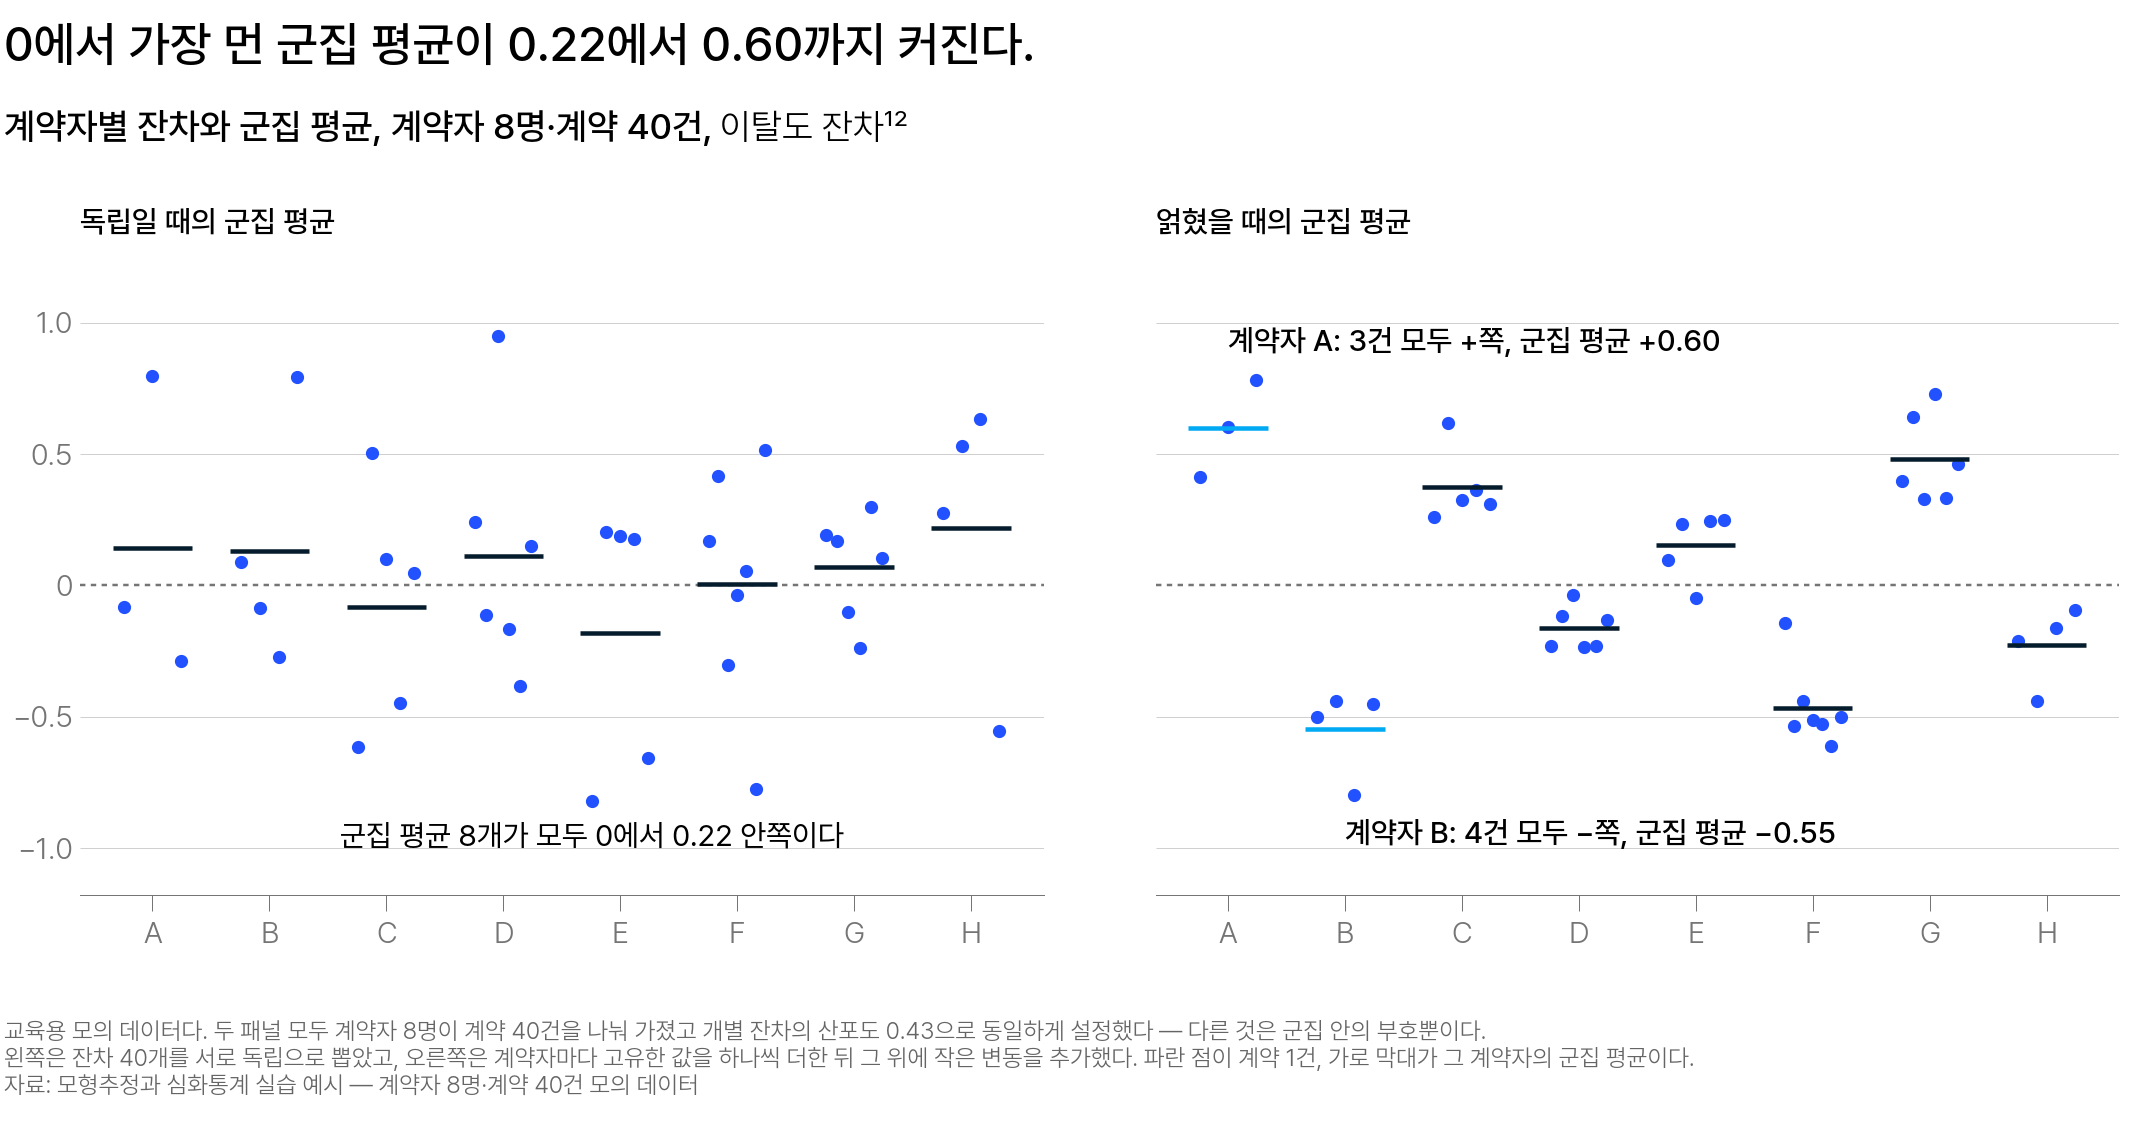

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 잔차를 계약자로 묶어 군집 평균을 찍은 그림 — 개별 잔차가 흩어진 정도는 두 패널 모두 0.43으로 같은데, 왼쪽(독립)의 군집 평균 8개는 0 에서 0.22 이내인 반면 오른쪽(얽힘)은 계약자 A가 +0.60·B가 −0.55까지 이동했다.</em></p>

달라진 것은 산포의 크기가 아니라 군집 안에서 부호가 한쪽으로 몰리는지 여부입니다.

오른쪽 패널은 계약자마다 고유값을 하나씩 더해 만들었습니다. 여기서 숫자가 2가지 역할로 나뉩니다. **고유값**은 그 계약자의 계약 전부에 통째로 더한 **입력값**이라 A 가 $+0.62$, B 가 $-0.55$ 입니다. **군집 평균**은 그 위에 작은 변동이 더해진 뒤 실제로 **관측된 값**이라 A 가 $+0.60$, B 가 $-0.55$ 입니다. B 는 두 값이 소수 둘째 자리에서 같아 보일 뿐이고, 역할은 A 처럼 서로 다릅니다.

오른쪽 같은 뭉침이 보이면 그 군집은 사실상 관측 한 건에 가까워, 계약 수보다 유효 표본 수가 적습니다.

같은 일을 계약 678,013건에 댑니다. 모형은 셋째 날의 핵심 변수 모형이고, 변수 4개는 나이·할증점수·도시화 등급·연료이고, 계수는 9개입니다. 그 모형의 이탈도 잔차를 지역 22개로 묶어 군집마다 평균을 하나씩 냅니다. 같은 잔차를 크기가 같은 22개 군집에 무작위로 1,000번 흩어 얻은 군집 평균의 가운데 95%를 회색 범위로 표시했습니다. 지역 이름을 떼고 다시 배치해도 남는 그 변동 범위까지가 우연으로 설명되는 한계입니다.

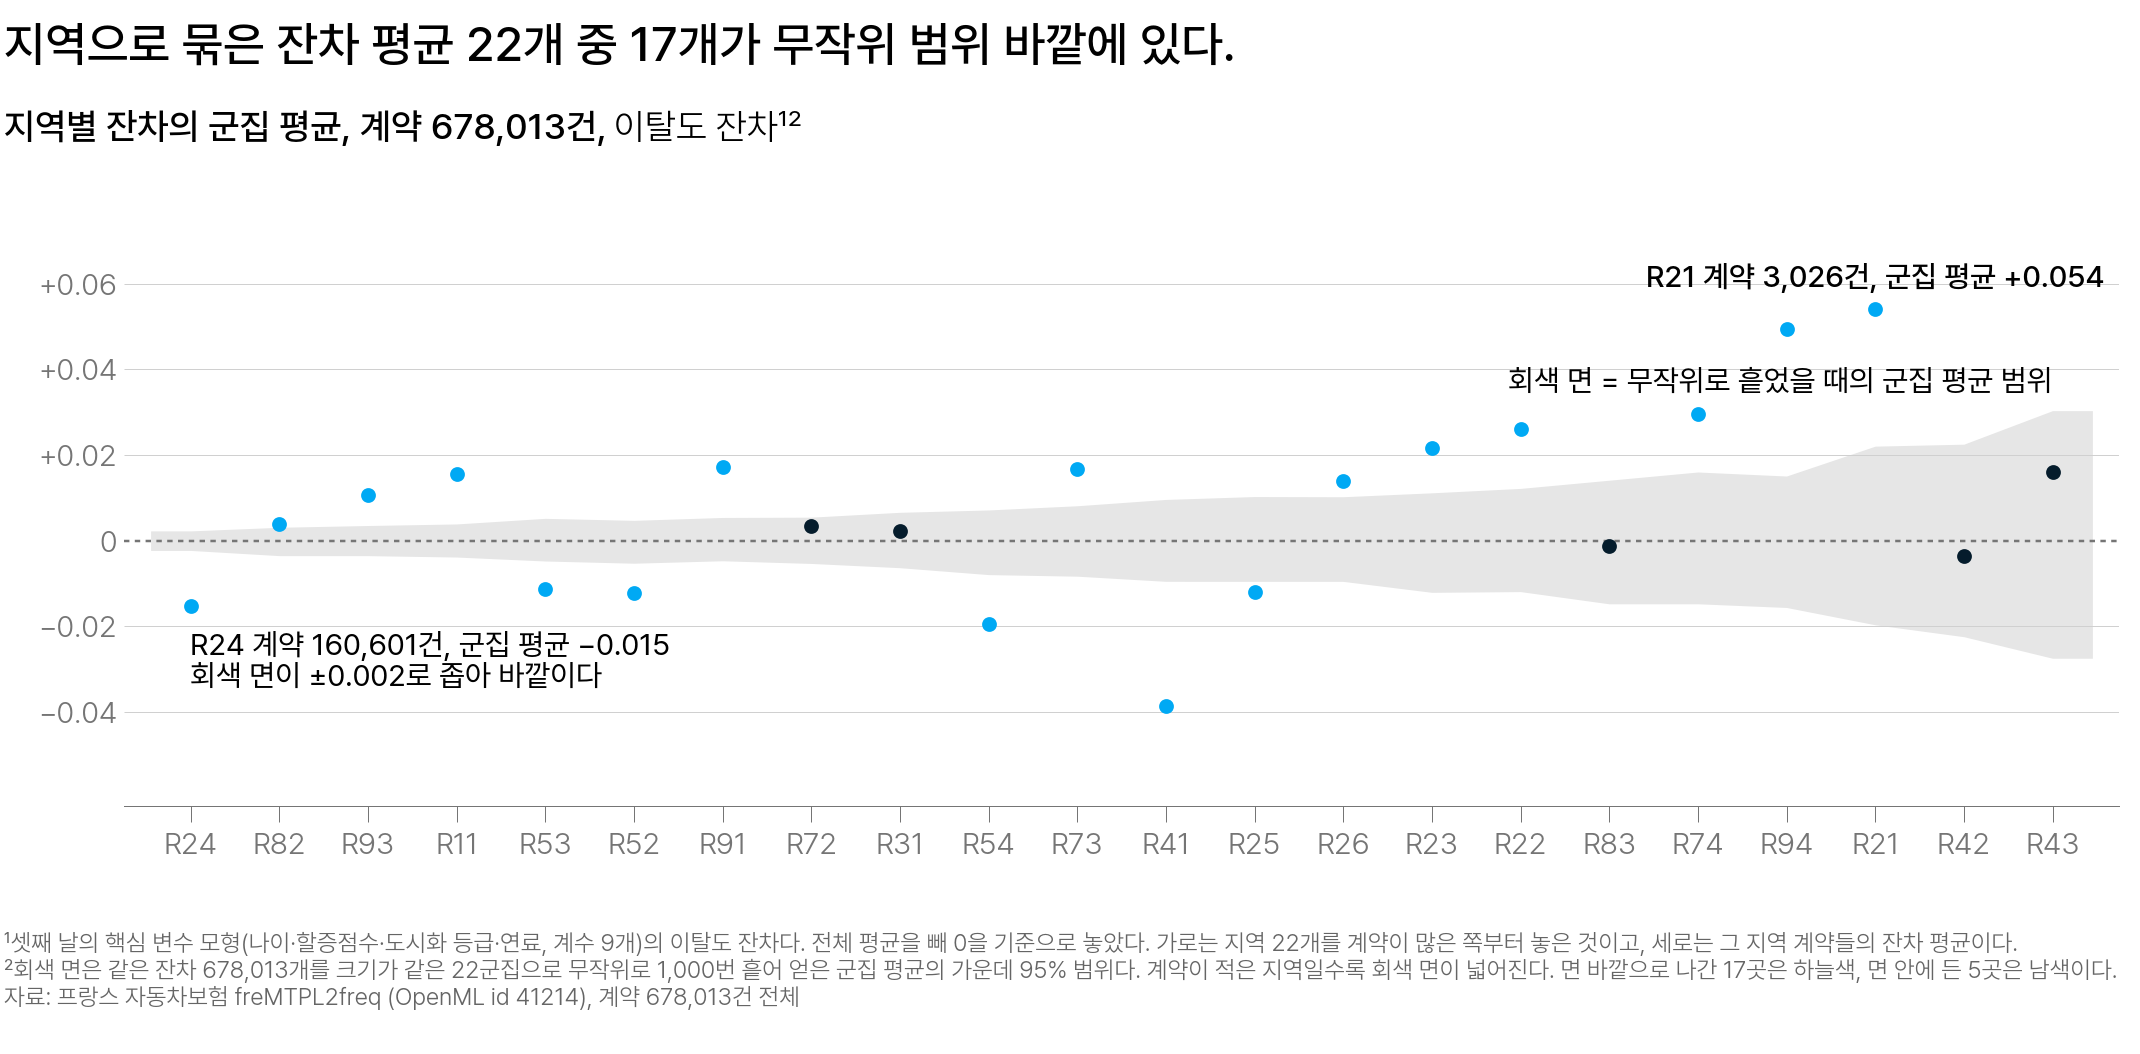

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계약 678,013건의 이탈도 잔차를 지역 22개로 묶은 군집 평균 — 22개 군집 중 17개(하늘색)가 무작위 범위 바깥에 있다.</em></p>

#### 결과 해석

무작위 범위의 길이를 정하는 것은 군집 평균의 크기가 아니라 그 군집에 속한 계약 수입니다. 계약 160,601건인 **R24** 는 그 범위가 $\pm 0.0023$ 밖에 안 돼, 군집 평균 $-0.0153$ 이 범위 끝의 6.7배 바깥입니다. 계약 1,326건뿐인 **R43** 은 범위가 $-0.0274$ ～ $+0.0303$ 으로 넓어, 절댓값이 더 큰 $+0.0160$ 인데도 그 안에 들어옵니다.

전체로 세면 **22개 군집 중 17개가 밖**입니다. 지역 이름에 아무 뜻도 없었다면 $22 \times 0.05 = 1.1$개 정도여야 하는데, 17개는 그 15배가 넘습니다.

이 군집 구조가 구간 길이를 얼마나 바꾸는지 확인합니다. 같은 모형을 앞에서 정의한 군집 표준오차로 계산해 봤습니다.

| 계수 | 포아송 표준오차 | 군집 표준오차 | 배수 |
|---|---|---|---|
| 할증점수 | 0.00031 | 0.00163 | 5배 넘게 |
| 운전자 나이 | 0.00039 | 0.00241 | 6배 |

도시화 등급 쪽 계수들은 배수가 1.2 안팎이거나 오히려 조금 줄었습니다.

**그래서** 오늘 구간을 가장 크게 변화시키는 것은 과산포가 아니라 독립성입니다. 산포를 고치는 쪽이 표준오차를 3% 변화시킨 것과 비교하면 5～6배는 자릿수가 다르고, 계수마다 배수가 달라 1.03 처럼 한 숫자를 곱해 읽을 수도 없습니다. 과산포는 관측 하나하나의 산포 문제지만 뭉침은 **유효 표본 수**의 문제라, 배수 보정으로는 제거할 수 없습니다. 다만 군집 표준오차는 군집 수가 많아야 안정되는 방법입니다 — 우리 군집은 22개뿐이라 5～6배라는 배수 자체도 어림입니다.

<details class="lms-extra"><summary>자세히 — 그림의 작성 절차 3단계와 군집이 22개뿐일 때의 한계</summary>

⑴ 셋째 날의 **핵심 변수 모형**을 계약 678,013건에 적합하고 이탈도 잔차를 산출합니다. 지역은 이 모형에 들어 있지 않습니다 — 지역을 포함시키면 지역 차이가 계수로 흡수돼 잔차에 남지 않으니, 남았는지를 보려면 빼 두어야 합니다. 이탈도 잔차는 뺄셈 잔차와 달리 전체 평균이 0 이 아니라, 그 평균을 빼고 0 을 기준으로 삼습니다.

⑵ 그 잔차를 지역 22개로 묶어 군집마다 평균을 하나씩 냅니다. 이것이 그림에 찍힌 점입니다. 식으로 적으면 다음과 같습니다.

$$
\bar{r}_g = \frac{1}{n_g} \sum_{i \in g} \left( r_i - \bar{r} \right)
$$

- $g$ : 군집 하나 — 여기서는 지역 22개 중 1곳
- $n_g$ : 그 지역에 든 계약 수 — 가장 많은 R24 가 160,601, 가장 적은 R43 이 1,326
- $r_i$ : $i$번째 계약의 이탈도 잔차
- $\bar{r}$ : 잔차 678,013개 전체의 평균 — 이탈도 잔차는 이 값이 0 이 아니라 1번 빼 줍니다
- $\bar{r}_g$ : 그 지역 잔차의 평균, 곧 점 하나의 높이

⑶ 같은 잔차 678,013개를 **크기가 같은 22개 군집에 무작위로** 1,000번 흩습니다. 그때 나온 군집 평균의 가운데 95% 범위가 회색 면입니다. 군집에 든 계약이 많을수록 평균이 덜 변동하므로, 회색 면은 계약이 많은 왼쪽에서 좁고 적은 오른쪽으로 갈수록 넓어집니다.

**군집 표준오차는 무엇을 군집 단위로 더하나.** 같은 지역의 계약들은 도로 사정과 날씨를 함께 겪어 사고 여부가 서로 닮아 있고, 그만큼 독립된 정보는 계약 수보다 적게 들어옵니다. 보통의 표준오차는 계약 하나하나가 낸 기여를 따로 제곱해 더합니다. 군집 표준오차는 **같은 지역에 속한 기여를 먼저 전부 더해 지역마다 합을 하나씩 만든 뒤**, 그 합 22개를 제곱해 더합니다.

군집 안에서 먼저 합치고 그다음에 제곱해 더하는 순서입니다. 순서만 바뀌는데도, 군집 안에서 부호가 한쪽으로 몰려 있으면 먼저 더할 때 상쇄되지 않고 그대로 누적돼 값이 커집니다.

**유효 표본 수가 줄어드는 이유.** 한 지역의 계약들이 서로 함께 움직이면 그 지역이 보태는 독립된 정보는 계약 수만큼이 아닙니다. 군집 안 상관을 $\rho$, 군집 크기를 $m$ 이라 두면 분산에 곱해지는 배수가 $1 + (m - 1)\rho$ 이고, 유효 표본 수는 계약 수를 그 배수로 나눈 값입니다.

검산: R24 의 $m = 160{,}601$ 에 $\rho$ 가 0.0001 만 되어도 배수가 17.1 이고, 표준오차는 그 제곱근인 4.1배가 됩니다. 같은 방식으로 $\rho$ 가 커지면 배수도 커져, $\rho$ 가 0.0002 면 배수가 33.1 이고 표준오차는 5.8배입니다.

**지역을 모형에 포함하면 되지 않나.** 맞습니다. 셋째 날의 확장 모형이 바로 지역 22개 수준을 계수 21개로 전개해 포함한 모형입니다. 지역처럼 수준이 22개뿐인 군집은 계수로 흡수해 평균 차이를 걷어 낼 수 있습니다. 문제가 되는 것은 계약자 쪽입니다 — 이 데이터에는 계약자 ID 가 아예 없고, 있다 해도 계약자 수가 계약 수에 가까우면 계수로 전개할 수 없습니다. 군집을 계수로 흡수할 수 없을 때 남는 길이 **검증용 조각을 군집 단위로 나누고 군집 표준오차를 사용하는 것** 입니다(조각 나누기는 뒤(6. 정규화와 교차검증)에서 다룹니다). 계약자마다 절편을 하나씩 더 두는 혼합효과 모형이 그다음입니다.

그림에서 0 에서 가장 멀리 벗어난 군집도 확인해 둡니다. 계약 3,026건인 R21 의 $+0.054$ 로, 그 군집의 범위 위끝 $+0.022$ 의 2.5배입니다. 아래로 가장 멀리 나간 군집은 계약 12,990건인 R41 의 $-0.039$ 입니다. 본문에 적어 둔 「배수 자체도 어림」 의 기준도 여기서 나옵니다 — 실무에서는 군집 수가 40～50개는 되어야 군집 표준오차를 신뢰할 수 있습니다.

</details>

## 잔차 그림의 유형별 대응 — 산포·형태·군집

- 산포가 달라졌으면 표준오차 계산식을 수정합니다 — 강건·군집 표준오차, 또는 분산에 모수를 하나 더 두는 준포아송입니다.
- 형태가 남았으면 모형의 설명변수 부분(선형예측자)을 수정합니다 — 2차항을 넣거나 구간으로 자르는 것입니다.
- **군집 안에서 부호가 뭉쳤으면** 검증용 조각을 군집 단위로 다시 나눕니다 — 그 조각을 폴드라 부르며 뒤(6. 정규화와 교차검증)에서 정의합니다.

과산포를 발견했을 때 첫째 항목에서 고를 수 있는 길은 셋입니다.

| 대응 | 무엇을 바꾸나 | 언제 쓰나 |
|---|---|---|
| **준포아송** | 분산을 $\varphi\mu$ 로 두고 표준오차에 $\sqrt{\hat{\varphi}}$ 를 곱한다. 계수는 그대로 | $\hat{\varphi}$ 가 1 에서 조금 벗어난 경우 — 우리 데이터의 1.06 이 여기 |
| **음이항** | 분산을 $\mu + \mu^2/r$ 로 두고 모수 $r$ 을 함께 추정한다 | 산포가 크고 그 구조까지 모형에 담고 싶을 때 |
| **강건(HC) 표준오차** | 분산 형태를 가정하지 않고 표준오차만 다시 계산한다 | 산포의 형태를 신뢰하기 어려울 때 |

진단은 셋 다 그림이 먼저이고 검정은 보조입니다. 오늘 만든 구간 셋, 곧 앞(2. 부트스트랩)의 부트스트랩 구간과 앞(3. 신뢰구간)의 신뢰구간과 앞(4. 신뢰구간을 이용한 의사결정)의 신용구간은 전부 이 진단을 통과한 뒤에야 보고서에 올라갈 수 있습니다.

#### 핵심 주의점

$\hat{\varphi} = 1.06$ 을 "표준오차를 1.06배로 넓히라" 로 해석하면 안 됩니다.

$$
\operatorname{Var}(Y) = \varphi\,\mu
$$

$\varphi$ 가 곱해지는 대상은 분산이고 표준오차는 그 제곱근 척도라, 넓히는 배수는 $\sqrt{1.06} = 1.03$ 입니다. 따라서 "과산포가 6% 니 구간도 6% 넓어진다" 는 틀린 문장입니다.

정확한 뜻은 다음과 같습니다.

> **분산이 포아송이 전제한 평균의 1.06배라는 뜻이고, 받아 든 표준오차는 그 제곱근인 1.03배 곧 3% 넓혀 읽는다.**

> 점추정은 가정이 성립하지 않아도 크게 달라지지 않지만 구간은 달라지고, 우리 데이터에서 구간을 가장 크게 변화시키는 것은 과산포 6%가 아니라 지역으로 뭉친 잔차입니다.

> 다만 그 5～6배를 앞(4. 신뢰구간을 이용한 의사결정)의 신용구간에 그대로 옮겨 써도 되는지는 오늘 검증하지 않았습니다 — 회귀계수에서 나온 배수라, 같은 절차를 두 지역의 차이에 직접 적용해야 답이 나옵니다.

> **[문제] φ 증가에 따른 적중률 82.4% 의 변화**
>
> 앞의 시뮬레이션 카드가 만든 자료는 $\varphi = 2.01$ 에서 "95%"라 부른 구간의 실제 적중률이 82.4% 였습니다. 포아송 가정으로 만든 $\pm 1.96\,\mathrm{SE}$ 구간은 실제 척도로는 $\pm 1.96/\sqrt{\varphi}$ 짜리 구간이라는 점을 써서, (1) 같은 실험을 $\varphi = 4$ 로 실행하면 그 구간이 실제로 몇 %를 맞힐지 표준정규분포 표에서 찾아 어림하고, (2) 반대로 적중률이 90% 아래로 내려가지 않으려면 $\varphi$ 가 얼마 이하여야 하는지 구한 뒤, (3) 우리 데이터의 $\hat{\varphi}$ 를 1.06 으로 보고하느냐 짧은 노출을 그대로 둔 2.83 으로 보고하느냐에 따라 그 판정이 달라지는지 한 문장으로 적습니다. (표가 없으면 코드 셀에서 `from scipy.stats import norm` 뒤 `2 * norm.cdf(0.98) - 1` 로 바로 읽어도 됩니다. 반대로 넓이에서 임계값을 되찾을 때는 `norm.ppf(0.95)` 를 씁니다.)

둘째 문항은 같은 보정을 셋째 날 확장 모형의 계수 하나에 적용해 봅니다 — 6% 보정이 판정을 바꾸는지, 그리고 뭉침이 남아 있을 때 그 보정만으로 충분한지 확인합니다.

> **[문제] 과산포 6% 와 군집 상관의 구간 반영 구분**
>
> 셋째 날 확장 모형을 계약 678,013건에 적합했더니 지역 R74 의 계수가 추정값 +0.1465, 포아송 가정으로 계산한 표준오차 0.0658 로 나왔습니다. (1) 6% 과산포를 반영해 이 표준오차를 고쳐 쓰고, 고치기 전과 후의 추정값 $\pm 2\,\text{SE}$ 구간을 각각 소수 넷째 자리까지 계산합니다. (2) 두 구간이 0 을 품는지 따져 이 계수의 판정이 바뀌는지 쓰고, 바뀌지 않는다면 판정이 반대가 되려면 분산 ÷ 평균이 얼마까지 커져야 하는지도 구합니다. (3) 앞 그림에서 R24 는 계약 160,601건에 군집 평균 −0.0153 이라 무작위 범위(±0.0023) 바깥이고, R43 은 계약 1,326건에 군집 평균 +0.0160 인데 무작위 범위(−0.0274 ～ +0.0303) 안입니다 — 군집 평균의 절댓값은 R43 쪽이 큰데 판정이 반대로 나오는 이유를 한 문장으로 쓰고, 이런 뭉침이 남아 있을 때 (1)의 1.03배 보정만으로는 왜 부족한지 한 문장 더 적습니다.

## 6. 정규화와 교차검증 — 계수 축소와 모형 평가

**여기서 할 일**

1. 머신러닝 과정에서 배운 **정규화**를 계수 41개짜리 요율 모형에 실제로 적용합니다.
2. 패널티 항의 세기를 골라 주는 지표 — **K-fold 교차검증**과 **포아송 이탈도** — 를 같은 모형에 적용합니다.
3. 셋째 날 AIC 가 선택한 모형을 그 지표로 다시 평가할 때 검토할 항목 3가지와, 그 전에 볼 폴드 간 산포를 정합니다.

앞 절에서 달라진 것이 구간 하나만은 아닙니다. 셋째 날 확장 모형의 지역 더미 21개 중 12개는 계수의 절댓값이 자기 표준오차의 2배에도 못 미칩니다.

**정규화(regularization)** — 손실함수에 계수 크기의 패널티 항을 더해 계수를 0 쪽으로 축소하는 방법입니다. 둘째 날에 사전분포가 추정값을 전체 평균 쪽으로 당기던 **수축** 을 회귀계수에 적용했고, 축소 정도는 $\alpha$ 가 정합니다. 패널티 항이 계수의 **개수** 에 적용되던 셋째 날의 AIC 와 달리, 여기서는 계수의 **크기** 에 적용됩니다.

| 패널티 항의 형태 | 이름 | 계수에 미치는 영향 |
|---|---|---|
| 계수의 제곱합 | **Ridge(L2)** | 계수를 0 가까이 누르되 0 으로 만들지는 않는다 |
| 계수의 절댓값 합 | **Lasso(L1)** | 일부 계수를 정확히 0 으로 만든다 |

**정규화 강도 $\alpha$** — 그 패널티 항을 얼마나 세게 매기는지입니다. $\alpha = 0$ 이면 패널티 항이 없는 원래 추정과 같고, 키울수록 계수가 0 쪽으로 더 끌려갑니다.

여기에 용어가 둘 더 있습니다.

- **표준화(standardization)** — 각 열을 평균 0·표준편차 1 로 옮겨 척도를 통일하는 처리입니다. 패널티 항이 공평하려면 계수가 같은 척도 위에 있어야 합니다 — 50에서 230까지 가는 할증점수와 0/1 더미를 그대로 사용하면 척도가 큰 쪽이 패널티를 덜 받습니다.
- **설계행렬(design matrix)** — 범주형 변수를 0/1 더미 열로 펼쳐 모형에 그대로 들어가는 숫자 행렬입니다. 행이 계약 하나, 열이 계수 하나에 대응하고, 이 모형에서는 절편을 뺀 열이 40개입니다.

교차검증 쪽 용어 넷도 여기서 정의해 둡니다.

- **K-fold 교차검증** — 데이터를 $K$ 조각으로 나눠 한 조각씩 돌아가며 검증에 쓰는 방법입니다. 한 조각을 빼 둔 채 나머지로 학습해 점수를 계산하고, 조각을 바꿔 가며 $K$ 번 반복해 점수를 $K$ 개 얻습니다.
- **폴드(fold)** — 그렇게 나눈 조각 하나입니다. 5. 잔차 진단에서 「검증용 조각」이라 부른 것을 여기서는 폴드라 부릅니다.
- **포아송 이탈도** — 건수 데이터의 예측오차를 측정하는 값이라 0 이 완벽하고 클수록 나쁩니다. 폴드마다 규모가 다르면 비교할 수 없으므로, **이탈도의 합을 노출 합으로 나눈 노출 가중 평균 이탈도** 를 폴드 점수로 씁니다.
- **폴드 간 표준오차** — 그렇게 얻은 $K$ 개 점수가 흩어진 정도입니다.

<details class="lms-extra"><summary>자세히 — 패널티 항이 포함된 손실함수와 L1·L2 의 차이</summary>

머신러닝 과정에서 이 부분은 선택 학습으로 제공되었으므로, 건너뛰고 왔다면 여기서 한꺼번에 따라잡을 수 있습니다.

우리는 로그우도를 최대로 만드는 계수를 찾았습니다. 부호를 바꾸면 "음의 로그우도를 최소로 만든다"가 되고, 거기에 항 하나를 더합니다.

$$\hat{\beta} = \operatorname{argmin}_{\beta}\ \Big[\underbrace{-\ell(\beta)}_{\text{데이터와의 불일치}} + \underbrace{\alpha \cdot J(\beta)}_{\text{계수 크기의 패널티 항}}\Big]$$

- $-\ell(\beta)$ : 음의 로그우도 — 계수가 데이터를 얼마나 못 설명하는지
- $J(\beta)$ : 패널티 항 — 계수가 얼마나 큰지. 제곱합이면 Ridge, 절댓값 합이면 Lasso 입니다
- $\alpha$ : 정규화 강도 — $\alpha = 0$ 이면 원래 추정과 같아집니다

조건이 하나 따라붙습니다. 패널티 항을 적용하는 대상에서 **절편은 뺍니다.** 절편은 설명하는 변수가 아니라 전체 높이를 맞추는 자리라, 절편까지 패널티를 매기면 사고율 단위를 바꾸기만 해도 모형이 달라지기 때문입니다. 이 절의 '계수 40개'는 계수 41개에서 절편 하나를 뺀 수입니다.

L1 만 일부 계수를 정확히 0 으로 만드는 까닭은 이렇습니다. 손실에 $\alpha J(\beta)$ 를 더해 최소화하는 문제는 **"$J(\beta) \le t$ 인 영역 안에서만 손실을 최소화한다"** 와 같은 답을 냅니다. 이 둘이 같은 답을 낸다는 사실에는 이름이 있습니다 — **라그랑주 제약형(Lagrangian constrained form)** 이라 부르고, $\alpha$ 하나에 경계값 $t$ 하나가 대응합니다.

계수가 $\beta_1$·$\beta_2$ 둘뿐이라 두고 그 영역을 부등식으로 적어 봅니다. L2 는 $J(\beta)$ 가 제곱합이라 이렇게 됩니다.

$$
\beta_1^2 + \beta_2^2 \le t
$$

원점에서 계산한 거리의 제곱이 $t$ 이하인 영역, 곧 반지름 $\sqrt{t}$ 인 **원**의 안쪽입니다. L1 은 $J(\beta)$ 가 절댓값 합이라 다음과 같습니다.

$$
|\beta_1| + |\beta_2| \le t
$$

두 좌표축 위에 꼭짓점 4개를 둔 **마름모**의 안쪽입니다.

원은 어느 방향에서 닿아도 매끄러워 접점이 좌표축 위에 놓일 이유가 없는데, 마름모는 꼭짓점이 좌표축 위에 뾰족하게 서 있어 손실 등고선이 비스듬히 들어오면 그 꼭짓점에서 멈춥니다. 꼭짓점은 한 좌표가 0 인 점이므로, 접점이 거기에 놓이는 순간 그 계수가 정확히 0 이 됩니다.

**L2 패널티 항은 사전분포와 같은 것을 적은 형태이기도 합니다.** 계수마다 평균 0, 분산 $\tau^2$ 인 정규 사전분포를 적용하면 그 밀도의 음의 로그가 $\frac{1}{2\tau^2}\sum_j \beta_j^2$ 이 되어 L2 패널티 항과 글자까지 같아지고, $\alpha = 1/(2\tau^2)$ 입니다. 곧 패널티 항을 세게 매긴다는 것은 사전분포를 좁게 설정한다는 뜻입니다. 라플라스 사전분포를 적용하면 절댓값이 나와 L1 이 됩니다.

검산. $J(\beta)$ 가 더하는 계수는 41개에서 절편을 뺀 40개입니다. $\alpha$ 자리에 0 을 대입하면 $\alpha J(\beta) = 0$ 이라 패널티 항이 통째로 사라지고 대괄호 안에 $-\ell(\beta)$ 만 남아, 답이 원래 추정과 같아집니다 — 아래에서 $\alpha$ 를 $10^{-6}$ 에 두었을 때 계수 크기 합이 1.0880 으로 거의 그대로인 것이 이 값에 매우 가깝기 때문입니다.

</details>

패널티 세기 $\alpha$ 를 $10^{-6}$ · $10^{-3}$ · $10^{-1}$ 3개 값에서 계산해 봤습니다. 처음 한 번이 1,000배, 다음 한 번이 100배라 통틀어 10만 배로 증가시키는 것입니다.

> **[예측] 패널티 항을 1,000배·100배로 차례로 키우면 5-fold 교차검증 포아송 이탈도는 어떻게 되겠습니까?**
>
> 1. 내려간다 — 계수가 눌린 만큼 새 데이터 예측이 좋아진다
> 2. 그대로다 — 표준오차 안에서 구분되지 않는다
> 3. 올라간다 — 눌러서 잃은 것이 얻은 것보다 크다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

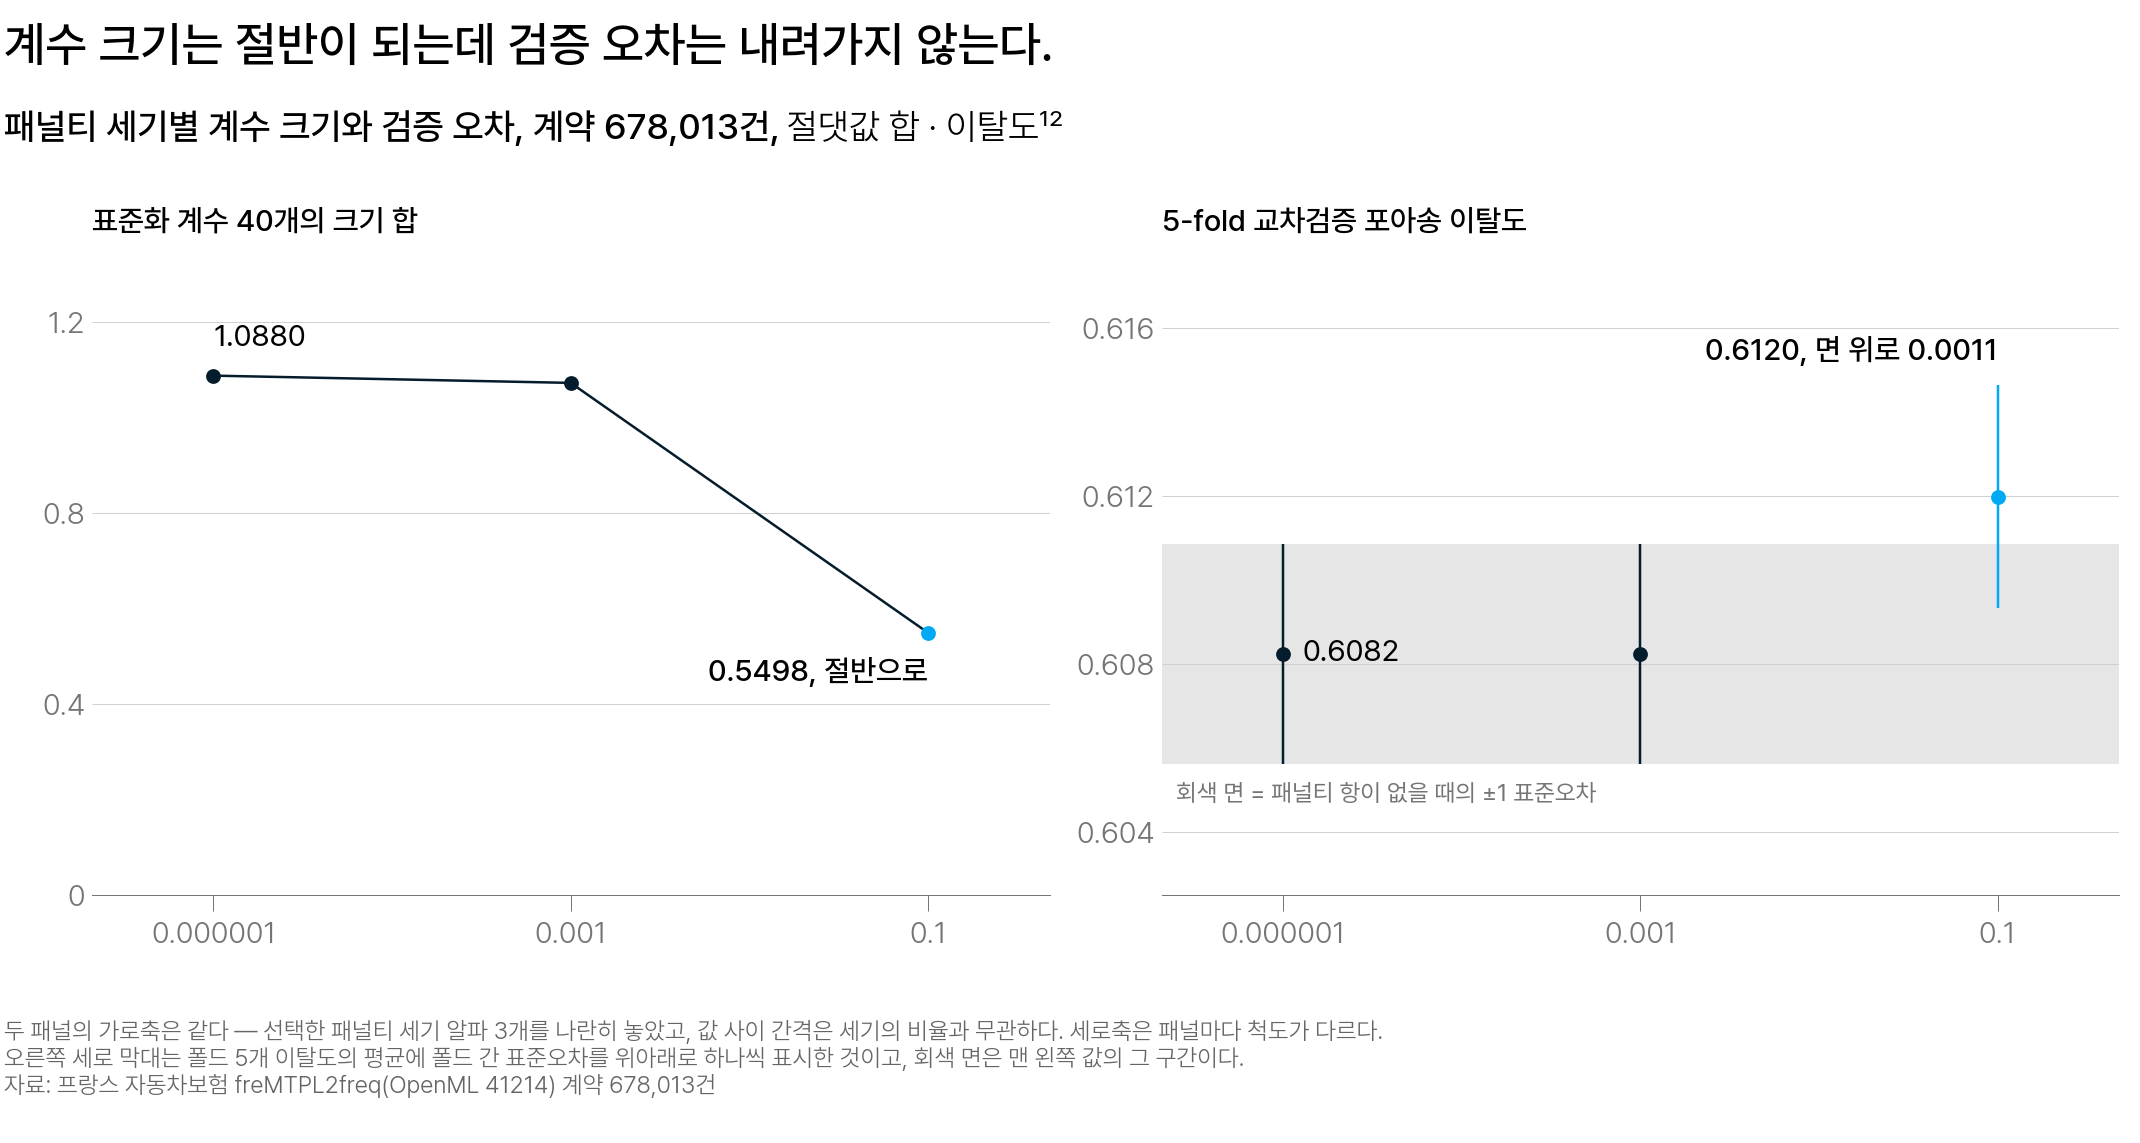

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 패널티 세기 알파를 0.000001 · 0.001 · 0.1 로 증가시킨 두 면 — <b>계수 크기 그림</b>(왼쪽) 표준화 계수 40개의 크기 합은 1.0880 에서 0.5498 로 절반이 되는데, <b>검증 오차 그림</b>(오른쪽) 5-fold 교차검증 포아송 이탈도는 0.6082 에서 0.6120 으로 되레 올라간다.</em></p>

#### 결과 해석

**예측 질문의 답은 「올라간다 — 눌러서 잃은 것이 얻은 것보다 크다」입니다 — 계수는 절반으로 눌리는데 검증 오차는 올라갑니다.** 크기 합이 1.0880 에서 0.5498 로 절반이 되는 동안 이탈도는 0.6082 에서 0.6120 으로 움직였고, 그 차이 0.0038 은 폴드 간 표준오차 0.0026 의 1.4배입니다. 계약이 678,013건인데 계수가 41개뿐이라 축소할 여지가 크지 않기 때문입니다. **그래서 우리 요율 모형에는 패널티 항을 적용하지 않기로 합니다.**

무엇을 주고 무엇을 받았는지도 같은 숫자로 확인됩니다. 지역 R21 의 계수 하나를 5개 조각으로 따로 추정하면 패널티 항이 없을 때는 0.094 에서 0.173 까지 흩어져 폴드 간 표준편차가 0.033 인데, $\alpha = 0.1$ 을 적용하면 0.073 에서 0.116 사이로 모여 0.017 이 됩니다. 중심은 +0.132 에서 +0.097 로 0 쪽으로 끌려갔고(편향), 산포는 절반이 됐습니다(분산). 편향의 제곱보다 분산이 더 많이 줄어드는 구간에서 총오차가 내려가는데, 이 모형은 그 구간에 있지 않았습니다.

다만 결과 1가지는 남습니다. Lasso 로 계수 40개 중 20개를 0 으로 지웠을 때(그중 지역 더미가 10개) 이탈도는 **0.608382** 로, 패널티 항을 사실상 제거한 0.608247 과 표준오차 범위 안에서 구분되지 않았습니다. **지역 더미 10개를 지웠는데 새 데이터 예측은 그대로**라, 요율표를 짧게 가져갈 근거가 여기서 나옵니다.

## 0.6082 의 산출 절차 — 폴드 5개의 평균

검증 오차 그림에 찍힌 0.6082 는 폴드 5개 점수의 평균입니다. 계약 678,013건을 5개 조각으로 나누고, 한 조각을 빼 둔 채 나머지 4개 조각으로 모형을 적합한 뒤, 빼 둔 조각의 이탈도 합을 그 조각의 노출 합으로 나눈 평균 이탈도를 계산합니다 — 계약 한 건이 아니라 노출 1년이 분모 단위입니다. 조각을 바꿔 5번 되풀이하면 점수 5개가 나오고, 그 평균이 0.6082 입니다. 5번을 마치면 모든 계약이 정확히 1번씩 검증에 쓰입니다.

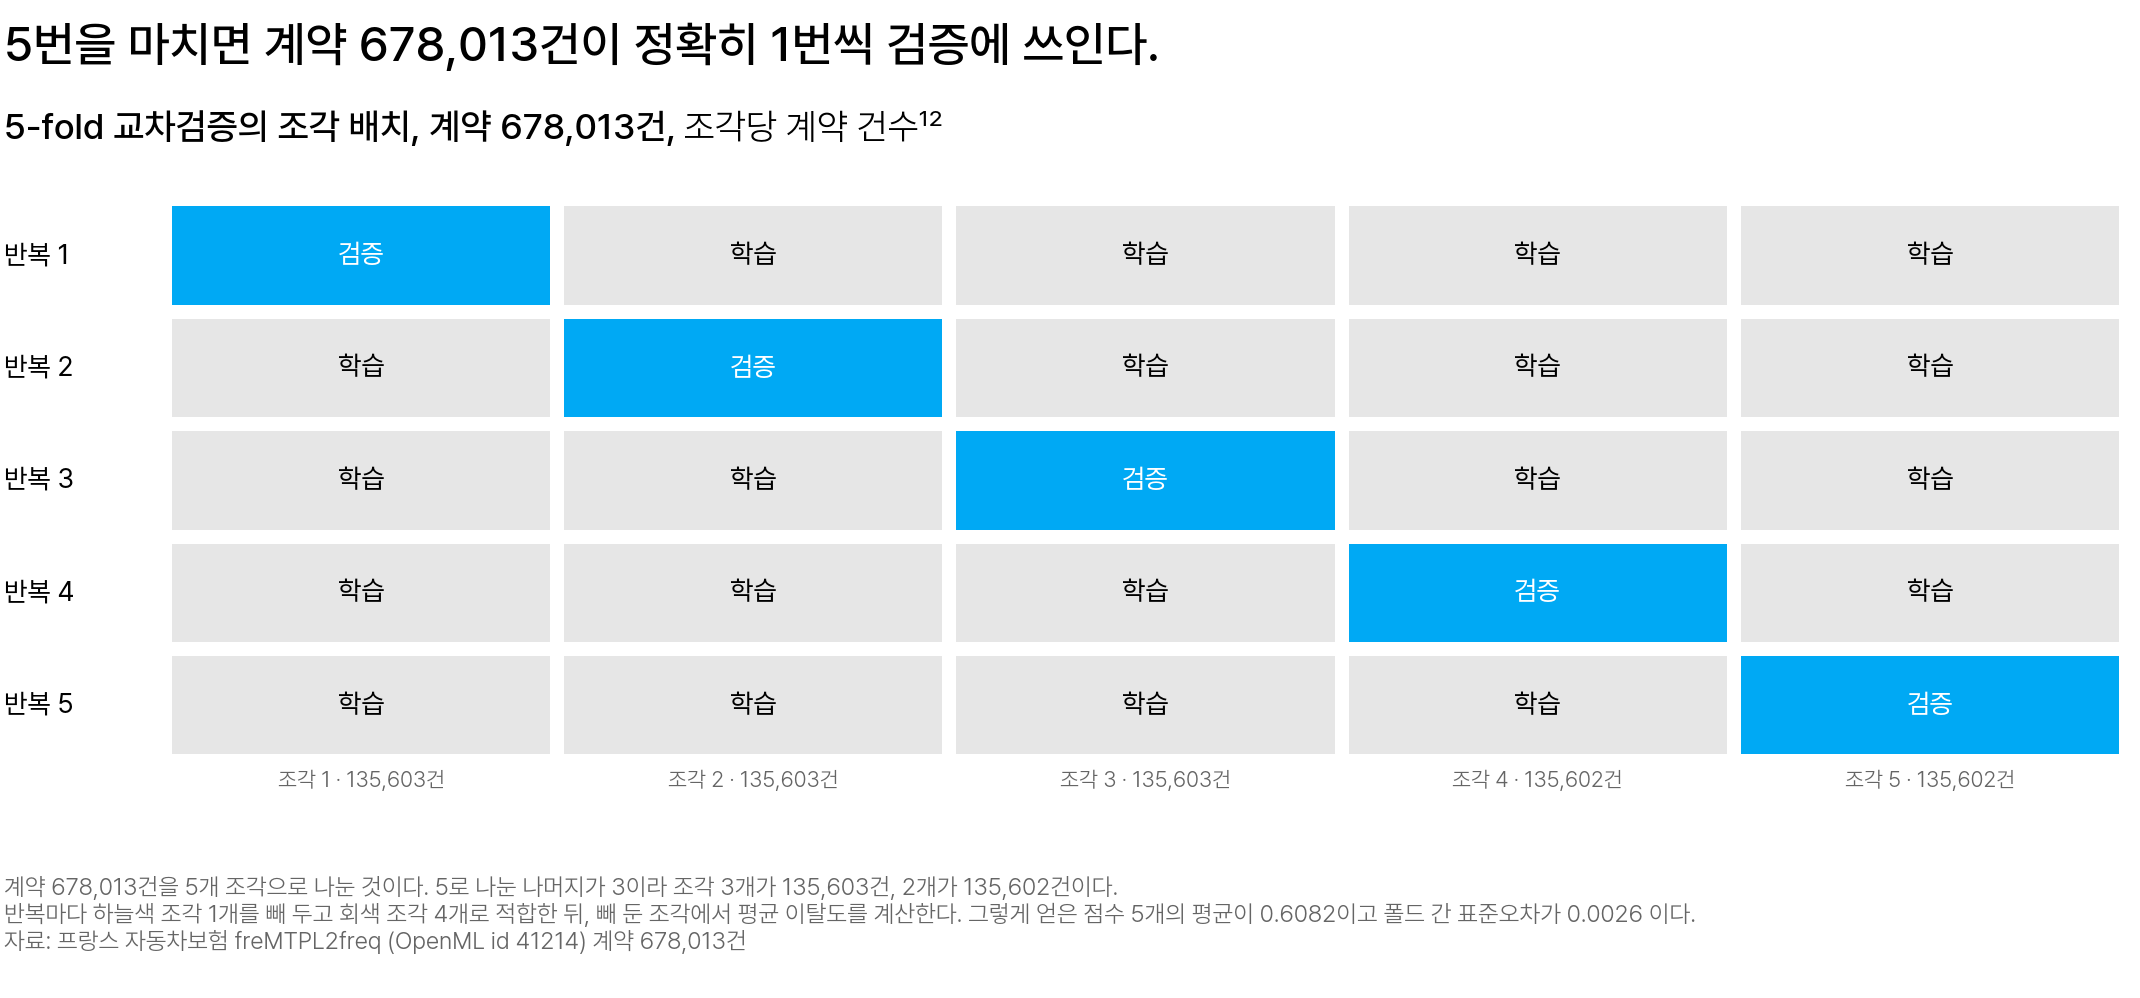

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 5-fold 교차검증의 조각 배치 — 반복마다 하늘색 검증 조각이 조각 하나만큼 오른쪽으로 옮겨 가, 5번을 마치면 계약 678,013건이 정확히 1번씩 검증에 쓰인다.</em></p>

점수를 무엇으로 재느냐는 데이터가 정합니다. 셋째 날 모형 요약표의 `deviance` 가 그 값입니다.

<details class="lms-extra"><summary>자세히 — 계약 5건에 대한 이탈도 식의 수치 대입</summary>

이탈도는 관측을 완벽히 맞히는 모형과 우리 모형의 로그우도 차이를 두 배 한 값입니다.

$$D = 2\sum_i \Big[\, y_i \log\frac{y_i}{\hat{\mu}_i} - (y_i - \hat{\mu}_i) \Big]$$

- $y_i$ : 계약 $i$ 의 실제 사고 건수
- $\hat{\mu}_i$ : 모형이 그 계약에 준 기대 사고 건수
- $\log$ : 밑이 $e$ 인 **자연로그**입니다 — 상용로그를 사용하면 아래 표의 값이 나오지 않습니다
- $y_i = 0$ 인 자리 : $y\log y \to 0$ 이라 $2\hat{\mu}_i$ 만 남습니다 — 사고가 발생하지 않은 계약도 기대 건수를 높게 추정한 만큼 이탈도 기여분이 커집니다
- $D = 0$ : 모든 관측을 정확히 맞힌 상태이고, 값이 클수록 나쁜 모형입니다

계약 5건의 실제 사고 건수가 $y = (0,\ 0,\ 1,\ 0,\ 2)$ 이고 모형이 준 기대 건수가 $\hat{\mu} = (0.08,\ 0.15,\ 0.30,\ 0.05,\ 1.10)$ 이라고 합시다.

표를 보기 전에 계약 3 을 손으로 풀어 봅니다. 대괄호 안 식의 $y_i$ 자리에 1, $\hat{\mu}_i$ 자리에 0.30 을 넣습니다.

$$
y_i \log\frac{y_i}{\hat{\mu}_i} - (y_i - \hat{\mu}_i) = 1 \cdot \log\frac{1}{0.30} - (1 - 0.30)
$$

분수를 정리하면 $1/0.30 = 3.3333$ 이고, 그 자연로그가 $\log 3.3333 = 1.204$ 입니다. 뒤 항은 $-(1 - 0.30) = -0.70$ 입니다.

$$
1.204 - 0.70 = 0.504
$$

아래 표의 계약 3 행에 적힌 +1.204 · −0.70 · 0.504 세 값이 그대로 이 계산에서 나옵니다. 같은 방식으로 5건을 모두 적으면 다음과 같습니다.

| 계약 | $y_i$ | $\hat{\mu}_i$ | $y_i\log(y_i/\hat{\mu}_i)$ | $-(y_i - \hat{\mu}_i)$ | 대괄호 안 |
|---|---|---|---|---|---|
| 1 | 0 | 0.08 | 0 | +0.08 | 0.080 |
| 2 | 0 | 0.15 | 0 | +0.15 | 0.150 |
| 3 | 1 | 0.30 | +1.204 | −0.70 | 0.504 |
| 4 | 0 | 0.05 | 0 | +0.05 | 0.050 |
| 5 | 2 | 1.10 | +1.196 | −0.90 | 0.296 |
| **합** | | | | | **1.080** |

$D = 2 \times 1.080 = 2.16$ 이고, 관측이 5건이니 평균 이탈도는 $2.16 \div 5 = 0.432$ 입니다.

사고가 나지 않은 3건은 첫 항이 0 이라 $\hat{\mu}_i$ 만 남아 0.08 · 0.15 · 0.05 의 작은 기여분에 그칩니다. 그런데 사고가 난 2건은 $0.504 + 0.296 = 0.800$ 으로 합 1.080 의 74%를 만듭니다. 사고가 발생한 관측의 기대 건수를 낮게 예측한 모형을 이탈도가 왜 걸러 내는지가 이 표에 그대로 나타납니다.

건수 데이터에 평균제곱오차를 쓰지 않는 이유도 적어 둡니다. 0이 95%인 이 데이터에 그 지표를 쓰면 모형 사이의 점수 차이가 소수점 아래로 묻힙니다. 원리는 한 문장입니다 — 평균제곱오차는 모든 관측의 분산이 같다고 보고 측정하는 지표인데, 포아송에서는 분산이 평균을 따라 커지므로 그 가정이 성립하지 않습니다.

</details>

## 폴드 간 표준오차와 짝지은 차이 — 평균 하나로 부족한 이유

$K$ 번 계산하면 점수가 $K$ 개 나오는데 평균만 적으면 **폴드마다 얼마나 달랐는지**가 사라집니다. 그래서 둘을 나란히 적습니다.

$$\bar{s} = \frac{1}{K}\sum_{k=1}^{K} s_k, \qquad \text{SE}_{\text{fold}} = \frac{\text{sd}(s_1, \dots, s_K)}{\sqrt{K}}$$

- $s_k$ : $k$ 번째 폴드의 평균 이탈도 — 폴드 하나가 점수 하나입니다
- $\bar{s}$ : 그 $K$ 개의 평균 — 보고서에 흔히 적히는 숫자입니다
- $\text{sd}(\cdot)$ : 폴드 점수들의 산포 — 앞(1. 표준오차)의 표본 표준편차 $s$ 자리입니다
- $\sqrt{K}$ : 앞(1. 표준오차)의 $s/\sqrt{n}$ 과 같은 자리

이 값은 판정 기준이 아니라 차이를 비교하는 척도입니다 — "이 정도 차이는 폴드를 다시 나누면 반대가 될 수 있다"를 보는 자리입니다.

후보가 여럿일 때 이 척도를 선으로 그어 쓰는 관례가 있습니다. **1-표준오차 선(1-SE rule)** — 평균이 가장 낮은 모형의 점수에 그 모형의 폴드 간 표준오차를 더한 값을 선으로 긋고, 그 선 안에 드는 모형은 서로 구분되지 않는 것으로 봅니다. 구분되지 않는 후보가 여럿이면 그중 가장 단순한 모형을 고릅니다.

한 걸음 더 갈 수 있습니다. 두 모형을 **같은 폴드 분할**로 평가했다면, 평균 둘 대신 폴드마다 점수 **차이** $A_k - B_k$ 를 구해 그 차이의 표준오차를 보는 쪽이 훨씬 예민합니다 — 폴드 난이도가 뺄셈에서 상쇄되기 때문입니다. 대신 **같은 분할로 계산했을 때만** 쓸 수 있습니다.

<details class="lms-extra"><summary>자세히 — 짝지어 빼면 폴드 차이가 상쇄되는 예</summary>

앞에서 Lasso 가 지운 계수 20개의 대가 0.000135 를 "구분되지 않는다"고 읽은 것이 이 척도로 계산한 판정입니다 — 표준오차 0.0026 의 20분의 1 남짓이기 때문입니다.

폴드 5개에서 모형 A 가 0.3915 · 0.4259 · 0.4327 · 0.4252 · 0.4381 을, 모형 B 가 폴드마다 0.002～0.004 씩 낮은 점수를 냈다고 합니다. 평균은 A 0.4227, B 0.4194 로 차이가 0.0032 인데 폴드 간 표준오차가 0.0081 입니다 — 평균만 보면 차이가 표준오차의 절반에도 못 미쳐 두 모형이 구분되지 않습니다.

같은 5쌍을 폴드마다 빼면 차이가 +0.0020 · +0.0029 · +0.0038 · +0.0036 · +0.0038 로 전부 같은 부호입니다. 이 5개 값의 표준오차는 0.00035 라, 차이 0.0032 가 그 9배 바깥에 위치합니다. 같은 숫자에서 결론이 달라진 이유는 한 문장입니다 — 두 점수를 변화시킨 것의 대부분이 모형 차이가 아니라 **폴드 차이**였고, 폴드마다 빼는 순간 그 공통 변동이 두 값에서 함께 빠집니다.

다만 이 9배는 원리를 강조하기 위해 크게 설정한 값입니다. 여기서는 두 모형에 똑같은 폴드 난이도를 주어 모형 쪽 변동을 0 으로 만들었기 때문입니다. 예민해지는 **방향**은 그대로여도 배수는 이보다 훨씬 작은 것이 보통입니다.

$\sqrt{K}$ 로 나누는 자리에는 앞(1. 표준오차)과 다른 점이 하나 있습니다. 앞(1. 표준오차)의 관측 $n$ 개는 서로 독립이었습니다. 폴드 점수 $K$ 개는 **학습 데이터의 대부분을 서로 공유**합니다 — 5-fold 라면 어느 두 폴드의 학습 집합이든 전체 자료의 60%를 함께 씁니다. 겹친 만큼 점수가 함께 움직여 산포가 작게 잡히므로, $\text{SE}_{\text{fold}}$ 는 실제보다 작게 추정되는 경향이 있습니다. 차이가 이 척도 안에 들어올 때 "구분 안 된다"고 말하는 쪽은 그래도 안전합니다 — 낙관적인 척도로도 구분하지 못했다는 뜻이기 때문입니다.

점수가 조용히 부풀려지는 통로도 하나 적어 둡니다. **데이터 누수** — 검증 폴드의 정보가 학습 쪽으로 새어 드는 것이고, 가장 흔한 통로가 전처리입니다. 세그먼트별 사고율을 피처로 만들 때 그 표를 전체 데이터로 먼저 만들고 폴드를 나누면 검증 계약의 답이 피처 안에 들어갑니다. 규칙은 한 문장 — **타깃을 쓰는 전처리는 폴드 안으로.**

</details>

## AIC 와 교차검증의 결과가 다를 때

셋째 날 AIC 는 계약 678,013건에서 확장 모형을 골랐고, 확장과 핵심의 차이 877점은 셋째 날에 후보 제외의 기준으로 삼은 ΔAIC 10 의 87배입니다. 그런데 오늘의 지표로 다시 물을 것이 있습니다 — AIC 가 더 작았다는 것이 새 데이터의 예측오차도 더 작다는 뜻인지 확인합니다.

AIC 는 데이터를 **1번만** 쓰고 공식으로 추정하고, 교차검증은 **$K$ 번 나눠** 반복해 계산합니다. 잘 지정된 모형이면 둘이 거의 같은 답을 줍니다. 그래서 두 지표의 결과가 다르면 그 자체가 신호입니다. 검토할 항목은 3가지입니다.

1. **모형이 잘못 지정됐을 때** — 과산포가 있으면 AIC 가 복잡한 모형을 선택하는 쪽으로 치우칩니다. 앞 절의 $\hat{\varphi} \approx 1.06$ 이라 이 가능성은 낮습니다.
2. **관측이 서로 얽혀 있을 때** — 묶인 데이터라면 무작위로 나눈 폴드가 낙관적으로 나옵니다. 앞 절에서 지역 22개 군집 중 17개가 무작위 범위 바깥이었으니 **우리 데이터에서 실제로 해당하는 것**이 이쪽입니다.
3. **평가 지표가 다를 때** — AIC 는 로그우도에 패널티 항을 더한 지표이고, 교차검증은 평균 이탈도로 측정합니다.

다만 셋을 검토하기 **전에** 확인할 것이 있습니다. 평균 차이가 $\text{SE}_{\text{fold}}$ 안에 들어오면 교차검증은 AIC 와 다른 답을 준 것이 아니라 **아무 답도 주지 않은 것**입니다.

<details class="lms-extra"><summary>더 깊이 — AIC 와 등가인 교차검증: LOO 와 5-fold 의 구분</summary>

둘이 점근적으로 같은 답을 준다는 말은 엄밀히는 **LOO 교차검증**과 AIC 사이의 결과입니다. LOO 는 leave-one-out, 곧 $K$ 를 관측 수 $n$ 까지 키워 1번에 1건씩만 검증에 쓰는 방식입니다. 우리가 쓰는 $K = 5$ 나 10 은 그 근사라, 폴드를 적게 나눌수록 학습에 쓰는 데이터가 줄어 교차검증 쪽이 조금 비관적으로 나옵니다. 그러므로 5-fold 점수와 AIC 가 **조금** 다른 것은 늘 있는 일이고, 위 3가지를 검토할 만한 차이는 그 정도를 넘어설 때입니다.

셋째 날의 확장 모형이 해당할 가능성이 큰 것은 2번입니다. 계수가 41개라 폴드마다 적합이 변동할 여지가 크고, 지역처럼 묶이는 단위의 계약이 여러 폴드에 나뉘어 들어가기 때문입니다. 그래서 실습에서는 5-fold 로 이 순위를 다시 재되, 평균 하나가 아니라 폴드 5개의 점수를 그대로 적어 둡니다.

</details>

이로써 모형 비교 방법이 AIC · 교차검증 · 부트스트랩 3가지로 갖추어졌습니다.

#### 핵심 주의점

교차검증 평균 점수의 차이 하나를 모형의 우열로 해석하면 안 됩니다.

$$
\text{SE}_{\text{fold}} = \frac{\text{sd}(s_1, \dots, s_K)}{\sqrt{K}}
$$

- $s_k$ : $k$ 번째 폴드의 평균 이탈도, $K$ 는 폴드 수입니다

평균 차이가 이 척도 안에 들어오면 폴드를 다시 나눌 때 부호가 반대가 될 수 있습니다. 따라서 "Lasso 쪽이 0.000135 만큼 나쁘다" 는 틀린 문장입니다.

정확한 뜻은 다음과 같습니다.

> **계수 20개를 지운 모형과 패널티 항을 사실상 제거한 모형의 평균 이탈도 차이 0.000135 는 폴드 간 표준오차 0.0026 의 20분의 1이라, 이 데이터로는 두 모형이 구분되지 않는다.**

> 패널티 항은 계수를 축소해 추정을 안정시키고 교차검증은 그 강도를 선택하지만, 둘 다 **평균 하나가 아니라 폴드마다의 점수를 함께 봐야** 판정이 성립합니다.

> **[문제] 폴드별 점수를 이용한 두 모형의 구분**
>
> 같은 폴드 분할로 두 모형에 5-fold 교차검증을 적용해 폴드별 평균 이탈도를 얻었습니다. 모형 A는 0.401, 0.428, 0.395, 0.436, 0.400 이고 모형 B는 0.399, 0.424, 0.393, 0.432, 0.397 입니다. (1) 두 모형의 평균과 폴드 간 표준오차 $\text{sd}/\sqrt{5}$ 를 각각 구합니다. (2) 두 모형이 나란히 가장 높았던 폴드와 나란히 가장 낮았던 폴드를 하나씩 고른 뒤, 그 두 폴드가 A 열의 평균에서 각각 얼마나 떨어져 있는지와 차이 열 $A_k - B_k$ 의 평균에서 각각 얼마나 떨어져 있는지를 적어 두 거리를 비교합니다. (3) 두 모형을 서로 다른 5-fold 분할로 쟀다면 (2)의 계산 중 무엇을 할 수 없게 되는지 한 문장으로 적습니다.

## 7. 오늘의 정리와 수업에서 다룰 질문

## 오늘 정리 — 핵심 항목 6개

앞 절에서 셋째 날 AIC 가 선택한 모형을 교차검증으로 다시 평가했습니다. 오늘 만든 표준오차와 구간과 판정을 6개 항목으로 압축합니다.

1. **표준오차**는 추정값이 표본마다 얼마나 달라지는지를 측정하는 지표입니다. 같은 공식을 써도 세그먼트마다 답이 달라, 전체 678,013건에서는 0.00053(추정값 0.1006 의 0.5%)인데 계약 12건짜리 R21 × B11 에서는 0.2136(추정값 0.3021 의 70%)이었습니다. 그 세그먼트에서는 $\pm 2\,\text{SE}$ 의 아래끝이 $-0.125$ 라 그 방식 자체를 쓸 수 없었습니다.
2. **부트스트랩**은 표본 하나를 복원추출로 다시 뽑아 그 변동성을 재현합니다. 지급액 30건에서 재표본 4,000벌로 계산한 표준오차가 548.56유로, 공식 $s/\sqrt{30}$ 은 553.36유로였습니다. 다만 새 정보를 만들지는 못하므로 표본이 모집단을 대표하지 못하면 함께 틀립니다.
3. **신뢰구간의 95%는 절차의 적중률**입니다. 참값을 아는 모의실험에서 4,000번 집계해 보니 95% 구간의 실제 포획률이 95.35% 였습니다. 구간 하나에 확률을 직접 부여하려면 사후분포에서 잘라 낸 **신용구간**이 필요합니다.
4. 확률 하나로는 결정이 안 됩니다. **기대손실**은 확률에 차이의 크기까지 곱해 값을 계산하고(B 쪽 0.000057 은 A 쪽의 268분의 1), **ROPE** 는 실무가 정한 기준선으로 기각·수용·보류를 구분합니다. 두 지역 차이는 +0.0007 ～ +0.0296 이 ROPE ±0.005 를 걸쳐 **보류**, 출력 등급 두 세그먼트의 −0.0045 ～ −0.0024 는 ROPE 구간 안에 들어 **수용**이었습니다. 계획 없는 **엿보기**는 중간 확인을 20번으로 나누면 오경보율을 5%에서 25%로 키웁니다.
5. **구간은 잔차 가정에 의존합니다.** 정규성은 Q-Q 그림, 등분산성은 예측값 순 15개 구간의 분산 ÷ 평균, 독립성은 군집별 잔차로 확인합니다. 등분산성만 잔차-적합값 그림을 쓰지 않았습니다 — 사고 0건이 95%인 이 데이터에서는 그 그림이 곡선 몇 개로 갈라져 읽히지 않기 때문입니다. 과산포는 $\hat{\varphi} = 1.06$ 이라 표준오차를 $\sqrt{1.06} = 1.03$ 배로 읽으면 끝나는 크기였지만, 지역으로 뭉친 잔차는 같은 표준오차를 5～6배까지 확대시켰습니다. 구간 길이를 가장 크게 바꾼 것은 산포가 아니라 독립성 가정입니다.
6. **패널티 항은 계수를 축소해 추정을 안정시키고, 교차검증은 그 강도를 선택합니다.** 계수 41개짜리 요율 모형에서는 패널티 항을 1,000배·100배로 차례로 키워 계수 크기를 절반으로 축소해 봤습니다. 5-fold 이탈도가 0.6082 에서 0.6120 으로 오히려 증가해, 패널티 항을 적용할 이유가 나오지 않았습니다. 다만 Lasso 로 지역 더미 10개를 지워도 이탈도가 폴드 간 표준오차 0.0026 안에서 구분되지 않아, 요율표를 짧게 가져갈 근거는 남습니다. **평균 하나가 아니라 폴드마다의 점수를 함께 봐야** 이런 판정이 성립합니다.

<details class="lms-extra"><summary>자세히 — 대비 개념 4쌍의 정리표</summary>

| 쌍 | 구분되는 지점 | 오늘 숫자 |
|---|---|---|
| 표준편차 / 표준오차 | 관측 하나의 산포인가, 추정값의 산포인가 | 계약을 더 모아도 앞은 그대로, 뒤는 4배를 모아야 절반이 된다 — $\text{SE}(\hat{\lambda}) = \sqrt{36{,}056} \div 358{,}360 = 0.00053$ |
| 신뢰구간 / 신용구간 | 확률이 절차에 부여되는가, 모수에 부여되는가 | 두 지역 차이에 부여한 같은 95% 구간이 +0.0005 ～ +0.0306 / +0.0007 ～ +0.0296 |
| 기각 / 수용 / 보류 | 신용구간이 ROPE 밖인가, 안인가, 경계를 가로지르는가 | 두 지역 +0.0007 ～ +0.0296 은 걸쳐서 보류 / 출력 등급 −0.0045 ～ −0.0024 는 안에 들어 수용 |
| 과산포 / 군집 뭉침 | 산포의 문제인가, 유효 표본 수의 문제인가 | $\sqrt{1.06} = 1.03$ 배 곱해 읽으면 끝 / 계수마다 배수가 5～6배로 달라 하나의 배수로 보정할 수 없다 |

</details>

앞쪽 4개 절이 이어지는 순서도 함께 정리합니다. 앞(4. 신뢰구간을 이용한 의사결정)의 두 지역 차이를 예로 들어, 점추정 하나가 어떤 단계를 거쳐 판정으로 닫히는지를 5단계로 전개해 두었습니다.

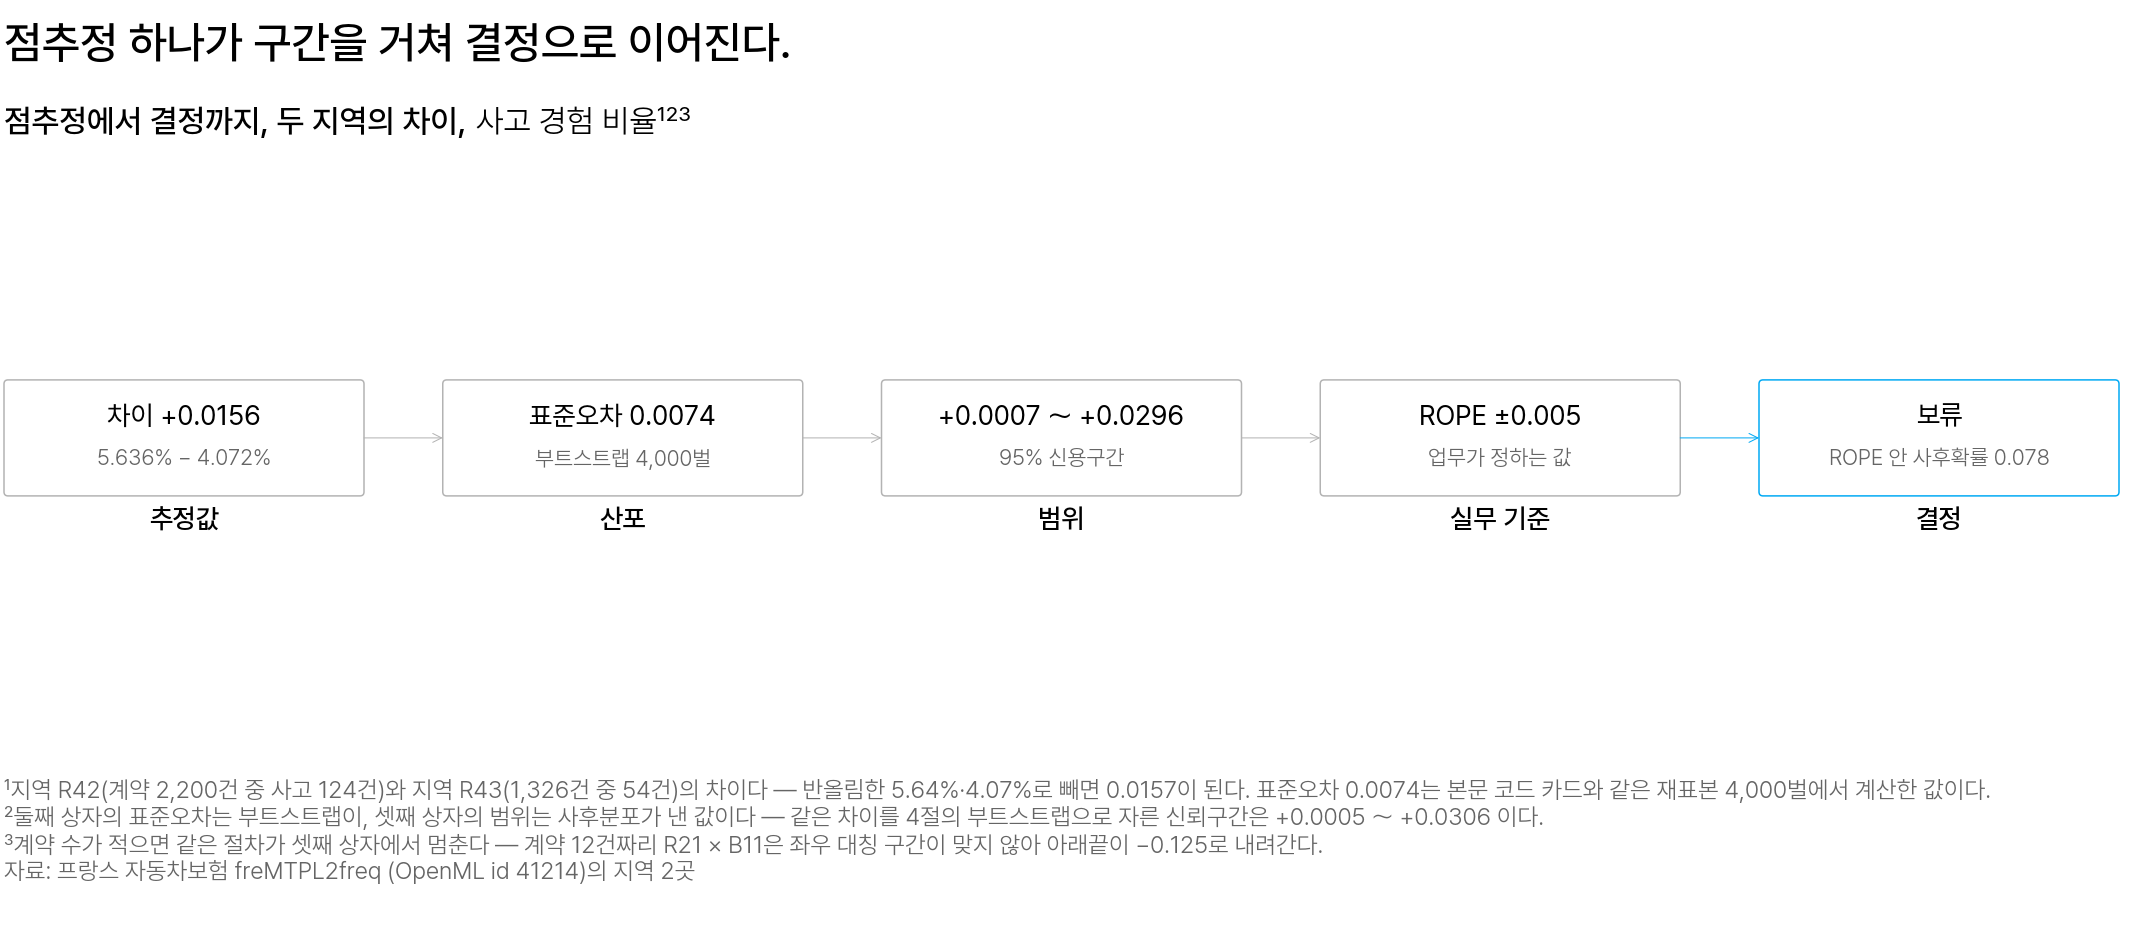

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 점추정 하나가 결정으로 이어지기까지의 5단계 — 추정값·변동성·범위·실무 기준을 차례로 지나 하늘색 마지막 상자에서 판정이 보류로 결정된다.</em></p>

그림은 규칙 3개로 읽습니다.

- **상자 윗줄** — 그 단계에서 얻는 숫자
- **상자 아랫줄** — 그 숫자가 어디서 왔는지
- **상자 아래 라벨** — 그 단계의 측정 대상

사용한 값은 앞(4. 신뢰구간을 이용한 의사결정)의 두 지역 차이라 사고 경험 비율 5.636%와 4.072%의 차이 **+0.0156** 에서 출발해, 표준오차 0.0074 와 95% 신용구간 +0.0007 ～ +0.0296 을 지나 ROPE ±0.005 와 맞댑니다.

**셋째 상자까지가 데이터가 주는 값**이고, 넷째는 데이터 밖에서 받아 오는 값입니다. ROPE 를 받아 오지 못하면 마지막 상자는 비고, 보고서는 신용구간에서 멈춥니다 — 앞(4. 신뢰구간을 이용한 의사결정)이 "방향은 정해졌는데 크기가 미정"이라 부른 그 상태입니다.

둘째 상자의 표준오차 0.0074 는 부트스트랩이, 셋째 상자의 범위는 사후분포가 낸 값이라 두 상자는 서로 다른 경로에서 나왔습니다. 같은 차이를 부트스트랩으로 잘라도 신뢰구간이 +0.0005 ～ +0.0306 으로 나와 구간 길이 0.0301 이 신용구간의 0.0289 와 거의 같지만, 해석 문장은 4. 신뢰구간을 이용한 의사결정에서 구분한 대로 다릅니다.

세그먼트의 계약 수가 적으면 이 절차는 셋째 단계에서 중단됩니다. 계약 12건짜리 R21 × B11 은 같은 방식으로 범위를 만들면 $-0.125$ ～ $+0.729$ 라 아래쪽 끝이 음수로 내려가, 넷째 상자를 배치할 단계가 아니었습니다.

R21 × B11 에서 시작한 질문은 **"공식이 음수인 하한을 산출하는 경우에 불확실성을 어떻게 다시 측정하고, 그렇게 측정한 구간을 얼마나 신뢰할 것인가"** 였습니다. 회의실 말로 옮기면 **"이 숫자가 다음 해에도 그대로 나옵니까?"** 이고, 답은 문장 2개였습니다.

하나는 "그대로 나오지는 않지만 이만큼 범위 안에서 움직인다"는 구간입니다. 대칭으로 벌리는 방식이 맞지 않으면 부트스트랩과 정확 포아송 구간으로 다시 만든 구간이 그 자리에 들어갑니다. 다른 하나는 "그 범위가 실무 기준선을 넘는가"라는 판정입니다.

## 수업에서 다룰 질문

읽기는 여기까지입니다. 이어지는 실습에서는 이 데이터로 직접 부트스트랩 구간을 만들고, 요율표 1장을 정리해 어느 세그먼트를 자동 승인하고 어느 세그먼트를 사람 심사로 보낼지까지 직접 정합니다. 이 과정 마지막 날에는 계약 수가 적은 세그먼트의 구간을 계약을 더 모으지 않고 좁히는 방법 — 옆 세그먼트의 정보를 함께 쓰는 계층 모형과 그 계산을 가능하게 하는 MCMC 로 넘어갑니다.

부트스트랩은 Efron & Hastie 『Computer Age Statistical Inference』 10～11장이 원저자의 손으로 쓴 가장 짧은 안내입니다. 구간을 결정으로 옮기는 쪽 — 신용구간·ROPE·정지 규칙 — 은 Kruschke 『Doing Bayesian Data Analysis』 12장에 함께 정리되어 있습니다.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:18px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 10px 0">오늘의 한 문장</h2>
<div style="font-size:1.05em">"점추정은 답이고 구간은 그 답을 얼마나 믿을지에 대한 답입니다 — 보고서에 들어가야 하는 것은 둘 다입니다."</div>
</div>

마지막으로 판단이 나뉘는 문제를 하나 제시합니다. 이 질문은 수업에서 팀 단위로 마무리하니, 지금 답이 나오지 않아도 미완결이 아닙니다. 각자 답과 확신도(1～5)를 적어 잠근 뒤 팀의 답 분포가 공개되고, 근거를 교환해 토론한 다음 팀이 답 하나로 모여 제출합니다.

> **[문제] 팀 라운드 — 보류 판정 하나를 들고 요율 개정 회의에 간다**
>
> 다음 주 요율 개정 회의에 표 1장을 들고 가야 합니다. 손에 있는 것은 오늘 만든 2가지입니다. ⑴ 지역 R43 과 R42 의 사고 경험 비율 차이는 95% 신용구간 +0.0007 ～ +0.0296 이고, 요율 담당자가 준 실질 동등 구간 ±0.005 를 왼쪽 끝이 걸쳐 판정이 **보류** 입니다. ⑵ 그런데 5. 잔차 진단에서 같은 데이터의 이탈도 잔차를 지역 22개 군집으로 묶었더니 17개가 무작위 범위 바깥이었고, 군집 표준오차로 다시 계산하면 계수에 따라 포아송 가정으로 계산한 표준오차의 5～6배가 나왔습니다. 구간이 그만큼 넓어지면 지금 구간의 왼쪽 끝 +0.0007 은 0 아래로 내려가 방향조차 미정이 됩니다. 팀 안에서 의견이 3가지로 나뉘었습니다.
> 
> - **관점 A — 지금 구간 그대로 보류를 보고한다.** 군집 표준오차는 군집이 40～50개는 돼야 안정되는데 우리 군집은 22개뿐이라 5～6배라는 배수 자체가 어림이다. 어림값으로 구간을 5배 확대해 "방향도 모른다"고 적는 것은 보고를 정확하게 만드는 게 아니라 쓸 수 없게 만드는 것이다. 판정이 보류라는 사실만으로 이번 분기에 요율표를 고치지 않을 근거는 충분하다.
> - **관점 B — 군집 표준오차로 다시 계산해 넓힌 구간을 보고한다.** 뭉침은 산포가 아니라 유효 표본 수의 문제라 배수 보정으로 제거할 수 없고, 걷어 내지 않은 표준오차는 실제보다 좁다. 좁은 구간을 그대로 보고하면 다음 분기에 누군가 그 왼쪽 끝 +0.0007 을 근거로 요율을 건드린다. 넓혀서 "방향도 아직 못 정했다"고 적는 편이 정직하다.
> - **관점 C — 지역 2곳을 비교하는 표 자체를 보류하고, 세그먼트를 합쳐 구간부터 줄인다.** 출력 등급 사례에서 판정을 낸 것은 판정 방법이 아니라 구간 길이였다(계약 678,013건, 길이 0.0021). 계약 3,526건짜리 비교는 어느 방식으로 계산해도 결론이 안 나는 크기이고, 뭉침 진단도 계약이 적은 세그먼트에서 특히 크게 변동한다. 지역을 몇 개씩 묶은 상위 구분으로 다시 계산해 구간이 ±0.005 안팎으로 좁아지는 자리를 찾는 것이 회의에 쓸모 있는 표다.
> 
> 자기 입장 하나와 근거 3가지, 그리고 확신도를 정합니다.